# Chat
> A high-level chat API for fastllm, similar to Lisette

In [1]:
#| default_exp chat

In [2]:
#| hide
from cachy import enable_cachy,disable_cachy,doms,norm_pats
from fastllm.types import sample_doms
from aidialog.msg_parts import hist2fmt, parse_tools, FullResponse, MediaUrl, ToolResult, InputImage, mk_tr_details
from fastllm.acomplete import defaults

In [3]:
#| hide
norm_pats.append((r'"prompt_cache_key"\s*:\s*"[^"]*"', '"prompt_cache_key":"notebook"'))
enable_cachy(doms=doms+sample_doms, hdrs=('content-type',))
defaults.reasoning_effort = 'l'


In [4]:
#| export
import secrets
from typing import Optional,Callable
from fastcore.funccall import mk_ns, call_func, call_func_async, get_schema
from fastcore.utils import *
from fastcore.meta import delegates

from fastllm.types import *
from aidialog.msg_parts import (Msg, Part, PartType, Text, Thinking, ToolUse, tool_text, mk_tool_res_msg, tool_info, usage_info,
    StopResponse, ToolResponse, display_list, fmt2hist, hist2fmt, mk_result_fence, split_fence_msgs, extract_fence_call,
    trunc_str, Completion, mk_msg, mk_msgs, part_txt)
from fastllm.acomplete import *
from fastllm.streaming import FenceToolStop, stop_sequences

In [5]:
#| hide
import asyncio, random
from fastcore.xml import Safe
from fastcore.test import *
from fastllm.acomplete import api_registry, Usage
from IPython.display import Markdown, Image, Audio, Video
import httpx2

Here are the API adapters registered in this environment:

In [6]:
list(api_registry)

['openai', 'openai_chat', 'anthropic', 'gemini']

## fastllm

Switching LLM providers should take one argument. `acomplete` handles the request; this module adds message helpers, chat history, and tool loops so you don't have to manage them yourself.

If you've used our provider-specific wrappers—[claudette](https://claudette.answer.ai/) for Anthropic, [gaspard](https://github.com/AnswerDotAI/gaspard) for Gemini, or [cosette](https://answerdotai.github.io/cosette/) for OpenAI—this should feel familiar.

In [7]:
ms = [flash, sonn, luna]
msgs = [Msg(role='user', content=[Text('Hi there!', cache_control={"type": "ephemeral"})])]
for m in ms:
    display(Markdown(f'**{m}:**'))
    display(await acomplete(msgs, m))

**models/gemini-3.8-flash:**

Hello! How can I help you today?

::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=4, completion_tokens=9, total_tokens=13, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'promptTokenCount': 4, 'candidatesTokenCount': 9, 'totalTokenCount': 13, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 4}], 'serviceTier': 'standard'})`

:::

**claude-sonnet-5-5:**

Hi there! How can I help you today?

::: details

- model: `claude-sonnet-5-5`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=13, completion_tokens=14, total_tokens=27, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'input_tokens': 13, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'cache_creation': {'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 14, 'output_tokens_details': {'thinking_tokens': 0}, 'service_tier': 'standard', 'inference_geo': 'global'})`

:::

**gpt-6-luna:**

Hi! How can I help you today?

::: details

- model: `gpt-6-luna`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=9, completion_tokens=13, total_tokens=22, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'input_tokens': 9, 'input_tokens_details': {'cache_write_tokens': 0, 'cached_tokens': 0}, 'output_tokens': 13, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': 22})`

:::

In [8]:
await acomplete(msgs, fable)

Hi! How can I help you today?

::: details

- model: `claude-fable-5-1`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=13, completion_tokens=13, total_tokens=26, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'input_tokens': 13, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'cache_creation': {'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 13, 'output_tokens_details': {'thinking_tokens': 0}, 'service_tier': 'standard', 'inference_geo': 'global'})`

:::

In [9]:
await acomplete(msgs, luna)

Hi! How can I help you today?

::: details

- model: `gpt-6-luna`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=9, completion_tokens=13, total_tokens=22, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'input_tokens': 9, 'input_tokens_details': {'cache_write_tokens': 0, 'cached_tokens': 0}, 'output_tokens': 13, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': 22})`

:::

In [10]:
await acomplete(msgs, luna)

Hi! How can I help you today?

::: details

- model: `gpt-6-luna`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=9, completion_tokens=13, total_tokens=22, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'input_tokens': 9, 'input_tokens_details': {'cache_write_tokens': 0, 'cached_tokens': 0}, 'output_tokens': 13, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': 22})`

:::

Use `get_model_info` to inspect a model's metadata. It includes local overrides for details missing from the upstream registry. See `register_model_info` in the Types notebook to add your own overrides:

In [11]:
kimi = 'accounts/fireworks/models/kimi-k3'
get_model_info(kimi, 'fireworks_ai')

```python
{ 'cache_read_input_token_cost': 3e-07,
  'cache_read_input_token_cost_priority': 3.75e-07,
  'input_cost_per_token': 3e-06,
  'input_cost_per_token_priority': 3.75e-06,
  'litellm_provider': 'fireworks_ai',
  'max_input_tokens': 1048576,
  'max_output_tokens': 131072,
  'max_tokens': 131072,
  'mode': 'chat',
  'output_cost_per_token': 1.5e-05,
  'output_cost_per_token_priority': 1.875e-05,
  'reasoning_effort_levels': ['low', 'high', 'max'],
  'source': 'https://api.fireworks.ai/v1/serverless/models',
  'supports_function_calling': True,
  'supports_reasoning': True,
  'supports_response_schema': True,
  'supports_tool_choice': True,
  'supports_vision': True}
```

In [12]:
get_model_info(luna, 'openai')

```python
{ 'cache_creation_input_token_cost': 1.25e-07,
  'cache_creation_input_token_cost_above_272k_tokens': 2.5e-07,
  'cache_creation_input_token_cost_above_272k_tokens_batches': 1.25e-07,
  'cache_creation_input_token_cost_above_272k_tokens_flex': 1.25e-07,
  'cache_creation_input_token_cost_above_272k_tokens_priority': 5e-07,
  'cache_creation_input_token_cost_batches': 6.25e-08,
  'cache_creation_input_token_cost_flex': 6.25e-08,
  'cache_creation_input_token_cost_priority': 2.5e-07,
  'cache_read_input_token_cost': 1e-08,
  'cache_read_input_token_cost_above_272k_tokens': 2e-08,
  'cache_read_input_token_cost_above_272k_tokens_batches': 1e-08,
  'cache_read_input_token_cost_above_272k_tokens_flex': 1e-08,
  'cache_read_input_token_cost_above_272k_tokens_priority': 4e-08,
  'cache_read_input_token_cost_batches': 5e-09,
  'cache_read_input_token_cost_flex': 5e-09,
  'cache_read_input_token_cost_priority': 2e-08,
  'input_cost_per_token': 1e-07,
  'input_cost_per_token_above_272k_tokens': 2e-07,
  'input_cost_per_token_above_272k_tokens_batches': 1e-07,
  'input_cost_per_token_above_272k_tokens_flex': 1e-07,
  'input_cost_per_token_above_272k_tokens_priority': 4e-07,
  'input_cost_per_token_batches': 5e-08,
  'input_cost_per_token_flex': 5e-08,
  'input_cost_per_token_priority': 2e-07,
  'litellm_provider': 'openai',
  'max_input_tokens': 922000,
  'max_output_tokens': 128000,
  'max_tokens': 128000,
  'mode': 'chat',
  'output_cost_per_token': 5e-07,
  'output_cost_per_token_above_272k_tokens': 7.5e-07,
  'output_cost_per_token_above_272k_tokens_batches': 3.75e-07,
  'output_cost_per_token_above_272k_tokens_flex': 3.75e-07,
  'output_cost_per_token_above_272k_tokens_priority': 1.5e-06,
  'output_cost_per_token_batches': 2.5e-07,
  'output_cost_per_token_flex': 2.5e-07,
  'output_cost_per_token_priority': 1e-06,
  'regional_processing_uplift_multiplier_eu': 1.1,
  'regional_processing_uplift_multiplier_us': 1.1,
  'search_context_cost_per_query': { 'search_context_size_high': 0.01,
                                     'search_context_size_low': 0.01,
                                     'search_context_size_medium': 0.01},
  'source': 'https://developers.openai.com/api/docs/pricing',
  'supported_endpoints': ['/v1/chat/completions', '/v1/batch', '/v1/responses'],
  'supported_modalities': ['text', 'image'],
  'supported_output_modalities': ['text'],
  'supports_computer_use': True,
  'supports_function_calling': True,
  'supports_max_reasoning_effort': True,
  'supports_minimal_reasoning_effort': False,
  'supports_native_streaming': True,
  'supports_none_reasoning_effort': True,
  'supports_parallel_function_calling': True,
  'supports_pdf_input': True,
  'supports_prompt_cache_breakpoint': True,
  'supports_prompt_caching': True,
  'supports_reasoning': True,
  'supports_response_schema': True,
  'supports_system_messages': True,
  'supports_tool_choice': True,
  'supports_vision': True,
  'supports_web_search': True,
  'supports_xhigh_reasoning_effort': True}
```

In [13]:
get_model_info(luna, 'codex')

```python
{ 'cache_creation_input_token_cost': 1.0000000000000001e-07,
  'cache_read_input_token_cost': 1.0000000000000001e-07,
  'input_cost_per_token': 1.0000000000000001e-07,
  'litellm_provider': 'openai',
  'max_input_tokens': 371000,
  'max_output_tokens': 128000,
  'max_tokens': 128000,
  'mode': 'chat',
  'output_cost_per_token': 5e-07,
  'regional_processing_uplift_multiplier_eu': 1.1,
  'regional_processing_uplift_multiplier_us': 1.1,
  'search_context_cost_per_query': { 'search_context_size_high': 0.01,
                                     'search_context_size_low': 0.01,
                                     'search_context_size_medium': 0.01},
  'source': 'https://developers.openai.com/api/docs/pricing',
  'supported_endpoints': ['/v1/chat/completions', '/v1/batch', '/v1/responses'],
  'supported_modalities': ['text', 'image'],
  'supported_output_modalities': ['text'],
  'supports_computer_use': True,
  'supports_function_calling': True,
  'supports_max_reasoning_effort': True,
  'supports_minimal_reasoning_effort': False,
  'supports_native_streaming': True,
  'supports_none_reasoning_effort': True,
  'supports_parallel_function_calling': True,
  'supports_pdf_input': True,
  'supports_prompt_cache_breakpoint': True,
  'supports_prompt_caching': True,
  'supports_reasoning': True,
  'supports_response_schema': True,
  'supports_system_messages': True,
  'supports_tool_choice': True,
  'supports_vision': True,
  'supports_web_search': True,
  'supports_xhigh_reasoning_effort': True}
```

### Messages formatting

Let's start with messages. The same helpers accept text and media, so you don't need to build provider-specific dictionaries.

In [14]:
#| export
def contents(c):
    "Get Msg object from Completion."
    if not c.message: return ''
    return c.message

def stop_reason(c):
    if not c.finish_reason: return 'unk'
    return c.finish_reason

An assistant message can contain text and tool calls together:

In [15]:
parts = [Text("I'll calculate both additions for you using the simple_add tool in parallel."),
    ToolUse(id='toolu_01LyH4DdFWEbU9G7cg2XarVf', name='simple_add', arguments={'a': 3, 'b': 5}, raw={'caller': {'type': 'direct'}}),
    ToolUse(id='toolu_01JrpzizGDyz3BP2Ec2j1Ye1', name='simple_add', arguments={'a': 10, 'b': 20}, raw={'caller': {'type': 'direct'}})]
msg_tool = Msg(role='assistant', content=parts)

Use `mk_msg` from `aidialog.msg_parts` to turn text or message parts into a `Msg`. For plain text:


In [16]:
msg = mk_msg("hey")
msg

**Msg**

- role: `user`

<contents>

**Text** (`text`)

hey

::: details

- raw: `None`
- citations: `None`

:::

</contents>

Pass a list of messages to `acomplete`:

In [17]:
model = flash

In [18]:
res = await acomplete([msg], model)
res

Hey there! How can I help you today?

::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=2, completion_tokens=10, total_tokens=12, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'promptTokenCount': 2, 'candidatesTokenCount': 10, 'totalTokenCount': 12, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 2}], 'serviceTier': 'standard'})`

:::

We'll use this little shortcut for the examples:

In [19]:
async def c(msgs, m=model, **kw):
    msgs = [msgs] if isinstance(msgs,Msg) else listify(msgs)
    return await acomplete(msgs, m, **kw)

In [20]:
await c(msg)

Hey there! How can I help you today?

::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=2, completion_tokens=10, total_tokens=12, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'promptTokenCount': 2, 'candidatesTokenCount': 10, 'totalTokenCount': 12, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 2}], 'serviceTier': 'standard'})`

:::

A message can mix text and images:

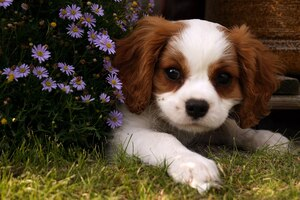

In [21]:
img_fn = Path('samples/puppy.jpg')
Image(filename=img_fn, width=200)

In [22]:
msg = mk_msg(['hey what in this image?',img_fn.read_bytes()])
str(msg)[:300]

"Msg(role='user', content=[Text(raw=None, cache_control=None, text='hey what in this image?', citations=None), InputImage(raw=None, cache_control=None, text='data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/4gxUSUNDX1BST0ZJTEUAAQEAAAxEVUNDTQJAAABtbnRyUkdCIFhZWiAH0wAEAAQAAAAAAABhY3NwTVNGVAAAAABDQU5P"

In [23]:
await c(msg)


::: details
## Thinking

Okay, here's my take on those image details, tailored for an expert's eye:

**My Initial Assessment of the Image**

Right, so the user wants me to break down this image. My first impression is a delightful Cavalier King Charles Spaniel puppy – specifically, a Blenheim coloration. We're looking at a classic chestnut and white pattern, a hallmark of the breed. Judging from the composition, the puppy's positioned as the focal point, and for good reason. Those large, dark eyes and floppy ears are utterly captivating, just as a good puppy should be. The direct gaze is likely intentional to form a connection with the viewer, and the photographer has clearly done their job well.

Then we have the setting. It’s clearly an outdoor garden scene, a choice that adds context to the subject. The inclusion of a bush of purple or lavender aster flowers is interesting from a composition standpoint. It adds complementary color, likely chosen for its visual appeal against the Blenheim markings. The presence of asters also helps place the photograph in a specific time of year, depending on the particular variety and bloom time. The puppy's likely lying in the grass, which provides a natural and appealing texture for the scene. Overall, a classic, well-executed photograph of a beautiful puppy, and the elements present have been chosen to increase its inherent charm.




:::

The image shows an adorable **Cavalier King Charles Spaniel puppy** lying on green grass in a garden. 

Key details include:
* **The Puppy:** It has classic "Blenheim" coloring (chestnut/brown and white), floppy ears, and large, dark, expressive eyes looking directly at the camera.
* **Surroundings:** To its left is a lush green bush filled with small purple/lavender aster-like flowers, adding a lovely natural backdrop.

::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=1087, completion_tokens=101, total_tokens=1277, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=89, search_queries=0, raw={'promptTokenCount': 1087, 'candidatesTokenCount': 101, 'totalTokenCount': 1277, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 7}, {'modality': 'IMAGE', 'tokenCount': 1080}], 'thoughtsTokenCount': 89, 'serviceTier': 'standard'})`

:::

In [24]:
await c(msg, kimi, vendor_name='fireworks_ai')


::: details
## Thinking

The user is asking what's in the image. I can see a puppy - looks like a Cavalier King Charles Spaniel puppy with white and chestnut/brown fur, lying on grass next to purple flowers (asters). Need answer concise. Mention I can describe. No need identify people. Ensure no unsupported certainty? Say appears to be. Final answer.

:::

It’s a cute puppy, likely a Cavalier King Charles Spaniel, with white and reddish-brown fur, lying in the grass beside purple flowers.

::: details

- model: `accounts/fireworks/models/kimi-k3`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=191, completion_tokens=116, total_tokens=307, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=72, search_queries=0, raw={'prompt_tokens': 191, 'total_tokens': 307, 'completion_tokens': 116, 'prompt_tokens_details': {'cached_tokens': 0}, 'completion_tokens_details': {'reasoning_tokens': 72}, 'output_tokens_details': {'reasoning_tokens': 72}})`

:::

In [25]:
msg = mk_msg(['What is this image?', MediaUrl(sample_img_url)])
msg

**Msg**

- role: `user`

<contents>

**Text** (`text`)

What is this image?

::: details

- raw: `None`
- citations: `None`

:::

**InputImage** (`input_image`)

https://img.magnific.com/free-photo/mountain-range-body-water_53876-139760.jpg?semt=ais_hybrid&w=740&q=80

::: details

- raw: `None`
- mime: `image/jpeg`

:::

</contents>

In [26]:
await c(msg)


::: details
## Thinking

**My Assessment of the Image**

Okay, so the user wants me to break down this image. My initial impression is that it's a pretty textbook composition – feels familiar, like something I've seen a hundred times. Let's dissect it.

In the immediate foreground, we've got this weathered wooden surface. It looks like planks, maybe part of a deck, pier, or even just a rustic table, arranged in a vertical pattern that provides some nice perspective leading the eye deeper into the scene.

Then, the real star – that stunning alpine lake in the middleground. It's calm, almost glass-like, beautifully reflecting the trees and those majestic mountains in the distance. The clarity of the reflection is what jumps out at me; this is probably a Lake Matheson situation in New Zealand, famous for mirroring Aoraki/Mount Cook and Mount Tasman. Or, at least, it’s a similar lake in the Southern Alps, New Zealand, known for its pristine beauty. The specific location isn't crucial, it's the *type* of location.

Finally, the background. We're talking lush, vibrant green forest lining the shoreline, and then those towering mountain peaks, likely snow-dusted, definitely rocky, bathed in a soft, hazy daylight. The atmospheric perspective is on point.

Overall, it's a classic setup. This is the kind of composition frequently used in composite images, stock photos, or even as a mockup template. I’d bet money it’s designed to be versatile; it could be the background for a product display, a desktop wallpaper, or something similar. It's intended to evoke a sense of tranquility and natural beauty.




:::

This is a scenic landscape image featuring:

* **Foreground:** A rustic, weathered wooden dock or tabletop made of dark timber planks leading out toward the water (commonly used in mockups and photography for product placement).
* **Middle Ground:** A calm, glassy alpine lake (very reminiscent of **Lake Matheson** on the South Island of New Zealand) perfectly mirroring the surrounding landscape. A dense evergreen forest lines the far edge of the shore.
* **Background:** Majestic, hazy mountain ranges with snow-capped peaks (typical of the Southern Alps) under a bright, soft blue sky.

Images like this are frequently used as digital backgrounds, desktop wallpapers, or advertising mockups to convey serenity, nature, and outdoor travel.

::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=1086, completion_tokens=148, total_tokens=1397, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=163, search_queries=0, raw={'promptTokenCount': 1086, 'candidatesTokenCount': 148, 'totalTokenCount': 1397, 'promptTokensDetails': [{'modality': 'IMAGE', 'tokenCount': 1080}, {'modality': 'TEXT', 'tokenCount': 6}], 'thoughtsTokenCount': 163, 'serviceTier': 'standard'})`

:::

Or include a PDF:

In [27]:
pdf_fn = Path('samples/solveit.pdf')
msg = mk_msg(['Who is the author of this pdf?', pdf_fn.read_bytes()])
await c(msg)

The author of this document is **Jeremy Howard** (from fast.ai).

::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=541, completion_tokens=16, total_tokens=557, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'promptTokenCount': 541, 'candidatesTokenCount': 16, 'totalTokenCount': 557, 'promptTokensDetails': [{'modality': 'IMAGE', 'tokenCount': 532}, {'modality': 'TEXT', 'tokenCount': 9}], 'serviceTier': 'standard'})`

:::

In [28]:
msg = mk_msg([MediaUrl("https://arxiv.org/pdf/1706.03762"), 'What is the title of this paper?']); msg

**Msg**

- role: `user`

<contents>

**InputFile** (`input_file`)

https://arxiv.org/pdf/1706.03762

::: details

- raw: `None`
- mime: `application/pdf`

:::

**Text** (`text`)

What is the title of this paper?

::: details

- raw: `None`
- citations: `None`

:::

</contents>

In [29]:
await c(msg)


::: details
## Thinking

Okay, here's my interpretation of that thought process, tailored for an expert audience, and written in the first person:

**Identifying the Source**

Alright, let's get down to brass tacks. I need to quickly identify the paper this PDF refers to. My immediate focus is, of course, the title. I know I need to find the title page. Page 1, naturally, is the place to start. And, bingo, there it is: "Attention Is All You Need." Pretty clear, and a familiar title I can work with. Now I can move on to the actual content of the paper.




:::

The title of the paper is **"Attention Is All You Need"**.

::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=7809, completion_tokens=15, total_tokens=7854, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=30, search_queries=0, raw={'promptTokenCount': 7809, 'candidatesTokenCount': 15, 'totalTokenCount': 7854, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 9}, {'modality': 'IMAGE', 'tokenCount': 7800}], 'thoughtsTokenCount': 30, 'serviceTier': 'standard'})`

:::

For a model that accepts audio or video, such as Gemini:

In [30]:
wav_data = httpx2.get("https://openaiassets.blob.core.windows.net/$web/API/docs/audio/alloy.wav").content
# Audio(wav_data)  # uncomment to preview

In [31]:
msg = mk_msg(['What is this audio saying?', wav_data])
await c([msg], flash)

The audio says: "The sun rises in the east and sets in the west. This simple fact has been observed by humans for thousands of years."

::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=181, completion_tokens=30, total_tokens=211, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'promptTokenCount': 181, 'candidatesTokenCount': 30, 'totalTokenCount': 211, 'promptTokensDetails': [{'modality': 'AUDIO', 'tokenCount': 174}, {'modality': 'TEXT', 'tokenCount': 7}], 'serviceTier': 'standard'})`

:::

In [32]:
msg = mk_msg(['What is this audio saying?', MediaUrl("https://openaiassets.blob.core.windows.net/$web/API/docs/audio/alloy.wav")])
await c([msg], flash)

Here is the transcription of the audio:

"The sun rises in the east and sets in the west. This simple fact has been observed by humans for thousands of years."

::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=181, completion_tokens=35, total_tokens=216, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'promptTokenCount': 181, 'candidatesTokenCount': 35, 'totalTokenCount': 216, 'promptTokensDetails': [{'modality': 'AUDIO', 'tokenCount': 174}, {'modality': 'TEXT', 'tokenCount': 7}], 'serviceTier': 'standard'})`

:::

In [33]:
vid_data = httpx2.get("https://storage.googleapis.com/github-repo/img/gemini/multimodality_usecases_overview/pixel8.mp4").content

In [34]:
msg = mk_msg(['Concisely, what is happening in this video?', vid_data])
await c([msg], flash)

A Japanese photographer, Saeka Shimada, captures night scenes in Tokyo using the Video Boost and Night Sight features on the Google Pixel 8 Pro.

::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=5199, completion_tokens=30, total_tokens=5229, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'promptTokenCount': 5199, 'candidatesTokenCount': 30, 'totalTokenCount': 5229, 'promptTokensDetails': [{'modality': 'VIDEO', 'tokenCount': 5187}, {'modality': 'TEXT', 'tokenCount': 12}], 'serviceTier': 'standard'})`

:::

In [35]:
msg = mk_msg(['Concisely, what is happening in this video?', MediaUrl("https://storage.googleapis.com/github-repo/img/gemini/multimodality_usecases_overview/pixel8.mp4")])
await c([msg], flash)

In the video, Tokyo photographer Saeka Shimada walks through the city at night, testing out the low-light camera capabilities of the Google Pixel 8 Pro (specifically features like Video Boost and Night Sight) to capture night scenes, alleys, and details, before heading to Shibuya to meet friends.

::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=5204, completion_tokens=60, total_tokens=5264, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'promptTokenCount': 5204, 'candidatesTokenCount': 60, 'totalTokenCount': 5264, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 17}, {'modality': 'VIDEO', 'tokenCount': 5187}], 'serviceTier': 'standard'})`

:::

### Reconstructing formatted outputs

A Lisette-style tool loop can produce several calls and results before the final answer. We'd like to show that as one editable reply, then turn the edited text back into fastllm messages.

Here's an example of that display format. Later we'll write the chat loop that produces it.

In [36]:
fmt_outp = '''
I'll solve this step-by-step, using parallel calls where possible.

```json {.tool}
{
  "id": "toolu_01KjnQH2Nsz2viQ7XYpLW3Ta",
  "name": "simple_add",
  "args": {
    "a": 10,
    "b": 5
  },
  "result": "15"
}
```

```json {.tool}
{
  "id": "toolu_01Koi2EZrGZsBbnQ13wuuvzY",
  "name": "simple_add",
  "args": {
    "a": 2,
    "b": 1
  },
  "result": "3"
}
```

Now I need to multiply 15 * 3 before I can do the final division:

```json {.tool}
{
  "id": "toolu_0141NRaWUjmGtwxZjWkyiq6C",
  "name": "multiply",
  "args": {
    "a": 15,
    "b": 3
  },
  "result": "45"
}
```

```json {.usage}
{"summary": "Cache hit: 81.8% | Tokens: total=23,276 input=23,158 (+18,910 cached, 0 new) output=118 (reasoning 23)", "detail": "Usage(prompt_tokens=3, completion_tokens=10, total_tokens=13, raw={'input_tokens': 3, 'cache_creation_input_tokens': 2079, 'cache_read_input_tokens': 2070, 'cache_creation': {'ephemeral_5m_input_tokens': 2079, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 10, 'service_tier': 'standard', 'inference_geo': 'global'})"}
```'''


`parse_tools` returns `(text, data)` pairs. `data` holds the parsed tool block, or `None` for text without a following block:

In [37]:
for txt,d in parse_tools(fmt_outp): print('- ', (txt, d))

-  ("\nI'll solve this step-by-step, using parallel calls where possible.\n\n", {'id': 'toolu_01KjnQH2Nsz2viQ7XYpLW3Ta', 'name': 'simple_add', 'args': {'a': 10, 'b': 5}, 'result': '15'})
-  ('\n', {'id': 'toolu_01Koi2EZrGZsBbnQ13wuuvzY', 'name': 'simple_add', 'args': {'a': 2, 'b': 1}, 'result': '3'})
-  ('\nNow I need to multiply 15 * 3 before I can do the final division:\n\n', {'id': 'toolu_0141NRaWUjmGtwxZjWkyiq6C', 'name': 'multiply', 'args': {'a': 15, 'b': 3}, 'result': '45'})
-  ('\n```json {.usage}\n{"summary": "Cache hit: 81.8% | Tokens: total=23,276 input=23,158 (+18,910 cached, 0 new) output=118 (reasoning 23)", "detail": "Usage(prompt_tokens=3, completion_tokens=10, total_tokens=13, raw={\'input_tokens\': 3, \'cache_creation_input_tokens\': 2079, \'cache_read_input_tokens\': 2070, \'cache_creation\': {\'ephemeral_5m_input_tokens\': 2079, \'ephemeral_1h_input_tokens\': 0}, \'output_tokens\': 10, \'service_tier\': \'standard\', \'inference_geo\': \'global\'})"}\n```', None)


#### fmt2hist

`fmt2hist` turns the formatted reply into a list of `Msg` objects:

In [38]:
from pprint import pprint

In [39]:
h = fmt2hist(fmt_outp)
pprint(h)

[Msg(role='assistant', content=[Text(raw=None, cache_control=None, text="I'll solve this step-by-step, using parallel calls where possible.", citations=None), ToolUse(raw=None, cache_control=None, id='toolu_01KjnQH2Nsz2viQ7XYpLW3Ta', name='simple_add', arguments={'a': 10, 'b': 5}, server=False, text=None), ToolUse(raw=None, cache_control=None, id='toolu_01Koi2EZrGZsBbnQ13wuuvzY', name='simple_add', arguments={'a': 2, 'b': 1}, server=False, text=None)], raw=None),
 Msg(role='tool', content=[ToolResult(raw=None, cache_control=None, id='toolu_01KjnQH2Nsz2viQ7XYpLW3Ta', name='simple_add', arguments={}, server=False, text='15'), ToolResult(raw=None, cache_control=None, id='toolu_01Koi2EZrGZsBbnQ13wuuvzY', name='simple_add', arguments={}, server=False, text='3')], raw=None),
 Msg(role='assistant', content=[Text(raw=None, cache_control=None, text='Now I need to multiply 15 * 3 before I can do the final division:', citations=None), ToolUse(raw=None, cache_control=None, id='toolu_0141NRaWUjmGtw

In [40]:
sch = {'type': 'function',
    'function': {'name': 'simple_div',
        'description': 'divide numbers',
        'parameters': {'type': 'object',
            'properties': {'a': {'description': '', 'type': 'integer'},
                'b': {'description': '', 'type': 'integer'}},
            'required': ['a', 'b']}}}

In [41]:
user_q = Msg(role='user', content=[Text('Compute (10+5) * (2+1), then divide by 5.')])
fin_q  = Msg(role='user', content=[Text('Continue')])
for m in ms:
    display(Markdown(f'**{m}:**'))
    display(await c([user_q] + h + [fin_q], m, tools=[sch]))

**models/gemini-3.8-flash:**



🔧 simple_div({'a': 45, 'b': 5})


::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `tool_calls`
- usage: `Usage(prompt_tokens=205, completion_tokens=19, total_tokens=224, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'promptTokenCount': 205, 'candidatesTokenCount': 19, 'totalTokenCount': 224, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 205}], 'serviceTier': 'standard'})`

:::

**claude-sonnet-5-5:**

I should correct something first. The only tool I have is `simple_div`. My earlier calls to `simple_add` and `multiply` used tools I don't have. The values they returned (15, 3, 45) are correct, and I checked them by hand. I'll do the final division with the real tool.

🔧 simple_div({'a': 45, 'b': 5})


::: details

- model: `claude-sonnet-5-5`
- finish_reason: `tool_calls`
- usage: `Usage(prompt_tokens=735, completion_tokens=158, total_tokens=971, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=78, search_queries=0, raw={'input_tokens': 735, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'cache_creation': {'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 236, 'output_tokens_details': {'thinking_tokens': 78}, 'service_tier': 'standard', 'inference_geo': 'global'})`

:::

**gpt-6-luna:**



🔧 simple_div({'a': 45, 'b': 5})


::: details

- model: `gpt-6-luna`
- finish_reason: `tool_calls`
- usage: `Usage(prompt_tokens=228, completion_tokens=37, total_tokens=265, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=13, search_queries=0, raw={'input_tokens': 228, 'input_tokens_details': {'cache_write_tokens': 0, 'cached_tokens': 0}, 'output_tokens': 37, 'output_tokens_details': {'reasoning_tokens': 13}, 'total_tokens': 265})`

:::

In [42]:
# Text with only result fences (no structured tools)
txt = 'Let me calculate.\n`````py\n1+1\n`````\n\n`````result\n2\n`````\n\nDone.'
h = fmt2hist(txt)
test_eq([m.role for m in h], ['assistant', 'user', 'assistant'])

# Pure text — unchanged (1 asst msg)
h = fmt2hist('Hello')
test_eq([m.role for m in h], ['assistant'])

h = fmt2hist(fmt_outp)
roles = [m.role for m in h]
test_eq(roles.count('assistant'), 3)
test_eq(roles.count('tool'), 2)

### Reasoning effort


`reasoning_effort` names include `minimal`, `low`, `medium`, `high`, `xhigh`, and `max`; which ones work depends on the model. Anthropic's adapter uses adaptive thinking where the model supports it when you request thinking. For Gemini, the adapter chooses `thinkingLevel` on newer models and a `thinkingBudget` on older ones, as LiteLLM does. The OpenAI Responses and Chat adapters pass the level through.

In [43]:
res = await c([mk_msg("What's 213127*451233? Think step by step. ")], opus, reasoning_effort='medium')
res

# 213127 × 451233 = 96,169,935,591

**Step 1: Split the second number**

451233 = 451000 + 233

**Step 2: Compute 213127 × 451**
- 213127 × 400 = 85,250,800
- 213127 × 50 = 10,656,350
- 213127 × 1 = 213,127
- Sum: 96,120,277

So 213127 × 451000 = 96,120,277,000.

**Step 3: Compute 213127 × 233**
- 213127 × 200 = 42,625,400
- 213127 × 33 = 7,033,191
- Sum: 49,658,591

**Step 4: Add the parts**

96,120,277,000 + 49,658,591 = **96,169,935,591**

**Check (casting out nines):** The digits of 451233 sum to 18, so it is divisible by 9. The product must therefore be divisible by 9. The digits of 96,169,935,591 sum to 63, which is divisible by 9, so the result passes the check.

::: details

- model: `claude-opus-5-5`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=23, completion_tokens=336, total_tokens=636, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=277, search_queries=0, raw={'input_tokens': 23, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'cache_creation': {'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 613, 'output_tokens_details': {'thinking_tokens': 277}, 'service_tier': 'standard', 'inference_geo': 'global'})`

:::

The response keeps thinking and answer text in separate parts:

In [44]:
L(res.message.content).attrgot('type')

[<PartType.thinking: 'thinking'>, <PartType.text: 'text'>]

## Streaming

A stream yields parts as they arrive, then ends with a `Completion` of the same type you get from a non-streaming request.

The API is async, including the helpers that collect streams.

In [45]:
#| export
def cite_footnote(citations):
    'Build citation footnotes for a single Delta'
    links = []
    for c in citations:
        if 'title' not in c: return ''
        title = c['title'].replace('"', '\\"')
        links.append(f'[*]({c["url"]} "{title}")')
    return ' '.join(links)

In [46]:
#| export
def postproc(chunk):
    'Convert Anthropic citations into hyperlink text'
    if isinstance(chunk, Text) and chunk.citations: return Text(cite_footnote(chunk.citations))
    return chunk

In [47]:
@asave_iter
async def stream_with_complete(self, gen, postproc=postproc):
    async for chunk in gen:
        if isinstance(chunk, Completion): self.value = chunk
        else: yield postproc(chunk)

`acollect_stream` yields typed `Part` deltas—text, thinking, citation-bearing text, and refusals—and assembles the final `Completion`.

Citations don't arrive in the same form on every API. Anthropic can send citation events alongside text; Gemini supplies grounding metadata, often near the end. OpenAI Responses text already includes citation links. `postproc` turns citation-bearing `Text` parts into links for display; it replaces that part's text rather than appending to it, so it expects citations in their own part.

After a round of tools finishes, `AsyncChat` sends a `Refresh` so the display can replace its pending tool rows with the results now in `hist`. `think_sep` inserts a blank line when the stream crosses between thinking/status parts and other content.

In [48]:
#| export
class Refresh:
    "Stream signal: state-holding renderers should re-render in full (e.g. via `AsyncChat.full`)"
    formatted = ''

def think_sep(last, typ, sep='\n\n'):
    "Separator to insert between `formatted` items when crossing a 🧠↔text boundary"
    think = {PartType.thinking, 'status'}
    return sep if last and typ and (typ in think) != (last in think) else ''

In [49]:
async def print_stream(r):
    "Minimal terminal renderer: print each item's `formatted`, with a newline at 🧠↔text boundaries"
    last = None
    async for o in r:
        typ = getattr(o, 'type', None)
        if think_sep(last, typ): print()
        if f := getattr(o, 'formatted', ''): print(f, end='', flush=True)
        if typ is not None: last = typ
    return o

In [50]:
r = await c(mk_msgs("Hi!"),stream=True)
r2 = stream_with_complete(r)
await print_stream(r2)

Hello! How can I help you today?

**Text** (`text`)

Hello! How can I help you today?

::: details

- raw: `None`
- citations: `None`

:::

In [51]:
r2.value

Hello! How can I help you today?

::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=3, completion_tokens=9, total_tokens=12, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'promptTokenCount': 3, 'candidatesTokenCount': 9, 'totalTokenCount': 12, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 3}], 'serviceTier': 'standard'})`

:::

In [52]:
r = await c(mk_msgs("What's the weather in Istanbul"), m=ms[-2], stream=True, web_search_options={})
r2 = stream_with_complete(r, postproc)
await print_stream(r2)

Today (Oct 7) in Istanbul looks pleasant, based on the sources that match today's date.

- **High:** about 74°F (23°C).
- **Low:** about 55°F (13°C).
- **Sky:** [*](https://weather.yahoo.com/tr/istanbul/istanbul/ "Istanbul, TR Weather Forecast, Conditions, and Maps")Mostly cloudy in the Yahoo forecast. AccuWeather has it [*](https://www.accuweather.com/en/tr/istanbul/318251/weather-today/318251 "Weather Today for Istanbul, Istanbul, Türkiye")turning cloudy during the day, then clear to partly cloudy overnight.
- **Rain:** very unlikely. AccuWeather gives [*](https://www.accuweather.com/en/tr/istanbul/318251/weather-today/318251 "Weather Today for Istanbul, Istanbul, Türkiye")a 2% chance of precipitation.
- **Wind:** [*](https://www.accuweather.com/en/tr/istanbul/318251/weather-today/318251 "Weather Today for Istanbul, Istanbul, Türkiye")ENE at about 9 mph, with gusts up to 20 mph.
- **Evening:** it cools off, so [*](https://www.accuweather.com/en/tr/istanbul/318251/weather-today/318251

**Text** (`text`)

 out.

::: details

- raw: `None`
- citations: `None`

:::

The following live example checks web search with `code_execution`. That combination has sometimes returned no citations:

In [53]:
r2.value



🔧 web_search({'query': 'Istanbul weather today'})
Today (Oct 7) in Istanbul looks pleasant, based on the sources that match today's date.

- **High:** about 74°F (23°C).
- **Low:** about 55°F (13°C).
- **Sky:** Mostly cloudy in the Yahoo forecast. AccuWeather has it turning cloudy during the day, then clear to partly cloudy overnight.
- **Rain:** very unlikely. AccuWeather gives a 2% chance of precipitation.
- **Wind:** ENE at about 9 mph, with gusts up to 20 mph.
- **Evening:** it cools off, so a light jacket or sweater may be appropriate.

Some of the other results were old or for different dates, so I left them out.

::: details

- model: `claude-sonnet-5-5`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=13703, completion_tokens=392, total_tokens=14095, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=1, raw={'input_tokens': 13703, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'output_tokens': 392, 'output_tokens_details': {'thinking_tokens': 0}, 'server_tool_use': {'web_search_requests': 1, 'web_fetch_requests': 0}})`

:::

For comparison, try the older search tool version below. Whether it produces citations still depends on the response:

In [54]:
r = await c(mk_msgs("What's the weather in Istanbul"), m=ms[-2], stream=True, web_search_options={'type': 'web_search_20250305'})
r2 = stream_with_complete(r, postproc)
await print_stream(r2)

Today (Oct 7) in Istanbul looks pleasant, based on the sources that match today's date.

- **High:** about 74°F (23°C).
- **Low:** about 55°F (13°C).
- **Sky:** [*](https://weather.yahoo.com/tr/istanbul/istanbul/ "Istanbul, TR Weather Forecast, Conditions, and Maps")Mostly cloudy in the Yahoo forecast. AccuWeather has it [*](https://www.accuweather.com/en/tr/istanbul/318251/weather-today/318251 "Weather Today for Istanbul, Istanbul, Türkiye")turning cloudy during the day, then clear to partly cloudy overnight.
- **Rain:** very unlikely. AccuWeather gives [*](https://www.accuweather.com/en/tr/istanbul/318251/weather-today/318251 "Weather Today for Istanbul, Istanbul, Türkiye")a 2% chance of precipitation.
- **Wind:** [*](https://www.accuweather.com/en/tr/istanbul/318251/weather-today/318251 "Weather Today for Istanbul, Istanbul, Türkiye")ENE at about 9 mph, with gusts up to 20 mph.
- **Evening:** it cools off, so [*](https://www.accuweather.com/en/tr/istanbul/318251/weather-today/318251

**Text** (`text`)

 out.

::: details

- raw: `None`
- citations: `None`

:::

In [55]:
r2.value



🔧 web_search({'query': 'Istanbul weather today'})
Today (Oct 7) in Istanbul looks pleasant, based on the sources that match today's date.

- **High:** about 74°F (23°C).
- **Low:** about 55°F (13°C).
- **Sky:** Mostly cloudy in the Yahoo forecast. AccuWeather has it turning cloudy during the day, then clear to partly cloudy overnight.
- **Rain:** very unlikely. AccuWeather gives a 2% chance of precipitation.
- **Wind:** ENE at about 9 mph, with gusts up to 20 mph.
- **Evening:** it cools off, so a light jacket or sweater may be appropriate.

Some of the other results were old or for different dates, so I left them out.

::: details

- model: `claude-sonnet-5-5`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=13703, completion_tokens=392, total_tokens=14095, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=1, raw={'input_tokens': 13703, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'output_tokens': 392, 'output_tokens_details': {'thinking_tokens': 0}, 'server_tool_use': {'web_search_requests': 1, 'web_fetch_requests': 0}})`

:::

## Tools

In [56]:
#| export
def lite_mk_func(f):
    if isinstance(f, dict): return f
    return {'type':'function', 'function':get_schema(f, pname='parameters')}

In [57]:
def simple_add(
    a: int,   # first operand
    b: int=0  # second operand
) -> int:
    "Add two numbers together"
    return a + b

In [58]:
toolsc = lite_mk_func(simple_add)

In [59]:
tmsg = mk_msg("What is 5478954793+547982745? How about 5479749754+9875438979? Always use tools for calculations, and describe what you'll do before using a tool. Where multiple tool calls are required, do them in a single response where possible. ")
r = await c(tmsg, tools=[toolsc])

In [60]:
r

I will calculate both additions by calling the `simple_add` tool for each pair of numbers:
1. First, I will add `5478954793` and `547982745`.
2. Second, I will add `5479749754` and `9875438979`.

🔧 simple_add({'b': 547982745, 'a': 5478954793})


🔧 simple_add({'b': 9875438979, 'a': 5479749754})


::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `tool_calls`
- usage: `Usage(prompt_tokens=160, completion_tokens=156, total_tokens=316, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'promptTokenCount': 160, 'candidatesTokenCount': 156, 'totalTokenCount': 316, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 160}], 'serviceTier': 'standard'})`

:::

`Completion.tool_calls` gives you the calls to execute. Pair them with your results using `mk_tool_res_msg` (imported here from aidialog):

In [61]:
display_list(r.tool_calls)

🔧 **simple_add**(`{'b': 547982745, 'a': 5478954793}`)

::: details

- id: `call_233977`
- server: `False`
- raw: `{'thoughtSignature': 'EmkKZwFpFH0TJDeGr/MyRutsxAYI2XsQ9wyEx9hOs4n3O4NCOJVMirkDmvEol00KpMSKb7khS1Q3fZudbwfV4mboVOUtGlr+dyvCMYF06J/3DlMwMUV3++Lbhcg7PU2o/g9qgcQ4FvXSaz0='}`

:::

🔧 **simple_add**(`{'b': 9875438979, 'a': 5479749754}`)

::: details

- id: `call_233978`
- server: `False`
- raw: `{}`

:::

Append `Completion.message` to the history before sending the tool results:

In [62]:
r.message

**Msg**

- role: `assistant`

<contents>

**Text** (`text`)

I will calculate both additions by calling the `simple_add` tool for each pair of numbers:
1. First, I will add `5478954793` and `547982745`.
2. Second, I will add `5479749754` and `9875438979`.

::: details

- raw: `{'text': 'I will calculate both additions by calling the `simple_add` tool for each pair of numbers:\n1. First, I will add `5478954793` and `547982745`.\n2. Second, I will add `5479749754` and `9875438979`.'}`
- citations: `[]`

:::

🔧 **simple_add**(`{'b': 547982745, 'a': 5478954793}`)

::: details

- id: `call_233977`
- server: `False`
- raw: `{'thoughtSignature': 'EmkKZwFpFH0TJDeGr/MyRutsxAYI2XsQ9wyEx9hOs4n3O4NCOJVMirkDmvEol00KpMSKb7khS1Q3fZudbwfV4mboVOUtGlr+dyvCMYF06J/3DlMwMUV3++Lbhcg7PU2o/g9qgcQ4FvXSaz0='}`

:::

🔧 **simple_add**(`{'b': 9875438979, 'a': 5479749754}`)

::: details

- id: `call_233978`
- server: `False`
- raw: `{}`

:::

</contents>

`_mk_tool_result` prepares a tool's return value for `mk_tool_res_msg`. A `ToolResponse` supplies its content directly, including media parts. Other values go through `tool_text`: strings keep their type, dictionaries and lists become JSON, lists of parts contribute their text, and other objects become strings.

In [63]:
tool_calls = [ToolUse(id='123', name='simple_add', arguments={'a': 3, 'b': 5}, raw={'type': 'function'}), 
    ToolUse(id='456', name='simple_add', arguments={'a': 10, 'b': 20}, raw={'type': 'function'})]

In [64]:
#| export
def _mk_tool_result(res):
    "Unwrap `ToolResponse`, and format tool result message"
    if isinstance(res, ToolResponse): return res.content
    return tool_text(res)

In [65]:
_mk_tool_result('8'), _mk_tool_result('30')

('8', '30')

In [66]:
mk_tool_res_msg(tool_calls, (_mk_tool_result('8'), _mk_tool_result('30')))

**Msg**

- role: `tool`

<contents>

**ToolResult** (`tool_result`)

8

::: details

- raw: `None`
- id: `123`
- name: `simple_add`
- arguments: `{'a': 3, 'b': 5}`
- server: `False`

:::

**ToolResult** (`tool_result`)

30

::: details

- raw: `None`
- id: `456`
- name: `simple_add`
- arguments: `{'a': 10, 'b': 20}`
- server: `False`

:::

</contents>

In particular, `ToolResponse` must keep an `InputImage` or `InputFile` as a part rather than stringify it:

In [67]:
img_content = [InputImage('data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAAQAAAAECAIAAAAmkwkpAAAAEElEQVR4nGP4z8AARwzEcQCukw/x0F8jngAAAABJRU5ErkJggg==')]
res = _mk_tool_result(ToolResponse(img_content))
test_eq(res, img_content)  # ToolResponse should pass through
res

[InputImage(raw=None, cache_control=None, text='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAAQAAAAECAIAAAAmkwkpAAAAEElEQVR4nGP4z8AARwzEcQCukw/x0F8jngAAAABJRU5ErkJggg==', mime=None)]

In [68]:
def test_img(): "Show the test image"
msg0 = mk_msg('Call test_img, then describe what it shows in one sentence.')
r0 = await c(msg0, tools=[lite_mk_func(test_img)])
msg1, msg2 = r0.message, mk_tool_res_msg(r0.tool_calls, [res])


In [69]:
[msg0,msg1,msg2]

[Msg(role='user', content=[Text(raw=None, cache_control=None, text='Call test_img, then describe what it shows in one sentence.', citations=None)], raw=None),
 Msg(role='assistant', content=[ToolUse(raw={'thoughtSignature': 'EmkKZwFpFH0T/T1Nbve8qF+XyY48vPsubrlQPKKKnYhADimVk1MWM2pWi/FFRJANkW3Dz70QZWt8yZodRsT+KoMnNJTsQD+dbtY0IENym4MuKoiRNhDjpqiWgjrDW9c7s5Kk1MAfNbNNviI='}, cache_control=None, id='call_142822', name='test_img', arguments={}, server=False, text=None)], raw={'parts': [{'functionCall': {'name': 'test_img', 'args': {}, 'id': 'call_142822'}, 'thoughtSignature': 'EmkKZwFpFH0T/T1Nbve8qF+XyY48vPsubrlQPKKKnYhADimVk1MWM2pWi/FFRJANkW3Dz70QZWt8yZodRsT+KoMnNJTsQD+dbtY0IENym4MuKoiRNhDjpqiWgjrDW9c7s5Kk1MAfNbNNviI='}], 'role': 'model'}),
 Msg(role='tool', content=[ToolResult(raw=None, cache_control=None, id='call_142822', name='test_img', arguments={}, server=False, text=[InputImage(raw=None, cache_control=None, text='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAAQAAAAECAIAAAAmkwkpAAAAE

In [70]:
r = await c([msg0,msg1,msg2], tools=[lite_mk_func(test_img)])
r


The image displays a solid, uniform bright red square.

::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=1152, completion_tokens=11, total_tokens=1163, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'promptTokenCount': 1152, 'candidatesTokenCount': 11, 'totalTokenCount': 1163, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 63}, {'modality': 'IMAGE', 'tokenCount': 1089}], 'serviceTier': 'standard'})`

:::

In [71]:
#| export
def _call_func(tc:ToolUse, tool_schemas, ns, callf):
    "Call tool function synchronously and return formatted result"
    fn, valid = tc.name, {fs[0] for o in tool_schemas or [] if (fs:=fn_schema(o))}
    if fn not in valid: return f"Tool not defined in tool_schemas: {fn}"
    else: return callf(fn, tc.arguments, ns=ns, raise_on_err=False)

In [72]:
#| export
def _lite_call_func(tc, tool_schemas, ns):
    "Call tool function synchronously and return formatted result"
    res = _call_func(tc, tool_schemas, ns, call_func)
    return _mk_tool_result(res)

In [73]:
tcres = [_lite_call_func(o, [toolsc], ns=globals()) for o in tool_calls]
tcres

['8', '30']

In [74]:
mk_tool_res_msg(tool_calls, tcres)

**Msg**

- role: `tool`

<contents>

**ToolResult** (`tool_result`)

8

::: details

- raw: `None`
- id: `123`
- name: `simple_add`
- arguments: `{'a': 3, 'b': 5}`
- server: `False`

:::

**ToolResult** (`tool_result`)

30

::: details

- raw: `None`
- id: `456`
- name: `simple_add`
- arguments: `{'a': 10, 'b': 20}`
- server: `False`

:::

</contents>

A call to a name absent from `tool_schemas` returns an error message instead of running the function:

In [75]:
fake_tc = ToolUse(id='_', name='hallucinated_tool')
test_eq(_lite_call_func(fake_tc, ns=globals(), tool_schemas=[toolsc]),"Tool not defined in tool_schemas: hallucinated_tool")
test_eq(_lite_call_func(fake_tc, ns=globals(), tool_schemas=None),"Tool not defined in tool_schemas: hallucinated_tool")

You can also ask the provider to choose a particular tool. `structured` uses that to request the schema for a class or callable, then constructs the result from the first tool call's arguments. This is a provider request, not another local allow-list check.

## Structured Outputs

In [76]:
#| export
@delegates(acomplete)
async def structured(
    m:str,          # LiteLLM model string
    msgs:list,      # List of messages
    tool:Callable,  # Tool to be used for creating the structured output (class, dataclass or Pydantic, function, etc)
    sp:str|Part='', # System message
    **kwargs
):
    "Return the value of the tool call (generally used for structured outputs)"
    t = lite_mk_func(tool)
    name = fn_schema(t)[0]
    v,mn = split_vendor(m)
    forced = get_model_info(mn, kwargs.get('vendor_name') or v).get('supports_forced_tool_use', True)
    if not forced: sp = f"{part_txt(sp)}\n\nAnswer by calling the `{name}` tool.".strip()
    r = await acomplete(msgs, m, system=sp, tools=[t], tool_choice=name if forced else 'auto', **kwargs)
    if not r.tool_calls: raise ValueError(f"{m} answered without calling `{name}`")
    return tool(**r.tool_calls[0].arguments)

Some models, including the current Claude models, don't support forcing a tool call. For a model whose metadata sets `supports_forced_tool_use` to false, `structured` uses `tool_choice='auto'` and adds a system instruction to call the tool. It raises `ValueError` if the model answers without calling it.

In [77]:
class President:
    "Information about a president of the United States"
    def __init__(
        self,
        first:str, # first name
        last:str, # last name
        spouse:str, # name of spouse
        years_in_office:str, # format: "{start_year}-{end_year}"
        birthplace:str, # name of city
        birth_year:int # year of birth, `0` if unknown
    ):
        assert re.match(r'\d{4}-\d{4}', years_in_office), "Invalid format: `years_in_office`"
        store_attr()

    __repr__ = basic_repr('first, last, spouse, years_in_office, birthplace, birth_year')

In [78]:
for m in ms:
    r = await structured(m, [mk_msg("Tell me something about the third president of the USA.")], tool=President)
    test_eq(r.first, 'Thomas')
    test_eq(r.last, 'Jefferson')

In [79]:
r

President(first='Thomas', last='Jefferson', spouse='Martha Jefferson', years_in_office='1801-1809', birthplace='Shadwell', birth_year=1743)

## Search

Search is a provider tool on some APIs; others accept `web_search_options` to control it.

In [80]:
#| export
def _has_search(info): return bool(info.get('search_context_cost_per_query') or info.get('supports_web_search'))

In [81]:
for m in ms: print(_has_search(get_model_info(m)))

True
True
True


For a model with search support:

In [82]:
smsg = mk_msg("Search the web and tell me very briefly about otters")
r = await c(smsg, m=sonn, web_search_options={})
r



🔧 web_search({'query': 'otters facts species habitat diet'})
**Otters in brief**

- **Species:** There are 13 species of otters, two of which are marine, while the others live mainly in fresh water. Wikipedia counts 14, so the number varies by source.
- **Size:** They range from the Asian small-clawed otter at about 3 kg to the sea otter at about 45 kg.
- **Body:** Their soft underfur is covered by long guard hairs. These trap a layer of air that keeps them dry, warm and somewhat buoyant. Most species also have webbed feet.
- **Diet:** Fish is the staple for most, often supplemented by frogs, crayfish and crabs. Sea otters eat sea urchins, crabs and shellfish, often using rocks to crack them open.
- **Habitat:** They live on every continent except Australia and Antarctica.
- **Ecology:** Sea otters are a keystone species. Unchecked sea urchins can destroy kelp forests, and the otters' diet of urchins helps keep that in balance.
- **Threats:** Most species face threats from the illegal fur trade, habitat destruction and pollution.
- **Social life:** A group of resting otters is called a raft.

::: details

- model: `claude-sonnet-5-5`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=13650, completion_tokens=643, total_tokens=14293, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=1, raw={'input_tokens': 13650, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'cache_creation': {'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 643, 'output_tokens_details': {'thinking_tokens': 0}, 'service_tier': 'standard', 'inference_geo': 'global', 'server_tool_use': {'web_search_requests': 1, 'web_fetch_requests': 0}})`

:::

This response records its search request count under `server_tool_use`:

In [83]:
r.usage.raw['server_tool_use']

{'web_search_requests': 1, 'web_fetch_requests': 0}

When a Gemini request mixes server tools with user tools, fastllm adds `includeServerSideToolInvocations: True` so it can see the server invocations too:

In [84]:
await c(smsg, m=flash, tools=[toolsc], web_search_options={})



🔧 google_search({'queries': ['otter facts overview']})
**Otters** are semiaquatic carnivorous mammals that belong to the mustelid family (which also includes weasels, badgers, and wolverines). 

Key facts:
* **Species & Habitat:** There are 13 recognized species found worldwide (except in Australia and Antarctica), living in freshwater rivers, lakes, wetlands, and coastal marine waters.
* **Physical Traits:** They have streamlined bodies, webbed feet, and powerful tails built for swimming. Instead of blubber, sea otters stay warm using the densest fur in the animal kingdom—up to one million hairs per square inch.
* **Diet:** Carnivorous, primarily feeding on fish, crabs, shellfish, and amphibians. Some sea otters are known to use stones as tools to crack open hard shells.
* **Behavior:** Highly intelligent, social, and playful; they frequently slide down mud or snow banks and have a wide range of vocalizations. When resting in water, sea otters often hold paws or wrap themselves in kelp to avoid drifting away.

::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=87, completion_tokens=321, total_tokens=408, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=1, raw={'promptTokenCount': 87, 'candidatesTokenCount': 321, 'totalTokenCount': 408, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 87}], 'serviceTier': 'standard', 'server_tool_use': {'google_search': 1}})`

:::

Search setup depends on model metadata. Inspect it with `get_model_info`; this is not a list of supported OpenAI request parameters:

In [85]:
inf = dict(get_model_info(luna, 'openai'))
inf['supports_web_search']

True

In [86]:
await c(smsg, m=luna, tools=[toolsc], web_search_options={})



🔧 web_search({'type': 'search', 'queries': ['otters overview species habitat diet conservation NOAA National Geographic'], 'query': 'otters overview species habitat diet conservation NOAA National Geographic'})
Otters are playful, semi-aquatic mammals that eat fish and other small aquatic animals. Their thick fur helps keep them warm, and sea otters can help balance coastal ecosystems by eating sea urchins. ([nationalgeographic.com](https://www.nationalgeographic.com/animals/mammals/facts/otters-1?utm_source=openai))

::: details

- model: `gpt-6-luna`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=8719, completion_tokens=101, total_tokens=8820, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=33, search_queries=1, raw={'input_tokens': 8719, 'input_tokens_details': {'cache_write_tokens': 4445, 'cached_tokens': 0}, 'output_tokens': 101, 'output_tokens_details': {'reasoning_tokens': 33}, 'total_tokens': 8820, 'server_tool_use': {'web_search_call': 1}})`

:::

In [87]:
await c(smsg, m=luna, tools=[toolsc], web_search_options={})



🔧 web_search({'type': 'search', 'queries': ['otters overview species habitat diet conservation NOAA National Geographic'], 'query': 'otters overview species habitat diet conservation NOAA National Geographic'})
Otters are playful, semi-aquatic mammals that eat fish and other small aquatic animals. Their thick fur helps keep them warm, and sea otters can help balance coastal ecosystems by eating sea urchins. ([nationalgeographic.com](https://www.nationalgeographic.com/animals/mammals/facts/otters-1?utm_source=openai))

::: details

- model: `gpt-6-luna`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=8719, completion_tokens=101, total_tokens=8820, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=33, search_queries=1, raw={'input_tokens': 8719, 'input_tokens_details': {'cache_write_tokens': 4445, 'cached_tokens': 0}, 'output_tokens': 101, 'output_tokens_details': {'reasoning_tokens': 33}, 'total_tokens': 8820, 'server_tool_use': {'web_search_call': 1}})`

:::

In [88]:
r = await c(smsg, m=flash, web_search_options={})
r



🔧 google_search({'queries': ['otter facts overview']})
**Otters** are semiaquatic carnivorous mammals belonging to the weasel family (*Mustelidae*). 

Key facts about them:

* **Species and Habitat:** There are 13 known living species, ranging from the small Asian small-clawed otter to the massive South American giant otter and the ocean-dwelling sea otter. They live in freshwater, wetlands, and marine environments across every continent except Australia and Antarctica.
* **Physical Adaptations:** Built for swimming, otters have long, streamlined bodies, webbed feet, and powerful tails. Rather than a thick layer of blubber, they rely on extremely dense, water-repellent fur—sea otters have the densest fur of any animal—to stay warm and buoyant.
* **Diet:** As carnivores, their diet primarily consists of fish, crabs, shellfish, and amphibians. 
* **Behavior:** Otters are famously intelligent, social, and playful animals. They are often seen sliding on mud or snow, and sea otters are among the few non-primate mammals known to use tools—often using stones to crack open hard shells while floating on their backs.

::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=12, completion_tokens=340, total_tokens=352, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=1, raw={'promptTokenCount': 12, 'candidatesTokenCount': 340, 'totalTokenCount': 352, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 12}], 'serviceTier': 'standard', 'server_tool_use': {'google_search': 1}})`

:::

## AsyncChat

`acomplete` is deliberately bare bones: make a request, get a response. It doesn't keep your conversation history or execute your tools.

`AsyncChat` does those jobs. It keeps the familiar Claudette-style interface while adding streaming and repeated tool calls.

In [89]:
#| export
effort = AttrDict({o[0]:o for o in ('none','low','medium','high')})
effort['x'] = 'max'

A tool loop needs room for a final answer, not just another tool call. After the last permitted tool round, we ask the model to summarize its progress and explain what remains. The next request disables tools and search. `max_steps` counts rounds here, not individual calls: a round can run several tools in parallel.

In [90]:
#| export
def _has_stop(tres_parts): return any(isinstance(p.text, StopResponse) for p in tres_parts)

In [91]:
test_eq(trunc_str('𝍁xxxxxxxxxx𝍁', mx=5), 'xxxxxxxxxx')
test_eq(trunc_str(Safe('xxxxxxxxxx'), mx=5), 'xxxxxxxxxx')
test_eq(trunc_str(FullResponse('xxxxxxxxxx'), mx=5), 'xxxxxxxxxx')
test_eq(trunc_str('xxxxxxxxxx', mx=5, skip=0), '<TRUNCATED>xxxxx…</TRUNCATED>')
test_eq(trunc_str('xxxxxxxxxx', mx=5, skip=1), '<TRUNCATED>…xxx…</TRUNCATED>')
test_eq(trunc_str('xxxxxxxxxx', mx=None), 'xxxxxxxxxx')

In [92]:
#| export
_final_prompt = dict(role="user", content="You have used all your tool calls for this turn. Please summarize your findings. If you did not complete your goal, tell the user what further work is needed. You may use tools again on the next user message.")

_cwe_msg = "ContextWindowExceededError: Do no more tool calls and complete your response now. Inform user that you ran out of context and explain what the cause was. This is the response to this tool call, truncated if needed: "

Anthropic reports searches in `usage.server_tool_use.web_search_requests`. It charges $10 per 1,000 searches, plus token costs; a failed search doesn't incur the search fee. See [Anthropic's pricing](https://platform.claude.com/docs/en/about-claude/pricing).

Gemini returns query strings in `groundingMetadata.webSearchQueries`. Google's [grounding guide](https://ai.google.dev/gemini-api/docs/google-search) says Gemini 3 charges per query, unlike older models' per-prompt billing. Its [pricing table](https://ai.google.dev/gemini-api/docs/pricing) currently lists 5,000 free search requests per month shared across Gemini 3 models, then $14 per 1,000 requests. Those pages use different units, so don't treat fastllm's query count as a bill.

`usage.raw` retains the provider's usage metadata. `UsageStats` adds up search counts, token usage, and cost across the responses in a turn.

`search_count` uses a host's top-level `web_search_requests` total when present, including zero. Otherwise it uses normalized `usage.search_queries`, then the legacy provider counts. These fields can describe the same searches, so it chooses one rather than adding them together.

In [93]:
#| export
def search_count(r):
    raw = r.usage.raw or {}
    if (cnt := raw.get('web_search_requests')) is not None: return cnt # host aggregate
    if cnt := r.usage.search_queries: return cnt
    legacy = raw.get('server_tool_use') or {}
    if (cnt := legacy.get('web_search_requests')) is not None: return cnt # Anthropic
    if (cnt := legacy.get('google_search')) is not None: return cnt # Gemini
    return 0

In [94]:
r = await c(smsg, m=flash, web_search_options={}, stream=True)
async for o in r: pass

In [95]:
o.usage.raw['server_tool_use'], search_count(o)

({'google_search': 1}, 1)

In [96]:
r = await c(smsg, m=ms[-2], web_search_options={}, stream=True)
async for o in r: pass

In [97]:
o.usage.raw['server_tool_use'], search_count(o)

({'web_search_requests': 1, 'web_fetch_requests': 0}, 1)

### UsageStats

In [98]:
#| export
class UsageStats:
    def __init__(self, model='', prompt_tokens=0, completion_tokens=0, total_tokens=0, cached_tokens=0,
        cache_creation_tokens=0, reasoning_tokens=0, web_search_requests=0, cost=0.0): store_attr()

    @classmethod
    def from_response(cls, r):
        u = r.usage
        return cls(model=r.model or '', prompt_tokens=u.prompt_tokens or 0, completion_tokens=u.completion_tokens or 0,
            total_tokens=u.total_tokens or 0, cached_tokens=u.cached_tokens or 0, cache_creation_tokens=u.cache_creation_tokens or 0,
            reasoning_tokens=u.reasoning_tokens or 0, web_search_requests=search_count(r), cost=r.cost)

    def __add__(self, other):
        if other is None: return self
        return UsageStats(**{k: getattr(self, k, 0) + getattr(other, k, 0)
            for k in ('prompt_tokens', 'completion_tokens', 'total_tokens', 'cached_tokens', 'cache_creation_tokens', 'reasoning_tokens', 'web_search_requests', 'cost')
        }, model=other.model or self.model)
    def __radd__(self, other): return self if other is None or other == 0 else self.__add__(other)

    def __repr__(self):
        hit = f"{100*self.cached_tokens/self.prompt_tokens:.1f}%" if self.prompt_tokens else "N/A"
        parts = [f"total={self.total_tokens:,}", f"in={self.prompt_tokens:,}", f"out={self.completion_tokens:,}", f"cached={hit}"]
        if self.cache_creation_tokens: parts.append(f"cache_new={self.cache_creation_tokens:,}")
        if self.reasoning_tokens: parts.append(f"reasoning={self.reasoning_tokens:,}")
        if getattr(self, 'web_search_requests', None): parts.append(f"searches={self.web_search_requests}")
        if self.cost: parts.append(f"${self.cost:.4f}")
        if self.model: parts.append(self.model.split('/')[-1])
        return ' | '.join(parts)

    def fmt(self):
        if not self.total_tokens: return ''
        d = {k:v for k,v in self.__dict__.items() if v and not k.startswith('_')}
        return "\n\n" + fenced(dumps(d, ensure_ascii=False), usage_info) + "\n"

In [99]:
UsageStats.from_response(o)

total=14,408 | in=13,783 | out=625 | cached=0.0% | searches=1 | $0.0438 | claude-sonnet-5-5

### AsyncChat

A model name is usually enough: fastllm chooses Responses for OpenAI and the native adapters for Anthropic and Gemini. For other OpenAI-compatible services, a known vendor supplies the base URL and API key, or you can pass `api_name`, `base_url`, and credentials yourself.

With `use_previous_response_id=True`, requests inside a tool loop can send only the new messages after a transport response ID. `hist` still keeps the conversation locally. Each top-level call resets the ID and sends that history again. If a tool-call response lacks an ID, the chat raises an error because that transport cannot continue the tool loop in this mode; a terminal response without an ID simply clears it.

In [100]:
defaults.chat_callbacks = [] # default callbacks will be defined later

In [101]:
#| export
class AsyncChat:
    def __init__(
        self,
        model:str,                # LiteLLM compatible model name
        sp='',                    # System prompt
        temp=None,                # Temperature
        search=False,             # Search (l,m,h), if model supports it
        tools:list=None,          # Add tools
        hist:list=None,           # Chat history
        ns:Optional[dict]=None,   # Custom namespace for tool calling
        cache=False,              # Anthropic prompt caching
        cache_idxs:list=[-1],     # Anthropic cache breakpoint idxs, use `0` for sys prompt if provided
        ttl=None,                 # Anthropic prompt caching ttl
        prompt_cache_key=None,     # Stable conversation key for OpenAI Responses; generated once if omitted
        api_name=None,            # API to use, one of ApiName: openai (responses), openai_chat, anthropic, gemini
        vendor_name=None,         # Vendor name, one of vendor_mapping which resolves api_base/api_key automatically
        api_key=None,             # API key when model can't be resolved or vendor_name is not known or codex
        oauth_token=None,         # A subscription's OAuth token (Codex, Claude Code) in place of an API key
        base_url=None,            # API base url when model can't be resolved or vendor_name is not known
        endpoint=None,            # Override the transport's request path, for a server mounting Responses at a custom location
        extra_headers=None,       # Extra HTTP headers for custom providers
        use_previous_response_id=False, # Continue tool rounds with Responses IDs instead of replaying history
        markup=0,                 # Cost markup multiplier (e.g. 0.5 for 50%)
        showthink=False,          # Stamp streamed thinking parts to display their text rather than 🧠 glyphs
        cbs:list=None,            # Chat callbacks
        default_cbs=True          # Whether to include default callbacks
    ):
        "LiteLLM chat client."
        if not vendor_name and not api_name and not (base_url and (api_key or oauth_token)):
            v, model = split_vendor(model)
            if v in vendor_mapping: vendor_name = v
            elif v: api_name = v  # a registered transport api (e.g. claude_code)
        self.model = model
        hist,tools = mk_msgs(hist),listify(tools)
        if ns is None and tools: ns = mk_ns(tools)
        elif ns is None: ns = globals()
        self.tool_schemas = [lite_mk_func(t) for t in tools] if tools else None
        self.use = UsageStats()
        self.response_id,self._response_hist_idx = None,0
        self._turn_start = 0    # index into `hist` where the current turn began, for `full`
        self.last_req_use = None  # usage of the latest request only; `use` accumulates across a turn's tool-call steps
        if prompt_cache_key is None: prompt_cache_key = secrets.token_hex(16)
        store_attr(but='cbs')
        self.cbs = L()
        if default_cbs: self.add_cbs(defaults.chat_callbacks)
        self.add_cbs(cbs)
    
    def _prep_msg(self, msg=None):
        "Prepare the system prompt and messages list for the API call"
        if msg: self.hist = self.hist+[msg]
        self.hist = mk_msgs(self.hist)
        return self.sp, self.hist
    
    @property
    def tcdict(self): return dict(tool_schemas=self.tool_schemas, ns=self.ns)
    def _track(self, res):
        u = UsageStats.from_response(res)
        u.cost *= (1 + self.markup)
        self.last_req_use = u
        self.use += u

    def add_cb(self, cb):
        if isinstance(cb, type): cb = cb()
        cb.chat = self
        self.cbs.append(cb)
        return self

    def add_cbs(self, cbs):
        if cbs is None: return self
        L(cbs).map(self.add_cb)
        return self

You can put a vendor or registered API prefix in the model name, such as `codex/gpt-6-luna`. The constructor resolves it before preparing thinking and search options. Explicit `vendor_name` or `api_name` takes precedence; so does a custom base URL together with credentials. In those cases, the constructor leaves a slash-bearing model name intact:

In [102]:
c = AsyncChat(f'codex/{luna}')
test_eq((c.model, c.vendor_name), (luna, 'codex'))
c = AsyncChat('deepseek/deepseek-chat', vendor_name='openrouter')  # explicit vendor wins: the model id keeps its slash
test_eq((c.model, c.vendor_name), ('deepseek/deepseek-chat', 'openrouter'))

`ToolUse.server` tells the chat which tools the provider runs. The local tool loop executes only calls where it is false:

In [103]:
#| export
def _usrtools(tcs): return L(tcs).filter(lambda o: not o.server) if tcs else None

For `think`, use a short code, its full name, or an integer from 0 to 3. `effort_kwargs` maps that to a level the model supports. `None` sends no thinking setting, unless `defaults.reasoning_effort` is set. The string `'none'` disables thinking when the model supports that level. Otherwise it sends no thinking setting.


`acomplete` requests streaming usage with `include_usage=True`. Setting it to false in the options passed to `AsyncChat` does not override that.

In [104]:
#| export
@patch
def _prep_call(self:AsyncChat, search, max_tokens, kwargs, stream=False, think=None):
    "Prepare model info, search, and provider kwargs for a completion call"
    model_info = get_model_info(self.model, self.vendor_name)
    if max_tokens is None: max_tokens = ifnone(model_info.get('max_output_tokens'), 32_000)
    if _has_search(model_info) and (s:=ifnone(search,self.search)):
        if 'web_search_options' not in kwargs: kwargs['web_search_options'] = {}
        kwargs['web_search_options']['search_context_size'] = effort[s]
        if self.vendor_name == 'codex': kwargs['web_search_options']['type'] = 'web_search'
    else: kwargs.pop('web_search_options', None)
    if self.api_name:      kwargs['api_name'] = self.api_name
    if self.vendor_name:   kwargs['vendor_name'] = self.vendor_name
    if self.api_key:       kwargs['api_key'] = self.api_key
    if self.oauth_token:   kwargs['oauth_token'] = self.oauth_token
    if self.base_url:      kwargs['base_url'] = self.base_url
    if self.endpoint:      kwargs['endpoint'] = self.endpoint
    if self.extra_headers: kwargs['xtra_hdrs'] = self.extra_headers
    kwargs.setdefault('prompt_cache_key', self.prompt_cache_key)
    kwargs.update(effort_kwargs(self.model, think, self.vendor_name))
    return max_tokens

`AsyncChat` passes `extra_headers` as `acomplete`'s `xtra_hdrs`. These headers apply to each request without changing the cached client's headers.

In [105]:
c = AsyncChat(f'openai/{luna}', extra_headers={'X-Test': '1'})
kw = {}
c._prep_call(None, None, kw)
test_eq(kw['xtra_hdrs'], {'X-Test': '1'})
okw = {}
AsyncChat(f'codex/{luna}', oauth_token='oat_user')._prep_call(None, None, okw)
test_eq(okw['oauth_token'], 'oat_user')
kw

{'vendor_name': 'openai',
 'xtra_hdrs': {'X-Test': '1'},
 'prompt_cache_key': 'adc4edce07560a33424a0a32608191c8'}

`AsyncChat` generates a `prompt_cache_key` once per chat. It reuses the key across prompts and tool rounds. Pass an existing conversation ID when constructing a new chat from saved history. OpenAI Responses sends the key in its request body. Codex also uses it as the `session-id` header unless you supply that header explicitly.

In [106]:
chat = AsyncChat(f'codex/{luna}')
resumed = AsyncChat(f'codex/{luna}', hist=chat.hist, prompt_cache_key=chat.prompt_cache_key)
test_eq(resumed.prompt_cache_key, chat.prompt_cache_key)
chat.prompt_cache_key

'2dcf96661815c8848fc0cf95ae8eda2d'

In [107]:
#| export
@patch
def print_hist(self:AsyncChat):
    "Print each message on a different line"
    return display_list(self.hist)

For an unregistered model, specify the API adapter, credentials (`api_key` or `oauth_token`), and base URL. For known OpenAI, Anthropic, and Gemini models, the model name alone selects the adapter.

```python
# Infer the adapter
c = AsyncChat("claude-opus-5-5")
c = AsyncChat("models/gemini-3.8-flash")
c = AsyncChat("gpt-6-luna")
# Use a known vendor
c = AsyncChat("gpt-6-luna", vendor_name="codex")
# Supply the connection details
c = AsyncChat("gpt-oss-20b", api_name='openai_chat', api_key='...', base_url='https://openrouter.ai/api/v1')
# Use a subscription's OAuth token instead of the machine's login
c = AsyncChat("codex/gpt-6-luna", oauth_token='...')
```

In [108]:
#| export
async def _alite_call_func(tc, tool_schemas, ns):
    "Call tool function asynchronously and return formatted result"
    res = _call_func(tc, tool_schemas, ns, call_func_async)
    return _mk_tool_result(await maybe_await(res))

Both nested Chat schemas and flat Responses schemas work. An unlisted name still returns an error:


In [109]:
result = await _alite_call_func(fake_tc, [toolsc], globals())
test_eq(result, "Tool not defined in tool_schemas: hallucinated_tool")
result = await _alite_call_func(tool_calls[0], [dict(type='function', name='simple_add', parameters={'type':'object'})], globals())
test_eq(result, '8')

An empty schema list allows no calls:

In [110]:
result = await _alite_call_func(fake_tc, None, globals())
test_eq(result, "Tool not defined in tool_schemas: hallucinated_tool")

In [111]:
#| export
@asave_iter
async def astream_with_complete(self, agen, postproc=noop):
    async for chunk in agen:
        if not isinstance(chunk, Completion): yield postproc(chunk)
    self.value = chunk

The chat uses `parallel_async` to run a batch of tools, with `n_workers`, `pause`, and `tc_timeout` controlling concurrency, submission spacing, and the timeout for each call. It waits for the batch and records results in call order. Async tools can run concurrently:

In [112]:
#| export
@patch
@delegates(acomplete)
async def _call(self:AsyncChat, msg=None, step=1, search=None, tool_choice=None, initial_body=None, **kwargs):
    "One model turn plus its tool round, recursing for the next; turn-constant options come from `turn_opts`"
    t = AttrDict(self.turn_opts)
    if step>t.max_steps+1: return
    max_tokens = self._prep_call(search, t.max_tokens, kwargs, stream=t.stream, think=t.think)
    self.turn_sysp, turn_msgs = self._prep_msg(msg)
    self.turn_msgs = turn_msgs[self._response_hist_idx:] if self.response_id else turn_msgs
    async for o in self._call_cbs('after_msgs'): yield o

    self.turn_kwargs, self.stream = kwargs, t.stream
    async for o in self._call_cbs('before_acomplete'): yield o
    kw = self.turn_kwargs
    if initial_body: kw = merge(kw, dict(xtra_body=merge(kw.get('xtra_body'), initial_body)))
    call_kw = merge(dict(msgs=self.turn_msgs, model=self.model, system=self.turn_sysp, stream=t.stream, tools=self.tool_schemas,
        tool_choice=tool_choice, max_tokens=int(max_tokens), temperature=None if t.think else ifnone(t.temp,self.temp),
        previous_response_id=self.response_id if self.use_previous_response_id else None,
        cache_idxs=self.cache_idxs if self.cache else [], ttl=self.ttl), kw)
    res = await acomplete(**call_kw)
    if t.stream:
        res = astream_with_complete(res, postproc=postproc)
        async for chunk in res:
            if isinstance(chunk, Thinking) and self.showthink: chunk.showthink = True
            yield chunk
        res = res.value
    self.turn_res, self.turn_msg = res, contents(res)
    self.hist.append(self.turn_msg)
    if self.use_previous_response_id:
        if res.response_id: self.response_id,self._response_hist_idx = res.response_id,len(self.hist)
        elif res.tool_calls: raise ValueError('tool-call response requires a continuation-capable transport')
        else: self.response_id,self._response_hist_idx = None,0
    async for o in self._call_cbs('after_acomplete'): yield o
    self._track(self.turn_res)
    yield res

    self.toolloop, self.prompt, tmsg = False, None, None
    async for o in self._call_cbs('before_tool_calls'): yield o
    if tcs := _usrtools(res.tool_calls):
        tres = await parallel_async(_alite_call_func, tcs, timeout=t.tc_timeout, n_workers=t.n_workers, pause=t.pause, **self.tcdict)
        tmsg = mk_tool_res_msg(tcs, tres)
        for r in tmsg.content: yield r
        self.hist.append(tmsg)
        yield Refresh()
        if step>=t.max_steps-1 or _has_stop(tmsg.content): self.prompt,tool_choice,search = mk_msg(t.final_prompt),'none',False
        self.toolloop = True

    async for o in self._call_cbs('after_tool_calls'): yield o
    if self.toolloop and step <= t.max_steps:
        try:
            async for result in self._call(self.prompt, step+1, search, tool_choice, **kwargs): yield result
        except ContextWindowExceededError:
            if tmsg is not None:
                for p in tmsg.content:
                    if len(p.text)>1000: p.text = _cwe_msg + trunc_str(p.text, mx=1000)
            async for result in self._call(self.prompt, step+1, search, 'none', **kwargs): yield result

In [113]:
#| export
@patch
@delegates(acomplete)
async def __call__(
    self:AsyncChat,
    msg=None,          # Message str, or list of multiple message parts
    temp=None,         # Override temp set on chat initialization
    think=None,        # Thinking effort: l/m/h/x, or the full names
    search=None,       # Override search set on chat initialization (l,m,h)
    stream=False,      # Stream results
    max_steps=2,       # Maximum number of tool calls
    final_prompt=_final_prompt, # Final prompt when tool calls have ran out
    initial_body=None, # Extra body fields sent with the first request only; tool-loop continuations use the standard payload
    return_all=False,  # Returns all intermediate ModelResponses if not streaming and has tool calls
    tool_choice=None,  # Force ('required'/a tool name) or disable ('none') tool use
    max_tokens=None,   # Response token limit (default: the model's maximum)
    n_workers=8,       # Max concurrent tool executions
    pause=0.001,       # Pause between tool submissions
    tc_timeout=7200,   # Per-tool-call timeout in seconds
    **kwargs
):
    self.response_id,self._response_hist_idx = None,0
    self.use = UsageStats()
    self._turn_start = len(self.hist)
    self.turn_opts = dict(temp=temp, think=think, stream=stream, max_steps=max_steps, final_prompt=final_prompt,
        max_tokens=max_tokens, n_workers=n_workers, pause=pause, tc_timeout=tc_timeout)
    result_gen = self._call(msg, 1, search, tool_choice, initial_body, **kwargs)
    if stream or return_all: return result_gen
    async for res in result_gen: pass
    return res # normal chat behavior only return last msg

`full()` formats the completed assistant and tool messages from the current top-level turn. On `Refresh` or `Completion`, a renderer replaces its accumulated text with this snapshot. Between refreshes it appends each streamed item's `formatted` value.

Those are two views of the response, not a promise of identical text at every instant. `full()` doesn't include deltas that haven't reached `hist` yet, and it applies its own thinking visibility and result truncation settings.

In [114]:
#| export
@patch
def full(self:AsyncChat, mx=2000, showthink=None):
    "Formatted text of the current turn so far: completed tool calls as `{.tool}` blocks, pending ones as ⏳ rows"
    msgs = [m for m in self.hist[self._turn_start:] if m.role in ('assistant','tool')]
    return hist2fmt(msgs, mx=mx, showthink=ifnone(showthink, self.showthink))

### Callbacks

Callbacks let you adjust the chat during a tool loop, much like callbacks in fastai's `Learner`. A callback method is an async generator: it can change chat state and yield extra stream items. Methods run in `order` order when the callback's `run` flag is true.

In [115]:
#| export
class ChatCallback(GetAttr):
    order,_default,chat,run = 0,'chat',None,True
    def __repr__(self): return type(self).__name__

In [116]:
#| export
@patch
async def _call_cbs(self:AsyncChat, event):
    for cb in self.cbs.sorted('order'):
        if cb.run and hasattr(cb, event):
            async for o in getattr(cb, event)(): yield o

#### DeepseekMsgsCallback

`DeepseekMsgsCallback` adds an empty thinking part to assistant messages that lack one. It is an optional compatibility workaround, not a default callback.

Earlier testing with `deepseek-v4-flash` found that a `simple_add` conversation continued after removing prior assistant thinking parts, including from tool-call messages. That suggests the workaround isn't needed on that model/provider path; it doesn't establish a rule for every DeepSeek API. The example below now uses an OpenAI model, so it no longer checks that DeepSeek observation.

In [117]:
#| export
class DeepseekMsgsCallback(ChatCallback):
    order = 10
    async def after_msgs(self):
        if 'deepseek' not in self.model: return
        for m in self.turn_msgs:
            if m.role=='assistant' and not any(isinstance(p, Thinking) for p in m.content): m.content.append(Thinking(''))
        if False: yield

In [118]:
chat = AsyncChat('deepseek-flash', vendor_name='deepseek', hist=['hi', 'hello'])
await chat('what did I just say?')


::: details
## Thinking

We need answer. User says hi, then asks what did I just say? Need respond appropriately. We need recall conversation: user: "hi"; assistant: "hello"; user: "what did I just say?" They just said "what did I just say?" Or before that "hi". Need clarify. We can say you just asked "what did I just say?" and before that you said "hi". Keep concise.

:::

You just asked, “what did I just say?”  
Before that, you said “hi.”

::: details

- model: `deepseek-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=42, completion_tokens=108, total_tokens=150, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=87, search_queries=0, raw={'prompt_tokens': 42, 'completion_tokens': 108, 'total_tokens': 150, 'prompt_tokens_details': {'cached_tokens': 0}, 'completion_tokens_details': {'reasoning_tokens': 87}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 42})`

:::

In [119]:
chat = AsyncChat(luna, tools=[simple_add], use_previous_response_id=True)
res = await chat('What is 3 + 5 and 10 + 20? Use simple_add in parallel.', max_steps=5, parallel_tool_calls=True)
test_eq(len([p for p in chat.hist[1].content if isinstance(p, ToolUse)]), 2)
assert chat.response_id
res

3 + 5 = 8, and 10 + 20 = 30.

::: details

- model: `gpt-6-luna`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=164, completion_tokens=22, total_tokens=186, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'input_tokens': 164, 'input_tokens_details': {'cache_write_tokens': 0, 'cached_tokens': 0}, 'output_tokens': 22, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': 186})`

:::

In [120]:
chat.hist

[Msg(role='user', content=[Text(raw=None, cache_control=None, text='What is 3 + 5 and 10 + 20? Use simple_add in parallel.', citations=None)], raw=None),
 Msg(role='assistant', content=[ToolUse(raw={'id': 'fc_06d2bdee76ac1e43006abafc6bd36c87d0a4f71c3356d10bed', 'type': 'function_call', 'status': 'completed'}, cache_control=None, id='call_h02bysJGPJfXTJMl24Zz0Rd2', name='simple_add', arguments={'a': 3, 'b': 5}, server=False, text=None), ToolUse(raw={'id': 'fc_06d2bdee76ac1e43006abafc6bd38487d0aa1721ec2632f826', 'type': 'function_call', 'status': 'completed'}, cache_control=None, id='call_8DAa2dkgqnNjAyj7QEQv4svc', name='simple_add', arguments={'a': 10, 'b': 20}, server=False, text=None)], raw=[{'id': 'fc_06d2bdee76ac1e43006abafc6bd36c87d0a4f71c3356d10bed', 'type': 'function_call', 'status': 'completed', 'arguments': '{"a":3,"b":5}', 'call_id': 'call_h02bysJGPJfXTJMl24Zz0Rd2', 'name': 'simple_add'}, {'id': 'fc_06d2bdee76ac1e43006abafc6bd38487d0aa1721ec2632f826', 'type': 'function_call', 

For the next request, remove thinking parts from the stored history:

In [121]:
for m in chat.hist: 
    if m.role == 'assistant': m.content = [p for p in m.content if not isinstance(p, Thinking)]

In [122]:
await chat('what is 10 + 2', max_steps=5)

10 + 2 = 12.

::: details

- model: `gpt-6-luna`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=233, completion_tokens=12, total_tokens=245, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'input_tokens': 233, 'input_tokens_details': {'cache_write_tokens': 0, 'cached_tokens': 0}, 'output_tokens': 12, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': 245})`

:::

In [123]:
chat.hist

[Msg(role='user', content=[Text(raw=None, cache_control=None, text='What is 3 + 5 and 10 + 20? Use simple_add in parallel.', citations=None)], raw=None),
 Msg(role='assistant', content=[ToolUse(raw={'id': 'fc_06d2bdee76ac1e43006abafc6bd36c87d0a4f71c3356d10bed', 'type': 'function_call', 'status': 'completed'}, cache_control=None, id='call_h02bysJGPJfXTJMl24Zz0Rd2', name='simple_add', arguments={'a': 3, 'b': 5}, server=False, text=None), ToolUse(raw={'id': 'fc_06d2bdee76ac1e43006abafc6bd38487d0aa1721ec2632f826', 'type': 'function_call', 'status': 'completed'}, cache_control=None, id='call_8DAa2dkgqnNjAyj7QEQv4svc', name='simple_add', arguments={'a': 10, 'b': 20}, server=False, text=None)], raw=[{'id': 'fc_06d2bdee76ac1e43006abafc6bd36c87d0a4f71c3356d10bed', 'type': 'function_call', 'status': 'completed', 'arguments': '{"a":3,"b":5}', 'call_id': 'call_h02bysJGPJfXTJMl24Zz0Rd2', 'name': 'simple_add'}, {'id': 'fc_06d2bdee76ac1e43006abafc6bd38487d0aa1721ec2632f826', 'type': 'function_call', 

Some Responses-compatible servers accept extra body fields for the first request of a turn, such as server-side context. Pass those in `initial_body`; tool-loop continuations use the normal generated payload instead.

Here `initial_body` supplies `input` directly while the chat starts with empty history. Continuations use `previous_response_id`.

The `before_acomplete` callbacks can mutate or replace `turn_kwargs` before the request. `initial_body` then takes precedence over matching fields in that request's `xtra_body`.

In [124]:
chat = AsyncChat(luna, tools=[simple_add], use_previous_response_id=True)
res = await chat(initial_body=dict(input='What is 3 + 5? Use simple_add.'), max_steps=5)
assert chat.response_id
test_eq([m.role for m in chat.hist], ['assistant', 'tool', 'assistant'])
res

8

::: details

- model: `gpt-6-luna`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=112, completion_tokens=5, total_tokens=117, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'input_tokens': 112, 'input_tokens_details': {'cache_write_tokens': 0, 'cached_tokens': 0}, 'output_tokens': 5, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': 117})`

:::

#### StopReasonCallback

`StopReasonCallback` appends a warning to responses that hit a length limit, refuse the request, or trigger a content filter.

In [125]:
#| export
def add_warning(r, msg):
    wrn = Text(f"<warning>{msg}</warning>")
    if r.message.content: r.message.content.append(wrn)
    else: r.message.content = [wrn]

In [126]:
#| export
def _handle_stop_reason(res):
    "Returns (action, warning_msg) - action is 'warning', 'pause', or None"
    sr = stop_reason(res)
    if sr == 'length': return 'warning', 'Response was cut off at token limit.'
    if sr == 'refusal': return 'warning', 'AI server provider content filter was applied to this request'
    if sr == 'content_filter': return 'warning', 'AI server provider content filter was applied to this request.'
    # if sr == 'pause_turn': return 'retry', None # TODO: Not a canonical finish reason
    return None, None

In [127]:
#| export
class StopReasonCallback(ChatCallback):
    order = 40
    async def after_acomplete(self):
        action,msg = _handle_stop_reason(self.turn_res)
        if action != 'warning': return
        add_warning(self.chat.turn_res, msg)
        if self.stream: yield Text(f'\n\nwarning: {msg}\n\n')

In [128]:
chat_long = AsyncChat(luna, cbs=[StopReasonCallback])
r = await chat_long("Write a short story about a robot and a dog", max_tokens=40)
r

Every morning, robot 12 rolled to the park to watch the sunrise. One day, a scruffy dog trotted over and dropped a muddy tennis ball at its feet.

“I don<warning>Response was cut off at token limit.</warning>

::: details

- model: `gpt-6-luna`
- finish_reason: `length`
- usage: `Usage(prompt_tokens=16, completion_tokens=40, total_tokens=56, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'input_tokens': 16, 'input_tokens_details': {'cache_write_tokens': 0, 'cached_tokens': 0}, 'output_tokens': 40, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': 56})`

:::

#### FenceToolCallback

When fence tools are active, the streaming stop handler ends the response at the first complete matching code fence. The callback runs the code, adds a result fence to the assistant message, and requests another model response. That one-fence limit comes from stopping the stream; it is not a general guarantee for non-streaming responses.

In [129]:
#| export
_lang2tool = dict(py='python', bash='bash')

def _active_fence_langs(tool_schemas):
    "Return set of active fence langs whose mapped tool is registered"
    if not tool_schemas: return set()
    names = {fs[0] for t in tool_schemas if (fs:=fn_schema(t))}
    return {lang for lang, tname in _lang2tool.items() if tname in names}

In [130]:
# No tools → empty
test_eq(_active_fence_langs(None), set())
test_eq(_active_fence_langs([]), set())

# Only python registered
test_eq(_active_fence_langs([lite_mk_func(simple_add), {'type':'function', 'function':{'name':'multiply', 'description':'multiply'}}]), set())

# Register a tool named 'python' → py is active
py_tool = {'type':'function', 'function':dict(name='python', description='python', parameters={'type':'object', 'properties':{'code':{'type':'string'}}})}
test_eq(_active_fence_langs([py_tool]), {'py'})

# Register 'bash' → bash is active
bash_tool = {'type':'function', 'function':dict(name='bash', description='bash', parameters={'type':'object', 'properties':{'cmd':{'type':'string'}}})}
test_eq(_active_fence_langs([py_tool, bash_tool]), {'py', 'bash'})

# A Responses-flat schema (top-level name) activates the same way
test_eq(_active_fence_langs([dict(type='function', name='python', parameters={'type':'object'})]), {'py'})

In [131]:
async def _test_python(code: str) -> str:
    "Execute Python code and return result"
    import io
    old = __import__('sys').stdout
    __import__('sys').stdout = io.StringIO()
    try:
        exec(code, {})
        return __import__('sys').stdout.getvalue()
    except Exception as e: return f"Error: {e}"
    finally: __import__('sys').stdout = old

def _test_bash(cmd: str) -> str:
    "Return command string as if executed"
    return f"bash: {cmd}"

_py_schema = lite_mk_func(_test_python)
_bash_schema = lite_mk_func(_test_bash)
_ns = dict(python=_test_python, bash=_test_bash)

In [132]:
#| export
async def run_fence_tool(lang, code, ns):
    "Run the mapped tool for `lang` with the code, return result fence"
    tname = _lang2tool[lang]
    arg = dict(code=code) if lang == 'py' else dict(cmd=code)
    res = _mk_tool_result(await call_func_async(tname, arg, ns=ns, raise_on_err=False))
    return mk_result_fence(trunc_str(tool_text(res)))

In [133]:
out = await run_fence_tool('py', 'print(1+2)', _ns)
test_eq(out, mk_result_fence('3'))

out = await run_fence_tool('bash', 'ls', _ns)
test_eq(out, mk_result_fence('bash: ls'))

async def big_safe(code): return Safe('x'*3000)
out = await run_fence_tool('py', '', dict(python=big_safe))
assert 'TRUNCATED' not in out, 'a str subclass such as Safe marks a result the model must see whole'

The fence callback runs in `before_tool_calls`. If a response contains both a trailing code fence and structured tool calls, it handles the fence first, then the normal tool loop handles the calls. Before the next request, `split_fence_msgs` separates fenced code and results into the messages the API expects.

In [134]:
#| export
class FenceToolCallback(ChatCallback):
    order = 20

    async def after_msgs(self):
        self.chat.turn_msgs = split_fence_msgs(self.turn_msgs)
        if False: yield

    async def before_acomplete(self):
        if langs := _active_fence_langs(self.tool_schemas):
            if not any(isinstance(s, FenceToolStop) for s in self.turn_kwargs.get('stop_callables', [])):
                self.chat.turn_kwargs['stop_callables'] = self.turn_kwargs.get('stop_callables', []) + [FenceToolStop(langs)]
        if False: yield

    async def before_tool_calls(self):
        if not _active_fence_langs(self.tool_schemas): return
        if m := last(self.hist, lambda o: o.role == 'assistant'):
            if fence := extract_fence_call(m.text):
                lang, code = fence
                out = await run_fence_tool(lang, code, self.ns)
                for p in reversed(m.content):
                    if isinstance(p, Text):
                        p.text += out
                        break
                self.chat.toolloop = True
                if self.stream: yield Text(out)

#### ToolReminderCallback

In [135]:
#| export
def _inject_tool_reminder(msgs, reminder):
    i = len(msgs)
    while i>0 and msgs[i-1].role=='tool': i-=1
    if i>=len(msgs): return msgs
    msgs,m = list(msgs),msgs[i]
    m.content.append(Text(reminder))
    msgs[i] = m
    return msgs

In [136]:
msgs = [
    Msg(role='user', content=[Text('Calculate ((10 + 5) * 3) / (2 + 1) Use parallel tool calls, & explain where we are after each batch')]),
    Msg(role='assistant', content=[
        ToolUse(id='fc_0e478397c578f1860169eca4e5bf6c819b8b81a98b0974a307', name='simple_add', arguments={'a': 10, 'b': 5}, raw=dict(type='function_call', status='completed', call_id='call_8BHqNsMaauM2vMu59gyhPON9')),
        ToolUse(id='fc_0e478397c578f1860169eca4e5bf7c819b903db3225ffb993e', name='simple_add', arguments={'a': 2, 'b': 1}, raw=dict(type='function_call', status='completed', call_id='call_Xze5HnUXWKC8EonD4PzhzcAs'))]),
    Msg(role='tool', content=[
        ToolResult(id='fc_0e478397c578f1860169eca4e5bf6c819b8b81a98b0974a307', name='simple_add', arguments={'a': 10, 'b': 5}, text='15'),
        ToolResult(id='fc_0e478397c578f1860169eca4e5bf7c819b903db3225ffb993e', name='simple_add', arguments={'a': 2, 'b': 1}, text='3')])]

In [137]:
hist = [Msg(role='user', content=[Text('q')]), Msg(role='assistant', content=[ToolUse(id='1', name='t')]),
    Msg(role='tool', content=[ToolResult(id='1', name='t', text='res')])]

In [138]:
_inject_tool_reminder(hist, 'This is a dummy reminder')

[Msg(role='user', content=[Text(raw=None, cache_control=None, text='q', citations=None)], raw=None),
 Msg(role='assistant', content=[ToolUse(raw=None, cache_control=None, id='1', name='t', arguments={}, server=False, text=None)], raw=None),
 Msg(role='tool', content=[ToolResult(raw=None, cache_control=None, id='1', name='t', arguments={}, server=False, text='res'), Text(raw=None, cache_control=None, text='This is a dummy reminder', citations=None)], raw=None)]

In [139]:
#| export
_tool_reminder = '\n<system-reminder>After *EVERY* tool call result, no matter how small, briefly summarise in prose what you found, before continuing or calling another tool.</system-reminder>'

In [140]:
#| export
class ToolReminderCallback(ChatCallback):
    order = 30
    def __init__(self, tool_reminder=_tool_reminder): store_attr()
    async def after_msgs(self):
        self.chat.turn_msgs = _inject_tool_reminder(self.turn_msgs, self.tool_reminder)
        if False: yield

In [141]:
def t():
    "A tool"
    return 'res'
chat = AsyncChat(model, tools=[t], cbs=[ToolReminderCallback('REMINDER')])
res = await chat('Call t, then say done.', max_steps=5)
test_eq(chat.hist[-2].content[-1].text, 'REMINDER')


#### StopSequencesCallback

`StopSequencesCallback` adds a streaming stop handler for arbitrary text sequences:

In [142]:
#| export
class StopSequencesCallback(ChatCallback):
    order = 30
    def __init__(self, seqs): self.seqs = L(seqs)
    async def before_acomplete(self):
        self.chat.turn_kwargs['stop_callables'] = self.turn_kwargs.get('stop_callables', []) + [stop_sequences(self.seqs)]
        if False: yield

In [143]:
#| export
defaults.chat_callbacks = [FenceToolCallback, ToolReminderCallback, StopReasonCallback]

In [144]:
defaults

namespace(debug_mode=False,
          reasoning_effort='l',
          chat_callbacks=[__main__.FenceToolCallback,
                          __main__.ToolReminderCallback,
                          __main__.StopReasonCallback])

### Examples

Basic example

In [145]:
for m in ms[1:]:
    chat = AsyncChat(m)
    test_eq('4' in contents(await chat("What is 2+2?")).content[0].text, True)

With tool calls

In [146]:
async def async_add(a: int, b: int) -> int:
    "Add two numbers asynchronously"
    await asyncio.sleep(0.1)
    return a + b

In [147]:
fake_tc

🔧 **hallucinated_tool**(`{}`)

::: details

- id: `_`
- server: `False`
- raw: `None`

:::

In [148]:
for m in ms[1:]:
    print(m)
    chat = AsyncChat(m, tools=[async_add])
    r = await chat("What is 5 + 7? Use the tool to calculate it")
    test_eq('12' in contents(r).content[0].text, True)

claude-sonnet-5-5
gpt-6-luna


In [149]:
display_list(chat.hist)

**Msg**

- role: `user`

<contents>

**Text** (`text`)

What is 5 + 7? Use the tool to calculate it

::: details

- raw: `None`
- citations: `None`

:::

</contents>

**Msg**

- role: `assistant`

<contents>

🔧 **async_add**(`{'a': 5, 'b': 7}`)

::: details

- id: `call_tC9V6KvW6fBCcYeTiJvLWotc`
- server: `False`
- raw: `{'id': 'fc_076f81a97983c795006abb08348c0c87d0a5d39ffe39bcfd40', 'type': 'function_call', 'status': 'completed'}`

:::

</contents>

**Msg**

- role: `tool`

<contents>

**ToolResult** (`tool_result`)

12

::: details

- raw: `None`
- id: `call_tC9V6KvW6fBCcYeTiJvLWotc`
- name: `async_add`
- arguments: `{'a': 5, 'b': 7}`
- server: `False`

:::

</contents>

**Msg**

- role: `user`

<contents>

**Text** (`text`)

You have used all your tool calls for this turn. Please summarize your findings. If you did not comp...

::: details

- raw: `None`
- citations: `None`

:::

</contents>

**Msg**

- role: `assistant`

<contents>

**Text** (`text`)

5 + 7 = 12.

::: details

- raw: `{'type': 'output_text', 'annotations': [], 'logprobs': [], 'text': '5 + 7 = 12.'}`
- citations: `[]`

:::

</contents>

With the default callbacks, hitting the token limit adds a warning to the model's response:

In [150]:
chat_long = AsyncChat(m)
r = await chat_long("Write a short story about a robot and a dog", max_tokens=40)
r

Every morning, robot 12 rolled to the park to watch the sunrise. One day, a scruffy dog trotted over and dropped a muddy tennis ball at its feet.

“I don<warning>Response was cut off at token limit.</warning>

::: details

- model: `gpt-6-luna`
- finish_reason: `length`
- usage: `Usage(prompt_tokens=16, completion_tokens=40, total_tokens=56, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'input_tokens': 16, 'input_tokens_details': {'cache_write_tokens': 0, 'cached_tokens': 0}, 'output_tokens': 40, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': 56})`

:::

In [151]:
contents(r)

**Msg**

- role: `assistant`

<contents>

**Text** (`text`)

Every morning, robot 12 rolled to the park to watch the sunrise. One day, a scruffy dog trotted over and dropped a muddy tennis ball at its feet.

“I don

::: details

- raw: `{'type': 'output_text', 'annotations': [], 'logprobs': [], 'text': 'Every morning, robot 12 rolled to the park to watch the sunrise. One day, a scruffy dog trotted over and dropped a muddy tennis ball at its feet.\n\n“I don'}`
- citations: `[]`

:::

**Text** (`text`)

<warning>Response was cut off at token limit.</warning>

::: details

- raw: `None`
- citations: `None`

:::

</contents>

### Streaming Display

Here is a streamed response:

In [152]:
chat_with_tools = AsyncChat(model, tools=[async_add])
res = await chat_with_tools("What is 5 + 7? Use the tool to calculate it.", stream=True)
o = await print_stream(res)


- ⏳ `async_add(a="5", b="7")` ⏳


```json {.tool}
{
  "id": "call_138158",
  "name": "async_add",
  "args": {
    "a": 5,
    "b": 7
  },
  "result": "12"
}
```

5 + 7 = 12.

In [153]:
o

5 + 7 = 12.

::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=155, completion_tokens=9, total_tokens=164, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'promptTokenCount': 155, 'candidatesTokenCount': 9, 'totalTokenCount': 164, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 155}], 'serviceTier': 'standard'})`

:::

Here's a complete `Completion` taken from the response stream:

In [154]:
resp = Completion(model='claude-sonnet-4-20250514', message=Msg(role='assistant', content=[
    Text("I'll calculate both sums for you using the simple_add tool in parallel."),
    ToolUse(id='toolu_01UdSddRcdbNHokk3E75wsgh', name='simple_add', arguments={'a': 3, 'b': 5}, raw={'caller': {'type': 'direct'}}),
    ToolUse(id='toolu_01GsVKDHLn4rdibwVQJjerg7', name='simple_add', arguments={'a': 10, 'b': 20}, raw={'caller': {'type': 'direct'}})]),
    finish_reason='tool_calls',
    usage=Usage(prompt_tokens=443, completion_tokens=141, total_tokens=584, raw=dict(input_tokens=443, cache_creation_input_tokens=0, cache_read_input_tokens=0, output_tokens=141)),
    api_name='anthropic', vendor_name='anthropic', raw={})

During a tool round, a user `ToolUse` displays a pending ⏳ row. The chat yields each completed `ToolResult`, stores the result message, then yields `Refresh` to rebuild the display from history. Server calls don't show pending rows; their stored `ToolUse` contains the provider's search or execution information.

In [155]:
tc=resp.tool_calls[0]
tc

🔧 **simple_add**(`{'a': 3, 'b': 5}`)

::: details

- id: `toolu_01UdSddRcdbNHokk3E75wsgh`
- server: `False`
- raw: `{'caller': {'type': 'direct'}}`

:::

In [156]:
tmsg = mk_tool_res_msg([tc], ('8'))
tmsg

**Msg**

- role: `tool`

<contents>

**ToolResult** (`tool_result`)

8

::: details

- raw: `None`
- id: `toolu_01UdSddRcdbNHokk3E75wsgh`
- name: `simple_add`
- arguments: `{'a': 3, 'b': 5}`
- server: `False`

:::

</contents>

In [157]:
trs = tmsg.content
trs[0]

**ToolResult** (`tool_result`)

8

::: details

- raw: `None`
- id: `toolu_01UdSddRcdbNHokk3E75wsgh`
- name: `simple_add`
- arguments: `{'a': 3, 'b': 5}`
- server: `False`

:::

`hist2fmt` turns assistant/tool messages into editable text, for example a Solveit reply or an llmsurgery dialog. It combines each tool call and result into a `{.tool}` block that `fmt2hist` can read back.

This is a display format, not a lossless archive. `mx` limits result text; `mx=None` disables that truncation, but it doesn't preserve every raw provider field, media part, thinking part, or whitespace choice. Use the original messages when those details matter.

In [158]:
Markdown(hist2fmt(fmt2hist(fmt_outp)))

I'll solve this step-by-step, using parallel calls where possible.

```json {.tool}
{
  "id": "toolu_01KjnQH2Nsz2viQ7XYpLW3Ta",
  "name": "simple_add",
  "args": {
    "a": 10,
    "b": 5
  },
  "result": "15"
}
```

```json {.tool}
{
  "id": "toolu_01Koi2EZrGZsBbnQ13wuuvzY",
  "name": "simple_add",
  "args": {
    "a": 2,
    "b": 1
  },
  "result": "3"
}
```

Now I need to multiply 15 * 3 before I can do the final division:

```json {.tool}
{
  "id": "toolu_0141NRaWUjmGtwxZjWkyiq6C",
  "name": "multiply",
  "args": {
    "a": 15,
    "b": 3
  },
  "result": "45"
}
```

.

The fixture above survives a format/parse round trip exactly. `hist2fmt` accepts only assistant and tool messages:

In [159]:
h = fmt2hist(fmt_outp)
test_eq(fmt2hist(hist2fmt(h)), h)
assert '```json' in hist2fmt(h) and 'step-by-step' in hist2fmt(h)
with expect_fail(ValueError, 'assistant and tool'): hist2fmt([Msg(role='user', content=[])])

In [160]:
Markdown(mk_tr_details(trs[0]))



```json {.tool}
{
  "id": "toolu_01UdSddRcdbNHokk3E75wsgh",
  "name": "simple_add",
  "args": {
    "a": 3,
    "b": 5
  },
  "result": "8"
}
```



For Python fence execution, register a tool with schema name `python`; for Bash, use `bash`. The model writes a five-backtick `py` or `bash` fence, and the callback passes the code to that tool. Here's the Python example:

In [161]:
py_tool_schema = lite_mk_func(_test_python)
chat = AsyncChat(model, tools=[_test_python], sp='Use `` `````py fences to run Python code. Always execute code in fences, then report results.')
r = await chat("Run: print(1+2)")
test_eq('3' in r.message.content[0].text, True)

With no fence tools registered, the chat leaves code fences as text:

In [162]:
chat_no = AsyncChat(model, sp='Use `` `````py fences for code.')
r = await chat_no("Write: `` `````py\nprint('should not execute')\n`````")
test_eq('`````py' in r.message.content[0].text, True)

In [163]:
tc = ToolUse(id='', name='', arguments={'a': 3, 'b': 5}, raw={'index': 0})
tc.formatted

'\n- ⏳ `(a="3", b="5")` ⏳\n'

In [164]:
chat = AsyncChat(model)
res = await chat("Hi.", stream=True)
o = await print_stream(res)

Hello! How can I help you today?

A tool can return `StopResponse` to request a final summary without more tools. The current parallel batch still finishes; this doesn't cancel calls already running. The chat then sends `final_prompt` with tools and search disabled.

In [165]:
def stop_tool(msg: str) -> str:
    "A tool that stops the loop"
    return StopResponse(f"Can not continue: {msg}")

chat = AsyncChat(model, tools=[simple_add, stop_tool])
res = await chat("First call stop_tool with 'halt', then call simple_add(1,2). Use both tools, one after the other (not at the same time).", max_steps=10, return_all=True)
# Should only have 1 round of tool calls + final response, never reaching simple_add in a second round
async for r in res: display(r)


::: details
## Thinking

Okay, here's the summary, framed as my thought process:

**Sequencing Operations: `stop_tool` then `simple_add`**

Alright, the request is clear. I need to execute two distinct operations, in a precise order. The first step *absolutely must* be to call `stop_tool` with the argument `'halt'`. That's non-negotiable, that's the initiator and needs to go first.

Only *after* that has completed – and I'm assuming there's some kind of indication of completion or success before proceeding – am I to call `simple_add(1, 2)`. It's a sequential chain, no concurrency allowed. So, `stop_tool` first, then and only then `simple_add`. Got it.




:::



🔧 stop_tool({'msg': 'halt'})


::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `tool_calls`
- usage: `Usage(prompt_tokens=161, completion_tokens=16, total_tokens=230, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=53, search_queries=0, raw={'promptTokenCount': 161, 'candidatesTokenCount': 16, 'totalTokenCount': 230, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 161}], 'thoughtsTokenCount': 53, 'serviceTier': 'standard'})`

:::

**ToolResult** (`tool_result`)

Can not continue: halt

::: details

- raw: `None`
- id: `call_196423`
- name: `stop_tool`
- arguments: `{'msg': 'halt'}`
- server: `False`

:::


::: details
## Thinking

Okay, here's what's going through my mind:

**My Current Task and Next Steps**

Alright, so the system is telling me I've exhausted my tool calls for this particular turn. The user instructed me to first "halt" and then execute `simple_add(1, 2)`. My immediate task is to summarize what I've done, which is essentially nothing *but* the halt call, and state clearly what the next step is. It's pretty straightforward, actually, which is a welcome change. I have a very specific goal, that has not yet been actioned.
The summary, therefore, has to state that the first instruction was executed. The second one needs to be explicitly mentioned as still outstanding, and that it can be actioned with the next interaction.




:::

I called `stop_tool` with the message `'halt'`, which returned: `"Can not continue: halt"`.

To complete the goal, the remaining step is to call `simple_add(1, 2)` on the next turn.

::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=463, completion_tokens=51, total_tokens=636, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=122, search_queries=0, raw={'promptTokenCount': 463, 'candidatesTokenCount': 51, 'totalTokenCount': 636, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 463}], 'thoughtsTokenCount': 122, 'serviceTier': 'standard'})`

:::

Feed stream items to `StreamAccum` to build the display text. It appends nonempty `formatted` values. A `Refresh` or `Completion` replaces that text with `chat.full()`, including its thinking visibility and tool-result length limit. Without a chat, it ignores both signals.

Here we accumulate thinking and text, refresh from a completed tool round, then stream the final answer. The chat stores the completed message before yielding `Completion`; the last refresh uses that stored history:

In [166]:
#| export
class StreamAccum:
    "Accumulate formatted parts; refresh from `chat.full()` on `Refresh` or `Completion`"
    def __init__(self, chat=None, mx=2000): self.chat,self.mx,self.txt,self.last = chat,mx,'',None
    def __call__(self, o):
        "Feed one stream item; True if the display text changed"
        if isinstance(o, (Refresh, Completion)):
            if self.chat is None: return False
            self.txt,self.last = self.chat.full(mx=self.mx)+'\n\n',None
        elif f := getattr(o, 'formatted', ''):
            typ = getattr(o, 'type', None)
            self.txt += think_sep(self.last, typ) + f
            self.last = typ
        else: return False
        return True

In [167]:
acchat = AsyncChat(model)
tu = ToolUse(id='t1', name='simple_add', arguments={'a':1,'b':2})
acchat.hist = [mk_msg('add'), Msg('assistant', [Text('Adding.'), tu]), mk_tool_res_msg([tu], ['3'])]
acchat._turn_start = 0
acc = StreamAccum(acchat)
acc(Thinking('x'))
test_eq(acc.txt, '🧠')
acc(Text('hi'))
test_eq(acc.txt, '🧠\n\nhi')
test_eq(acc(Text('')), False)
acc(Refresh())
test_eq(acc.txt, acchat.full()+'\n\n')
acc(Text('Done.'))
test_eq(acc.txt, acchat.full()+'\n\nDone.')
completed = Completion(model, Msg('assistant', [Text('Done.')]))
acchat.hist.append(completed.message)
test_eq(acc(completed), True)
test_eq(acc.txt, acchat.full()+'\n\n')
test_eq(StreamAccum()(completed), False)
test_eq(StreamAccum()(Refresh()), False)
acc.txt

'Adding.\n\n```json {.tool}\n{\n  "id": "t1",\n  "name": "simple_add",\n  "args": {\n    "a": 1,\n    "b": 2\n  },\n  "result": "3"\n}\n```\n\nDone.\n\n'

In Jupyter, `adisplay_stream` uses `StreamAccum` to update a Markdown display. A refresh replaces the pending rows with the completed history. Thinking follows the chat's `showthink` setting, and tool results follow the display's length limit.

In [168]:
#| export
async def adisplay_stream(rs, chat=None, mx=2000):
    "Display a stream as Markdown, refreshing from `chat.full()` on `Refresh` or `Completion`."
    try: from IPython.display import display, Markdown
    except ModuleNotFoundError: raise ModuleNotFoundError("This function requires ipython. Please run `pip install ipython` to use.")
    acc,h = StreamAccum(chat, mx=mx), display(Markdown(' '), display_id=True)
    async for o in rs:
        if acc(o) and acc.txt: h.update(Markdown(acc.txt))
    return acc.txt

In [169]:
msg = Msg('user', [Text('What is the definition of a circle, concisely?')])
rs = await acomplete([msg], model=sonn, stream=True)
fmt = await adisplay_stream(rs)

A **

A **circle** is the set of all

A **circle** is the set of all points in a plane that are at

A **circle** is the set of all points in a plane that are at a fixed distance (

A **circle** is the set of all points in a plane that are at a fixed distance (the *

...

A **circle** is the set of all points in a plane that are at a fixed distance (the *radius*) from a given point (the *center*).

In coordinates, a circle with center (h, k) and radius r sat

A **circle** is the set of all points in a plane that are at a fixed distance (the *radius*) from a given point (the *center*).

In coordinates, a circle with center (h, k) and radius r satisfies:

A **circle** is the set of all points in a plane that are at a fixed distance (the *radius*) from a given point (the *center*).

In coordinates, a circle with center (h, k) and radius r satisfies:
(x − h)² +

A **circle** is the set of all points in a plane that are at a fixed distance (the *radius*) from a given point (the *center*).

In coordinates, a circle with center (h, k) and radius r satisfies:
(x − h)² + (y − k)² = r

A **circle** is the set of all points in a plane that are at a fixed distance (the *radius*) from a given point (the *center*).

In coordinates, a circle with center (h, k) and radius r satisfies:
(x − h)² + (y − k)² = r²

In [170]:
chat = AsyncChat(flash, tools=[simple_add], search='l')
# This prompt forces Turn 1: Search + simple_add, then Turn 2: Summary
pr = "As a test of tool calling, at the same time search the web for Brisbane's population and also use simple_add to add 1+1 only once; after you have the results for both, tell me a joke."

res = await chat(pr, stream=True, max_steps=5)
fmt = await adisplay_stream(res, chat)


- ⏳ `simple_add(b="1", a="1")` ⏳


- ⏳ `simple_add(b="1", a="1")` ⏳



- ⏳ `simple_add(b="1", a="1")` ⏳



```json {.tool}
{
  "id": "call_274156",
  "name": "simple_add",
  "args": {
    "b": 1,
    "a": 1
  },
  "result": "2"
}
```



```json {.tool}
{
  "id": "call_274156",
  "name": "simple_add",
  "args": {
    "b": 1,
    "a": 1
  },
  "result": "2"
}
```



```json {.tool}
{
  "id": "call_274156",
  "name": "simple_add",
  "args": {
    "b": 1,
    "a": 1
  },
  "result": "2"
}
```

Here are the results

...

```json {.tool}
{
  "id": "call_274156",
  "name": "simple_add",
  "args": {
    "b": 1,
    "a": 1
  },
  "result": "2"
}
```

Here are the results of your requests:

* **Brisbane's Population:** 
  * The **City of Brisbane** (Local Government Area) has an estimated population of approximately **1.38 million**.
  * The wider **Greater Brisbane** metropolitan area has a population of approximately **2.5 to 2.8 million**

```json {.tool}
{
  "id": "call_274156",
  "name": "simple_add",
  "args": {
    "b": 1,
    "a": 1
  },
  "result": "2"
}
```

Here are the results of your requests:

* **Brisbane's Population:** 
  * The **City of Brisbane** (Local Government Area) has an estimated population of approximately **1.38 million**.
  * The wider **Greater Brisbane** metropolitan area has a population of approximately **2.5 to 2.8 million**.

* **Calculation:**
  * $1 + 1 = \mathbf{2}$

---

###

```json {.tool}
{
  "id": "call_274156",
  "name": "simple_add",
  "args": {
    "b": 1,
    "a": 1
  },
  "result": "2"
}
```

Here are the results of your requests:

* **Brisbane's Population:** 
  * The **City of Brisbane** (Local Government Area) has an estimated population of approximately **1.38 million**.
  * The wider **Greater Brisbane** metropolitan area has a population of approximately **2.5 to 2.8 million**.

* **Calculation:**
  * $1 + 1 = \mathbf{2}$

---

### And now, your joke:

Why do programmers prefer dark mode?

Because light attracts bugs!

```json {.tool}
{
  "id": "call_274156",
  "name": "simple_add",
  "args": {
    "b": 1,
    "a": 1
  },
  "result": "2"
}
```

Here are the results of your requests:

* **Brisbane's Population:** 
  * The **City of Brisbane** (Local Government Area) has an estimated population of approximately **1.38 million**.
  * The wider **Greater Brisbane** metropolitan area has a population of approximately **2.5 to 2.8 million**.

* **Calculation:**
  * $1 + 1 = \mathbf{2}$

---

### And now, your joke:

Why do programmers prefer dark mode?

Because light attracts bugs![*](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQEhNkR5ysJamH_efFw61SGFiGxpS7mF-20c5Z_vtIsTOUHkiqrMWVASLnP9So9MeX5FrsO2rkyx9p-F5zGCqHkNAnLh47uU2naaEpCfHcPCInS0jUCpuwDbT7U9Jb7r4BlNvBHrTQO4vCZxoI3N59VlbK5CmoQ-6etE9qaHeCGgB_RjmmpEY0qDZVcu3tebeU4= "brisbane.qld.gov.au") [*](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQHeUZnHiTQhzk6gCKz5DDZxGIjW85zI1IeHlJK5GGozbLxoPkqzOb6jsLnQeIom1O9re3mecG0fSy9sTolLtbBxAdv3zCLGFrAqRgNA-ZjJDMmxwdtFME1TjeQ-elNRsL2ECvAYB7srDY9ORb8D6Q== "id.com.au")

```json {.tool}
{
  "id": "call_274156",
  "name": "simple_add",
  "args": {
    "b": 1,
    "a": 1
  },
  "result": "2"
}
```

Here are the results of your requests:

* **Brisbane's Population:** 
  * The **City of Brisbane** (Local Government Area) has an estimated population of approximately **1.38 million**.
  * The wider **Greater Brisbane** metropolitan area has a population of approximately **2.5 to 2.8 million**.

* **Calculation:**
  * $1 + 1 = \mathbf{2}$

---

### And now, your joke:

Why do programmers prefer dark mode?

Because light attracts bugs!

```json {.tool}
{
  "id": "google_search",
  "name": "google_search",
  "args": {
    "queries": [
      "Brisbane population"
    ]
  },
  "result": "brisbane.qld.gov.au: https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQEhNkR5ysJamH_efFw61SGFiGxpS7mF-20c5Z_vtIsTOUHkiqrMWVASLnP9So9MeX5FrsO2rkyx9p-F5zGCqHkNAnLh47uU2naaEpCfHcPCInS0jUCpuwDbT7U9Jb7r4BlNvBHrTQO4vCZxoI3N59VlbK5CmoQ-6etE9qaHeCGgB_RjmmpEY0qDZVcu3tebeU4=\nid.com.au: https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQHeUZnHiTQhzk6gCKz5DDZxGIjW85zI1IeHlJK5GGozbLxoPkqzOb6jsLnQeIom1O9re3mecG0fSy9sTolLtbBxAdv3zCLGFrAqRgNA-ZjJDMmxwdtFME1TjeQ-elNRsL2ECvAYB7srDY9ORb8D6Q==\nSearch suggestion: [Brisbane population](https://www.google.com/search?q=Brisbane+population&client=app-vertex-grounding&safesearch=active)",
  "server": true,
  "md": true
}
```



In [171]:
flash

'models/gemini-3.8-flash'

In [172]:
# Works fine without streaming:
chat = AsyncChat(flash, tools=[simple_add], search='l')
await chat(pr, max_steps=5)



🔧 google_search({'queries': ['Brisbane population']})
Here are your results:

* **Brisbane's Population:** Greater Brisbane has an estimated population of around **2.5 to 2.8 million people** (with the City of Brisbane local government area at approximately 1.38 million).
* **1 + 1:** **2**

---

And now, your joke:

**Why do programmers prefer dark mode?**  
*Because light attracts bugs!*

::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=155, completion_tokens=105, total_tokens=260, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=1, raw={'promptTokenCount': 155, 'candidatesTokenCount': 105, 'totalTokenCount': 260, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 155}], 'serviceTier': 'standard', 'server_tool_use': {'google_search': 1}})`

:::

This example combines a local tool with web search:

In [173]:
chat.hist[1]

**Msg**

- role: `assistant`

<contents>

🔧 **google_search**(`{'queries': ['Brisbane population']}`)

::: details

- id: `google_search`
- server: `True`
- raw: `None`

:::

🔧 **simple_add**(`{'b': 1, 'a': 1}`)

::: details

- id: `call_186301`
- server: `False`
- raw: `{}`

:::

</contents>

In [174]:
L(chat.hist).flatmap(lambda msg: L(msg.content).attrgot('type'))

[<PartType.text: 'text'>, <PartType.tool_use: 'tool_use'>, <PartType.tool_use: 'tool_use'>, <PartType.tool_result: 'tool_result'>, <PartType.text: 'text'>, <PartType.tool_use: 'tool_use'>, <PartType.text: 'text'>]

Here Anthropic returns both server search calls and user tool calls. Gemini also represents its grounding queries as server `ToolUse` parts, although its API supplies them differently.

In [175]:
chat = AsyncChat(ms[-2], tools=[simple_add], search='l')
# This prompt forces Turn 1: Search + simple_add, then Turn 2: Summary
pr = "As a test of tool calling, at the same time search the web for Brisbane's population and also use simple_add to add 1+1; after you have the results for both, tell me a joke."

res = await chat(pr, stream=True, max_steps=5)
fmt = await adisplay_stream(res, chat)


- ⏳ `simple_add(a="1", b="1")` ⏳


```json {.tool}
{
  "id": "srvtoolu_01QVuK8wQ5dREwnUcvL4PRLy",
  "name": "web_search",
  "args": {
    "query": "Brisbane population"
  },
  "result": "Server tool call executed.",
  "server": true
}
```

- ⏳ `simple_add(a="1", b="1")` ⏳



```json {.tool}
{
  "id": "srvtoolu_01QVuK8wQ5dREwnUcvL4PRLy",
  "name": "web_search",
  "args": {
    "query": "Brisbane population"
  },
  "result": "Server tool call executed.",
  "server": true
}
```

- ⏳ `simple_add(a="1", b="1")` ⏳



```json {.tool}
{
  "id": "toolu_019a1rL6jKc8Xc8a3Gccfyyh",
  "name": "simple_add",
  "args": {
    "a": 1,
    "b": 1
  },
  "result": "2"
}
```



```json {.tool}
{
  "id": "toolu_019a1rL6jKc8Xc8a3Gccfyyh",
  "name": "simple_add",
  "args": {
    "a": 1,
    "b": 1
  },
  "result": "2"
}
```

```json {.tool}
{
  "id": "srvtoolu_01QVuK8wQ5dREwnUcvL4PRLy",
  "name": "web_search",
  "args": {
    "query": "Brisbane population"
  },
  "result": "Server tool call executed.",
  "server": true
}
```



```json {.tool}
{
  "id": "toolu_019a1rL6jKc8Xc8a3Gccfyyh",
  "name": "simple_add",
  "args": {
    "a": 1,
    "b": 1
  },
  "result": "2"
}
```

```json {.tool}
{
  "id": "srvtoolu_01QVuK8wQ5dREwnUcvL4PRLy",
  "name": "web_search",
  "args": {
    "query": "Brisbane population"
  },
  "result": "Server tool call executed.",
  "server": true
}
```

**Results**

...

```json {.tool}
{
  "id": "toolu_019a1rL6jKc8Xc8a3Gccfyyh",
  "name": "simple_add",
  "args": {
    "a": 1,
    "b": 1
  },
  "result": "2"
}
```

```json {.tool}
{
  "id": "srvtoolu_01QVuK8wQ5dREwnUcvL4PRLy",
  "name": "web_search",
  "args": {
    "query": "Brisbane population"
  },
  "result": "Server tool call executed.",
  "server": true
}
```

**Results**

- **Brisbane's population:** [*](https://economy.id.com.au/brisbane/population "Estimated Resident Population | Brisbane | economy.id")The City of Brisbane's Estimated Resident Population was 1,375,301 as of 30 June 2025. The wider metro area is larger. [*](https://en.wikipedia.org/wiki/Brisbane "Brisbane")Brisbane is the third-most populous city in Australia, with about 2.8 million people.
- **simple_add(1, 1):** 2

**Joke**

Why did Brisbane's population go to therapy? It had too many *residents* and couldn't stop counting on itself. 1 + 1 was 2 

```json {.tool}
{
  "id": "toolu_019a1rL6jKc8Xc8a3Gccfyyh",
  "name": "simple_add",
  "args": {
    "a": 1,
    "b": 1
  },
  "result": "2"
}
```

```json {.tool}
{
  "id": "srvtoolu_01QVuK8wQ5dREwnUcvL4PRLy",
  "name": "web_search",
  "args": {
    "query": "Brisbane population"
  },
  "result": "Server tool call executed.",
  "server": true
}
```

**Results**

- **Brisbane's population:** [*](https://economy.id.com.au/brisbane/population "Estimated Resident Population | Brisbane | economy.id")The City of Brisbane's Estimated Resident Population was 1,375,301 as of 30 June 2025. The wider metro area is larger. [*](https://en.wikipedia.org/wiki/Brisbane "Brisbane")Brisbane is the third-most populous city in Australia, with about 2.8 million people.
- **simple_add(1, 1):** 2

**Joke**

Why did Brisbane's population go to therapy? It had too many *residents* and couldn't stop counting on itself. 1 + 1 was 2 of them, and it

```json {.tool}
{
  "id": "toolu_019a1rL6jKc8Xc8a3Gccfyyh",
  "name": "simple_add",
  "args": {
    "a": 1,
    "b": 1
  },
  "result": "2"
}
```

```json {.tool}
{
  "id": "srvtoolu_01QVuK8wQ5dREwnUcvL4PRLy",
  "name": "web_search",
  "args": {
    "query": "Brisbane population"
  },
  "result": "Server tool call executed.",
  "server": true
}
```

**Results**

- **Brisbane's population:** [*](https://economy.id.com.au/brisbane/population "Estimated Resident Population | Brisbane | economy.id")The City of Brisbane's Estimated Resident Population was 1,375,301 as of 30 June 2025. The wider metro area is larger. [*](https://en.wikipedia.org/wiki/Brisbane "Brisbane")Brisbane is the third-most populous city in Australia, with about 2.8 million people.
- **simple_add(1, 1):** 2

**Joke**

Why did Brisbane's population go to therapy? It had too many *residents* and couldn't stop counting on itself. 1 + 1 was 2 of them, and it still felt like a crowd

```json {.tool}
{
  "id": "toolu_019a1rL6jKc8Xc8a3Gccfyyh",
  "name": "simple_add",
  "args": {
    "a": 1,
    "b": 1
  },
  "result": "2"
}
```

```json {.tool}
{
  "id": "srvtoolu_01QVuK8wQ5dREwnUcvL4PRLy",
  "name": "web_search",
  "args": {
    "query": "Brisbane population"
  },
  "result": "Server tool call executed.",
  "server": true
}
```

**Results**

- **Brisbane's population:** [*](https://economy.id.com.au/brisbane/population "Estimated Resident Population | Brisbane | economy.id")The City of Brisbane's Estimated Resident Population was 1,375,301 as of 30 June 2025. The wider metro area is larger. [*](https://en.wikipedia.org/wiki/Brisbane "Brisbane")Brisbane is the third-most populous city in Australia, with about 2.8 million people.
- **simple_add(1, 1):** 2

**Joke**

Why did Brisbane's population go to therapy? It had too many *residents* and couldn't stop counting on itself. 1 + 1 was 2 of them, and it still felt like a crowd.

```json {.tool}
{
  "id": "toolu_019a1rL6jKc8Xc8a3Gccfyyh",
  "name": "simple_add",
  "args": {
    "a": 1,
    "b": 1
  },
  "result": "2"
}
```

**Results**

- **Brisbane's population:** The City of Brisbane's Estimated Resident Population was 1,375,301 as of 30 June 2025. The wider metro area is larger. Brisbane is the third-most populous city in Australia, with about 2.8 million people.
- **simple_add(1, 1):** 2

**Joke**

Why did Brisbane's population go to therapy? It had too many *residents* and couldn't stop counting on itself. 1 + 1 was 2 of them, and it still felt like a crowd.

```json {.tool}
{
  "id": "srvtoolu_01QVuK8wQ5dREwnUcvL4PRLy",
  "name": "web_search",
  "args": {
    "query": "Brisbane population"
  },
  "result": "Server tool call executed.",
  "server": true
}
```



In [176]:
ms[-2]

'claude-sonnet-5-5'

### Streaming examples

Let's try `AsyncChat` with `stream=True`:

#### Tool call

In [177]:
chat = AsyncChat(model, tools=[async_add])
res = await chat("What is 5 + 7? Use the tool to calculate it.", stream=True)
fmt = await adisplay_stream(res, chat)


- ⏳ `async_add(a="5", b="7")` ⏳


- ⏳ `async_add(a="5", b="7")` ⏳



- ⏳ `async_add(a="5", b="7")` ⏳



```json {.tool}
{
  "id": "call_138158",
  "name": "async_add",
  "args": {
    "a": 5,
    "b": 7
  },
  "result": "12"
}
```



```json {.tool}
{
  "id": "call_138158",
  "name": "async_add",
  "args": {
    "a": 5,
    "b": 7
  },
  "result": "12"
}
```



```json {.tool}
{
  "id": "call_138158",
  "name": "async_add",
  "args": {
    "a": 5,
    "b": 7
  },
  "result": "12"
}
```

5 + 7

```json {.tool}
{
  "id": "call_138158",
  "name": "async_add",
  "args": {
    "a": 5,
    "b": 7
  },
  "result": "12"
}
```

5 + 7 = 12.

```json {.tool}
{
  "id": "call_138158",
  "name": "async_add",
  "args": {
    "a": 5,
    "b": 7
  },
  "result": "12"
}
```

5 + 7 = 12.



In [178]:
chat = AsyncChat(model, tools=[async_add])
res = await chat("What is 5 + 3? Use the tool to calculate it.", stream=True)
fmt = await adisplay_stream(res, chat)


- ⏳ `async_add(b="3", a="5")` ⏳


- ⏳ `async_add(b="3", a="5")` ⏳



- ⏳ `async_add(b="3", a="5")` ⏳



```json {.tool}
{
  "id": "call_315446",
  "name": "async_add",
  "args": {
    "b": 3,
    "a": 5
  },
  "result": "8"
}
```



```json {.tool}
{
  "id": "call_315446",
  "name": "async_add",
  "args": {
    "b": 3,
    "a": 5
  },
  "result": "8"
}
```



```json {.tool}
{
  "id": "call_315446",
  "name": "async_add",
  "args": {
    "b": 3,
    "a": 5
  },
  "result": "8"
}
```

5 + 3

```json {.tool}
{
  "id": "call_315446",
  "name": "async_add",
  "args": {
    "b": 3,
    "a": 5
  },
  "result": "8"
}
```

5 + 3 = 8.

```json {.tool}
{
  "id": "call_315446",
  "name": "async_add",
  "args": {
    "b": 3,
    "a": 5
  },
  "result": "8"
}
```

5 + 3 = 8.



In [179]:
codex_sp = 'You are Codex based on GPT 5...'
chat = AsyncChat(luna, sp=codex_sp, tools=[async_add], vendor_name='codex')
res = await chat("What is 5 + 3? Use the tool to calculate it.", stream=True)
fmt = await adisplay_stream(res, chat)


- ⏳ `async_add(a="5", b="3")` ⏳


- ⏳ `async_add(a="5", b="3")` ⏳



- ⏳ `async_add(a="5", b="3")` ⏳



```json {.tool}
{
  "id": "call_PcwPRXPdLCfzjyuDNGTmIMbd",
  "name": "async_add",
  "args": {
    "a": 5,
    "b": 3
  },
  "result": "8"
}
```



```json {.tool}
{
  "id": "call_PcwPRXPdLCfzjyuDNGTmIMbd",
  "name": "async_add",
  "args": {
    "a": 5,
    "b": 3
  },
  "result": "8"
}
```



```json {.tool}
{
  "id": "call_PcwPRXPdLCfzjyuDNGTmIMbd",
  "name": "async_add",
  "args": {
    "a": 5,
    "b": 3
  },
  "result": "8"
}
```

5

...

```json {.tool}
{
  "id": "call_PcwPRXPdLCfzjyuDNGTmIMbd",
  "name": "async_add",
  "args": {
    "a": 5,
    "b": 3
  },
  "result": "8"
}
```

5 + 3 =

```json {.tool}
{
  "id": "call_PcwPRXPdLCfzjyuDNGTmIMbd",
  "name": "async_add",
  "args": {
    "a": 5,
    "b": 3
  },
  "result": "8"
}
```

5 + 3 = 

```json {.tool}
{
  "id": "call_PcwPRXPdLCfzjyuDNGTmIMbd",
  "name": "async_add",
  "args": {
    "a": 5,
    "b": 3
  },
  "result": "8"
}
```

5 + 3 = 8

```json {.tool}
{
  "id": "call_PcwPRXPdLCfzjyuDNGTmIMbd",
  "name": "async_add",
  "args": {
    "a": 5,
    "b": 3
  },
  "result": "8"
}
```

5 + 3 = 8.

```json {.tool}
{
  "id": "call_PcwPRXPdLCfzjyuDNGTmIMbd",
  "name": "async_add",
  "args": {
    "a": 5,
    "b": 3
  },
  "result": "8"
}
```

5 + 3 = 8.



In [180]:
async def asimple_div(
    a: int,   # first operand
    b: int=0  # second operand
) -> int:
    "Divide two numbers"
    return a/b

In [181]:
m = sonn
chat = AsyncChat(m, tools=[asimple_div])
res = await chat("Calculate 5/3 and 3/0 with parallel tool calls using `asimple_div` (this is a test of our error handling - tell me exactly what you see as the tool result)", stream=True)
fmt = await adisplay_stream(res, chat)


- ⏳ `asimple_div(a="5", b="3")` ⏳



- ⏳ `asimple_div(a="5", b="3")` ⏳

- ⏳ `asimple_div(a="3", b="0")` ⏳


- ⏳ `asimple_div(a="5", b="3")` ⏳

- ⏳ `asimple_div(a="3", b="0")` ⏳



- ⏳ `asimple_div(a="5", b="3")` ⏳

- ⏳ `asimple_div(a="3", b="0")` ⏳



```json {.tool}
{
  "id": "toolu_01BaWxig5SySxzikafdPBjna",
  "name": "asimple_div",
  "args": {
    "a": 5,
    "b": 3
  },
  "result": "1.6666666666666667"
}
```



- ⏳ `asimple_div(a="5", b="3")` ⏳

- ⏳ `asimple_div(a="3", b="0")` ⏳



```json {.tool}
{
  "id": "toolu_01BaWxig5SySxzikafdPBjna",
  "name": "asimple_div",
  "args": {
    "a": 5,
    "b": 3
  },
  "result": "1.6666666666666667"
}
```



```json {.tool}
{
  "id": "toolu_013NTnZ2fCRmKdYyuDVsdvzu",
  "name": "asimple_div",
  "args": {
    "a": 3,
    "b": 0
  },
  "result": "Traceback (most recent call last):\n  File \"/Users/jhoward/aai-ws/fastcore/fastcore/funccall.py\", line 240, in call_func_async\n    res = await maybe_await(res)\n          ^^^^^^^^^^^^^^^^^^^^^^\n  File \"/Users/jhoward/aai-ws/fastcore/fastcore/aio.py\", line 101, in maybe_await\n    return await o if isawaitable(o) else o\n           ^^^^^^^\n  File \"<ipython-input-180-5452f0aabcbd>\", line 6, in asimple_div\n    return a/b\n           ~^~\nZeroDivisionError: division by zero"
}
```



...

```json {.tool}
{
  "id": "toolu_01BaWxig5SySxzikafdPBjna",
  "name": "asimple_div",
  "args": {
    "a": 5,
    "b": 3
  },
  "result": "1.6666666666666667"
}
```

```json {.tool}
{
  "id": "toolu_013NTnZ2fCRmKdYyuDVsdvzu",
  "name": "asimple_div",
  "args": {
    "a": 3,
    "b": 0
  },
  "result": "Traceback (most recent call last):\n  File \"/Users/jhoward/aai-ws/fastcore/fastcore/funccall.py\", line 240, in call_func_async\n    res = await maybe_await(res)\n          ^^^^^^^^^^^^^^^^^^^^^^\n  File \"/Users/jhoward/aai-ws/fastcore/fastcore/aio.py\", line 101, in maybe_await\n    return await o if isawaitable(o) else o\n           ^^^^^^^\n  File \"<ipython-input-180-5452f0aabcbd>\", line 6, in asimple_div\n    return a/b\n           ~^~\nZeroDivisionError: division by zero"
}
```

I ran both calls in parallel. Here is what each one returned.

**5/3** returned `1.6666666666666667`. The tool's schema says the return type is integer, but it gave a float.

**3/0** returned this error traceback, exactly as it appeared:

```
Traceback (most recent call last):
  File "/Users/jhoward/aai-ws/fastcore/fastcore/funccall.py", line 240, in call_func_async
    res = await maybe_await(res)
          ^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jhoward/aai-ws/fastcore/fastcore/aio.py", line 101, in maybe_await
    return await o if isawaitable(o) else o
           ^^^^^^^
  File "<ipython-input-180-5452f0aabcbd>", line 6, in asimple_div
    return a/b
           ~^~
ZeroDivisionError: division by zero
```

**What this shows about error handling:**
- The two calls were independent. The error in one didn't stop the other from returning its result.
- The tool doesn't catch the error. A raw Python `ZeroDivisionError` traceback came back as the result, not a structured error message.
- The traceback includes local file paths (`/Users/jhoward/aai-ws/...`). You may not want those exposed.

The test is complete, so no further work is needed. If you want to go further, you could have the tool return a clean error message for a zero divisor. You could also fix the

```json {.tool}
{
  "id": "toolu_01BaWxig5SySxzikafdPBjna",
  "name": "asimple_div",
  "args": {
    "a": 5,
    "b": 3
  },
  "result": "1.6666666666666667"
}
```

```json {.tool}
{
  "id": "toolu_013NTnZ2fCRmKdYyuDVsdvzu",
  "name": "asimple_div",
  "args": {
    "a": 3,
    "b": 0
  },
  "result": "Traceback (most recent call last):\n  File \"/Users/jhoward/aai-ws/fastcore/fastcore/funccall.py\", line 240, in call_func_async\n    res = await maybe_await(res)\n          ^^^^^^^^^^^^^^^^^^^^^^\n  File \"/Users/jhoward/aai-ws/fastcore/fastcore/aio.py\", line 101, in maybe_await\n    return await o if isawaitable(o) else o\n           ^^^^^^^\n  File \"<ipython-input-180-5452f0aabcbd>\", line 6, in asimple_div\n    return a/b\n           ~^~\nZeroDivisionError: division by zero"
}
```

I ran both calls in parallel. Here is what each one returned.

**5/3** returned `1.6666666666666667`. The tool's schema says the return type is integer, but it gave a float.

**3/0** returned this error traceback, exactly as it appeared:

```
Traceback (most recent call last):
  File "/Users/jhoward/aai-ws/fastcore/fastcore/funccall.py", line 240, in call_func_async
    res = await maybe_await(res)
          ^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jhoward/aai-ws/fastcore/fastcore/aio.py", line 101, in maybe_await
    return await o if isawaitable(o) else o
           ^^^^^^^
  File "<ipython-input-180-5452f0aabcbd>", line 6, in asimple_div
    return a/b
           ~^~
ZeroDivisionError: division by zero
```

**What this shows about error handling:**
- The two calls were independent. The error in one didn't stop the other from returning its result.
- The tool doesn't catch the error. A raw Python `ZeroDivisionError` traceback came back as the result, not a structured error message.
- The traceback includes local file paths (`/Users/jhoward/aai-ws/...`). You may not want those exposed.

The test is complete, so no further work is needed. If you want to go further, you could have the tool return a clean error message for a zero divisor. You could also fix the schema so

```json {.tool}
{
  "id": "toolu_01BaWxig5SySxzikafdPBjna",
  "name": "asimple_div",
  "args": {
    "a": 5,
    "b": 3
  },
  "result": "1.6666666666666667"
}
```

```json {.tool}
{
  "id": "toolu_013NTnZ2fCRmKdYyuDVsdvzu",
  "name": "asimple_div",
  "args": {
    "a": 3,
    "b": 0
  },
  "result": "Traceback (most recent call last):\n  File \"/Users/jhoward/aai-ws/fastcore/fastcore/funccall.py\", line 240, in call_func_async\n    res = await maybe_await(res)\n          ^^^^^^^^^^^^^^^^^^^^^^\n  File \"/Users/jhoward/aai-ws/fastcore/fastcore/aio.py\", line 101, in maybe_await\n    return await o if isawaitable(o) else o\n           ^^^^^^^\n  File \"<ipython-input-180-5452f0aabcbd>\", line 6, in asimple_div\n    return a/b\n           ~^~\nZeroDivisionError: division by zero"
}
```

I ran both calls in parallel. Here is what each one returned.

**5/3** returned `1.6666666666666667`. The tool's schema says the return type is integer, but it gave a float.

**3/0** returned this error traceback, exactly as it appeared:

```
Traceback (most recent call last):
  File "/Users/jhoward/aai-ws/fastcore/fastcore/funccall.py", line 240, in call_func_async
    res = await maybe_await(res)
          ^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jhoward/aai-ws/fastcore/fastcore/aio.py", line 101, in maybe_await
    return await o if isawaitable(o) else o
           ^^^^^^^
  File "<ipython-input-180-5452f0aabcbd>", line 6, in asimple_div
    return a/b
           ~^~
ZeroDivisionError: division by zero
```

**What this shows about error handling:**
- The two calls were independent. The error in one didn't stop the other from returning its result.
- The tool doesn't catch the error. A raw Python `ZeroDivisionError` traceback came back as the result, not a structured error message.
- The traceback includes local file paths (`/Users/jhoward/aai-ws/...`). You may not want those exposed.

The test is complete, so no further work is needed. If you want to go further, you could have the tool return a clean error message for a zero divisor. You could also fix the schema so the return type says

```json {.tool}
{
  "id": "toolu_01BaWxig5SySxzikafdPBjna",
  "name": "asimple_div",
  "args": {
    "a": 5,
    "b": 3
  },
  "result": "1.6666666666666667"
}
```

```json {.tool}
{
  "id": "toolu_013NTnZ2fCRmKdYyuDVsdvzu",
  "name": "asimple_div",
  "args": {
    "a": 3,
    "b": 0
  },
  "result": "Traceback (most recent call last):\n  File \"/Users/jhoward/aai-ws/fastcore/fastcore/funccall.py\", line 240, in call_func_async\n    res = await maybe_await(res)\n          ^^^^^^^^^^^^^^^^^^^^^^\n  File \"/Users/jhoward/aai-ws/fastcore/fastcore/aio.py\", line 101, in maybe_await\n    return await o if isawaitable(o) else o\n           ^^^^^^^\n  File \"<ipython-input-180-5452f0aabcbd>\", line 6, in asimple_div\n    return a/b\n           ~^~\nZeroDivisionError: division by zero"
}
```

I ran both calls in parallel. Here is what each one returned.

**5/3** returned `1.6666666666666667`. The tool's schema says the return type is integer, but it gave a float.

**3/0** returned this error traceback, exactly as it appeared:

```
Traceback (most recent call last):
  File "/Users/jhoward/aai-ws/fastcore/fastcore/funccall.py", line 240, in call_func_async
    res = await maybe_await(res)
          ^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jhoward/aai-ws/fastcore/fastcore/aio.py", line 101, in maybe_await
    return await o if isawaitable(o) else o
           ^^^^^^^
  File "<ipython-input-180-5452f0aabcbd>", line 6, in asimple_div
    return a/b
           ~^~
ZeroDivisionError: division by zero
```

**What this shows about error handling:**
- The two calls were independent. The error in one didn't stop the other from returning its result.
- The tool doesn't catch the error. A raw Python `ZeroDivisionError` traceback came back as the result, not a structured error message.
- The traceback includes local file paths (`/Users/jhoward/aai-ws/...`). You may not want those exposed.

The test is complete, so no further work is needed. If you want to go further, you could have the tool return a clean error message for a zero divisor. You could also fix the schema so the return type says float.

```json {.tool}
{
  "id": "toolu_01BaWxig5SySxzikafdPBjna",
  "name": "asimple_div",
  "args": {
    "a": 5,
    "b": 3
  },
  "result": "1.6666666666666667"
}
```

```json {.tool}
{
  "id": "toolu_013NTnZ2fCRmKdYyuDVsdvzu",
  "name": "asimple_div",
  "args": {
    "a": 3,
    "b": 0
  },
  "result": "Traceback (most recent call last):\n  File \"/Users/jhoward/aai-ws/fastcore/fastcore/funccall.py\", line 240, in call_func_async\n    res = await maybe_await(res)\n          ^^^^^^^^^^^^^^^^^^^^^^\n  File \"/Users/jhoward/aai-ws/fastcore/fastcore/aio.py\", line 101, in maybe_await\n    return await o if isawaitable(o) else o\n           ^^^^^^^\n  File \"<ipython-input-180-5452f0aabcbd>\", line 6, in asimple_div\n    return a/b\n           ~^~\nZeroDivisionError: division by zero"
}
```

I ran both calls in parallel. Here is what each one returned.

**5/3** returned `1.6666666666666667`. The tool's schema says the return type is integer, but it gave a float.

**3/0** returned this error traceback, exactly as it appeared:

```
Traceback (most recent call last):
  File "/Users/jhoward/aai-ws/fastcore/fastcore/funccall.py", line 240, in call_func_async
    res = await maybe_await(res)
          ^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jhoward/aai-ws/fastcore/fastcore/aio.py", line 101, in maybe_await
    return await o if isawaitable(o) else o
           ^^^^^^^
  File "<ipython-input-180-5452f0aabcbd>", line 6, in asimple_div
    return a/b
           ~^~
ZeroDivisionError: division by zero
```

**What this shows about error handling:**
- The two calls were independent. The error in one didn't stop the other from returning its result.
- The tool doesn't catch the error. A raw Python `ZeroDivisionError` traceback came back as the result, not a structured error message.
- The traceback includes local file paths (`/Users/jhoward/aai-ws/...`). You may not want those exposed.

The test is complete, so no further work is needed. If you want to go further, you could have the tool return a clean error message for a zero divisor. You could also fix the schema so the return type says float.



In [182]:
sonn

'claude-sonnet-5-5'

In [183]:
chat = AsyncChat(model)
res = await chat("Briefly, what's the most efficient way to sort a list of 1000 random integers?", think='l',stream=True)
_ = await adisplay_stream(res, chat)

For 1,

For 1,000 random integers, the most efficient practical approach is to **use your

For 1,000 random integers, the most efficient practical approach is to **use your programming language’s built-in sort** (like Python’s `sort()`, C++’s `std::sort`, or Java

For 1,000 random integers, the most efficient practical approach is to **use your programming language’s built-in sort** (like Python’s `sort()`, C++’s `std::sort`, or Java’s `Arrays.sort`). 

These typically use **Timsort** or **Introsort** ($O(

For 1,000 random integers, the most efficient practical approach is to **use your programming language’s built-in sort** (like Python’s `sort()`, C++’s `std::sort`, or Java’s `Arrays.sort`). 

These typically use **Timsort** or **Introsort** ($O(n \log n)$), which are written in highly optimized, low-level code that easily handles 1,000 integers

For 1,000 random integers, the most efficient practical approach is to **use your programming language’s built-in sort** (like Python’s `sort()`, C++’s `std::sort`, or Java’s `Arrays.sort`). 

These typically use **Timsort** or **Introsort** ($O(n \log n)$), which are written in highly optimized, low-level code that easily handles 1,000 integers in under a millisecond.

If you are writing the algorithm from scratch:
* **Known, small range (e.g., numbers

For 1,000 random integers, the most efficient practical approach is to **use your programming language’s built-in sort** (like Python’s `sort()`, C++’s `std::sort`, or Java’s `Arrays.sort`). 

These typically use **Timsort** or **Introsort** ($O(n \log n)$), which are written in highly optimized, low-level code that easily handles 1,000 integers in under a millisecond.

If you are writing the algorithm from scratch:
* **Known, small range (e.g., numbers from 1 to 10,000):** **Counting Sort** or **Radix Sort** is theoretically fastest at

For 1,000 random integers, the most efficient practical approach is to **use your programming language’s built-in sort** (like Python’s `sort()`, C++’s `std::sort`, or Java’s `Arrays.sort`). 

These typically use **Timsort** or **Introsort** ($O(n \log n)$), which are written in highly optimized, low-level code that easily handles 1,000 integers in under a millisecond.

If you are writing the algorithm from scratch:
* **Known, small range (e.g., numbers from 1 to 10,000):** **Counting Sort** or **Radix Sort** is theoretically fastest at $O(n)$ linear time.
* **Arbitrary/unbounded range:** Standard **Quicksort**

For 1,000 random integers, the most efficient practical approach is to **use your programming language’s built-in sort** (like Python’s `sort()`, C++’s `std::sort`, or Java’s `Arrays.sort`). 

These typically use **Timsort** or **Introsort** ($O(n \log n)$), which are written in highly optimized, low-level code that easily handles 1,000 integers in under a millisecond.

If you are writing the algorithm from scratch:
* **Known, small range (e.g., numbers from 1 to 10,000):** **Counting Sort** or **Radix Sort** is theoretically fastest at $O(n)$ linear time.
* **Arbitrary/unbounded range:** Standard **Quicksort** or **Mergesort** ($O(n \log n)$) is best.

For 1,000 random integers, the most efficient practical approach is to **use your programming language’s built-in sort** (like Python’s `sort()`, C++’s `std::sort`, or Java’s `Arrays.sort`). 

These typically use **Timsort** or **Introsort** ($O(n \log n)$), which are written in highly optimized, low-level code that easily handles 1,000 integers in under a millisecond.

If you are writing the algorithm from scratch:
* **Known, small range (e.g., numbers from 1 to 10,000):** **Counting Sort** or **Radix Sort** is theoretically fastest at $O(n)$ linear time.
* **Arbitrary/unbounded range:** Standard **Quicksort** or **Mergesort** ($O(n \log n)$) is best.



Codex thinking

In [184]:
chat = AsyncChat(luna, sp=codex_sp, vendor_name='codex')
res = await chat('What is 31231231 * 12312?', think='l',stream=True)
_ = await adisplay_stream(res, chat)

🧠

🧠

312

🧠

312312

🧠

31231231

🧠

31231231 ×

...

🧠

31231231 × 12312 = **384,518,916

🧠

31231231 × 12312 = **384,518,916,

🧠

31231231 × 12312 = **384,518,916,072

🧠

31231231 × 12312 = **384,518,916,072**

31231231 × 12312 = **384,518,916,072**



Opus thinking

In [185]:
chat = AsyncChat(opus)
res = await chat('Derive the first 5 digits of pi', think='h',stream=True)
_ = await adisplay_stream(res, chat)

#

# Deriving π

# Deriving π to 5 

# Deriving π to 5 Digits

I'll use **

# Deriving π to 5 Digits

I'll use **Machin's formula**,

...

# Deriving π to 5 Digits

I'll use **Machin's formula**, which converges quickly enough to compute by hand.

## Step 1: The arctangent series

Start with the geometric series and integrate:

$$\frac{1}{1+t^2} = 1 - t^2 + t^4 - t^6 + \cdots$$

$$\arctan x = \int_0^x \frac{dt}{1+t^2} = x - \frac{x^3}{3} + \frac{x^5}{5} - \frac{x^7}{7} + \cdots \quad (|x| \le 1)$$

Setting x = 1 gives π/4 = 1 − 1/3 + 1/5 − ⋯. This is correct but far too slow to use: 5 digits would need about 100,000 terms. Small values of x converge much faster.

## Step 2: Derive Machin's formula

Let θ = arctan(1/5). Apply the double-angle formula tan 2θ = 2 tan θ / (1 − tan²θ) twice:

$$\tan 2\theta = \frac{2/5}{1 - 1/25} = \frac{5}{12}$$

$$\tan 4\theta = \frac{2 \cdot 5/12}{1 - 25/144} = \frac{120}{119}$$

That is just over 1, so 4θ is slightly more than π/4. Find the difference using the subtraction formula:

$$\tan\left(4\theta - \frac{\pi}{4}\right) = \frac{\frac{120}{119} - 1}{1 + \frac{120}{119}} = \frac{1/119}{239/119} = \frac{1}{239}$$

Therefore:

$$\boxed{\frac{\pi}{4} = 4\arctan\frac{1}{5} - \arctan\frac{1}{239}}$$

## Step 3: Compute arctan(1/5)

| Term | Value |
|---|---|
| +1/5 | +0.2000000000 |
| −1/(3·5³) = −1/375 | −0.0026666667 |
| +1/(5·5⁵) = +1/15625 | +0.0000640000 |
| −1/(7·5⁷) = −1/546875 | −0.0000018286 |
| +1/(9·5⁹) = +1/17578125 | +0.0000000569 |
| −1/(11·5¹¹) | −0.0000000019 |
| **Sum** | **0.1973955598** |

Multiplying by 4 gives **0.7895822392**.

## Step 4: Compute arctan(1/239)

| Term | Value |
|---|---|
| +1/239 | +0.0041841004 |
| −1/(3·239³) = −1/40955757 | −0.0000000244 |
| **Sum** | **0.0041840760** |

## Step 5: Combine

$$\frac{\pi}{4} = 0.7895822392 - 0.0041840760 = 0.7853981632$$

$$\pi = 4 \times 0.7853981632 \approx 3.14159265$$

## Error check

Both series alternate with decreasing terms. For such series, the error is smaller than the first omitted term. The omitted terms are about 10⁻¹⁰ and 10⁻¹⁵, so the result is accurate to far more than 5 digits.

$$\boxed{\pi = 3.1415\ldots}$$

The next digit is 9, so r

# Deriving π to 5 Digits

I'll use **Machin's formula**, which converges quickly enough to compute by hand.

## Step 1: The arctangent series

Start with the geometric series and integrate:

$$\frac{1}{1+t^2} = 1 - t^2 + t^4 - t^6 + \cdots$$

$$\arctan x = \int_0^x \frac{dt}{1+t^2} = x - \frac{x^3}{3} + \frac{x^5}{5} - \frac{x^7}{7} + \cdots \quad (|x| \le 1)$$

Setting x = 1 gives π/4 = 1 − 1/3 + 1/5 − ⋯. This is correct but far too slow to use: 5 digits would need about 100,000 terms. Small values of x converge much faster.

## Step 2: Derive Machin's formula

Let θ = arctan(1/5). Apply the double-angle formula tan 2θ = 2 tan θ / (1 − tan²θ) twice:

$$\tan 2\theta = \frac{2/5}{1 - 1/25} = \frac{5}{12}$$

$$\tan 4\theta = \frac{2 \cdot 5/12}{1 - 25/144} = \frac{120}{119}$$

That is just over 1, so 4θ is slightly more than π/4. Find the difference using the subtraction formula:

$$\tan\left(4\theta - \frac{\pi}{4}\right) = \frac{\frac{120}{119} - 1}{1 + \frac{120}{119}} = \frac{1/119}{239/119} = \frac{1}{239}$$

Therefore:

$$\boxed{\frac{\pi}{4} = 4\arctan\frac{1}{5} - \arctan\frac{1}{239}}$$

## Step 3: Compute arctan(1/5)

| Term | Value |
|---|---|
| +1/5 | +0.2000000000 |
| −1/(3·5³) = −1/375 | −0.0026666667 |
| +1/(5·5⁵) = +1/15625 | +0.0000640000 |
| −1/(7·5⁷) = −1/546875 | −0.0000018286 |
| +1/(9·5⁹) = +1/17578125 | +0.0000000569 |
| −1/(11·5¹¹) | −0.0000000019 |
| **Sum** | **0.1973955598** |

Multiplying by 4 gives **0.7895822392**.

## Step 4: Compute arctan(1/239)

| Term | Value |
|---|---|
| +1/239 | +0.0041841004 |
| −1/(3·239³) = −1/40955757 | −0.0000000244 |
| **Sum** | **0.0041840760** |

## Step 5: Combine

$$\frac{\pi}{4} = 0.7895822392 - 0.0041840760 = 0.7853981632$$

$$\pi = 4 \times 0.7853981632 \approx 3.14159265$$

## Error check

Both series alternate with decreasing terms. For such series, the error is smaller than the first omitted term. The omitted terms are about 10⁻¹⁰ and 10⁻¹⁵, so the result is accurate to far more than 5 digits.

$$\boxed{\pi = 3.1415\ldots}$$

The next digit is 9, so rounded to five significant figures

# Deriving π to 5 Digits

I'll use **Machin's formula**, which converges quickly enough to compute by hand.

## Step 1: The arctangent series

Start with the geometric series and integrate:

$$\frac{1}{1+t^2} = 1 - t^2 + t^4 - t^6 + \cdots$$

$$\arctan x = \int_0^x \frac{dt}{1+t^2} = x - \frac{x^3}{3} + \frac{x^5}{5} - \frac{x^7}{7} + \cdots \quad (|x| \le 1)$$

Setting x = 1 gives π/4 = 1 − 1/3 + 1/5 − ⋯. This is correct but far too slow to use: 5 digits would need about 100,000 terms. Small values of x converge much faster.

## Step 2: Derive Machin's formula

Let θ = arctan(1/5). Apply the double-angle formula tan 2θ = 2 tan θ / (1 − tan²θ) twice:

$$\tan 2\theta = \frac{2/5}{1 - 1/25} = \frac{5}{12}$$

$$\tan 4\theta = \frac{2 \cdot 5/12}{1 - 25/144} = \frac{120}{119}$$

That is just over 1, so 4θ is slightly more than π/4. Find the difference using the subtraction formula:

$$\tan\left(4\theta - \frac{\pi}{4}\right) = \frac{\frac{120}{119} - 1}{1 + \frac{120}{119}} = \frac{1/119}{239/119} = \frac{1}{239}$$

Therefore:

$$\boxed{\frac{\pi}{4} = 4\arctan\frac{1}{5} - \arctan\frac{1}{239}}$$

## Step 3: Compute arctan(1/5)

| Term | Value |
|---|---|
| +1/5 | +0.2000000000 |
| −1/(3·5³) = −1/375 | −0.0026666667 |
| +1/(5·5⁵) = +1/15625 | +0.0000640000 |
| −1/(7·5⁷) = −1/546875 | −0.0000018286 |
| +1/(9·5⁹) = +1/17578125 | +0.0000000569 |
| −1/(11·5¹¹) | −0.0000000019 |
| **Sum** | **0.1973955598** |

Multiplying by 4 gives **0.7895822392**.

## Step 4: Compute arctan(1/239)

| Term | Value |
|---|---|
| +1/239 | +0.0041841004 |
| −1/(3·239³) = −1/40955757 | −0.0000000244 |
| **Sum** | **0.0041840760** |

## Step 5: Combine

$$\frac{\pi}{4} = 0.7895822392 - 0.0041840760 = 0.7853981632$$

$$\pi = 4 \times 0.7853981632 \approx 3.14159265$$

## Error check

Both series alternate with decreasing terms. For such series, the error is smaller than the first omitted term. The omitted terms are about 10⁻¹⁰ and 10⁻¹⁵, so the result is accurate to far more than 5 digits.

$$\boxed{\pi = 3.1415\ldots}$$

The next digit is 9, so rounded to five significant figures π ≈ 

# Deriving π to 5 Digits

I'll use **Machin's formula**, which converges quickly enough to compute by hand.

## Step 1: The arctangent series

Start with the geometric series and integrate:

$$\frac{1}{1+t^2} = 1 - t^2 + t^4 - t^6 + \cdots$$

$$\arctan x = \int_0^x \frac{dt}{1+t^2} = x - \frac{x^3}{3} + \frac{x^5}{5} - \frac{x^7}{7} + \cdots \quad (|x| \le 1)$$

Setting x = 1 gives π/4 = 1 − 1/3 + 1/5 − ⋯. This is correct but far too slow to use: 5 digits would need about 100,000 terms. Small values of x converge much faster.

## Step 2: Derive Machin's formula

Let θ = arctan(1/5). Apply the double-angle formula tan 2θ = 2 tan θ / (1 − tan²θ) twice:

$$\tan 2\theta = \frac{2/5}{1 - 1/25} = \frac{5}{12}$$

$$\tan 4\theta = \frac{2 \cdot 5/12}{1 - 25/144} = \frac{120}{119}$$

That is just over 1, so 4θ is slightly more than π/4. Find the difference using the subtraction formula:

$$\tan\left(4\theta - \frac{\pi}{4}\right) = \frac{\frac{120}{119} - 1}{1 + \frac{120}{119}} = \frac{1/119}{239/119} = \frac{1}{239}$$

Therefore:

$$\boxed{\frac{\pi}{4} = 4\arctan\frac{1}{5} - \arctan\frac{1}{239}}$$

## Step 3: Compute arctan(1/5)

| Term | Value |
|---|---|
| +1/5 | +0.2000000000 |
| −1/(3·5³) = −1/375 | −0.0026666667 |
| +1/(5·5⁵) = +1/15625 | +0.0000640000 |
| −1/(7·5⁷) = −1/546875 | −0.0000018286 |
| +1/(9·5⁹) = +1/17578125 | +0.0000000569 |
| −1/(11·5¹¹) | −0.0000000019 |
| **Sum** | **0.1973955598** |

Multiplying by 4 gives **0.7895822392**.

## Step 4: Compute arctan(1/239)

| Term | Value |
|---|---|
| +1/239 | +0.0041841004 |
| −1/(3·239³) = −1/40955757 | −0.0000000244 |
| **Sum** | **0.0041840760** |

## Step 5: Combine

$$\frac{\pi}{4} = 0.7895822392 - 0.0041840760 = 0.7853981632$$

$$\pi = 4 \times 0.7853981632 \approx 3.14159265$$

## Error check

Both series alternate with decreasing terms. For such series, the error is smaller than the first omitted term. The omitted terms are about 10⁻¹⁰ and 10⁻¹⁵, so the result is accurate to far more than 5 digits.

$$\boxed{\pi = 3.1415\ldots}$$

The next digit is 9, so rounded to five significant figures π ≈ 3.1416.

# Deriving π to 5 Digits

I'll use **Machin's formula**, which converges quickly enough to compute by hand.

## Step 1: The arctangent series

Start with the geometric series and integrate:

$$\frac{1}{1+t^2} = 1 - t^2 + t^4 - t^6 + \cdots$$

$$\arctan x = \int_0^x \frac{dt}{1+t^2} = x - \frac{x^3}{3} + \frac{x^5}{5} - \frac{x^7}{7} + \cdots \quad (|x| \le 1)$$

Setting x = 1 gives π/4 = 1 − 1/3 + 1/5 − ⋯. This is correct but far too slow to use: 5 digits would need about 100,000 terms. Small values of x converge much faster.

## Step 2: Derive Machin's formula

Let θ = arctan(1/5). Apply the double-angle formula tan 2θ = 2 tan θ / (1 − tan²θ) twice:

$$\tan 2\theta = \frac{2/5}{1 - 1/25} = \frac{5}{12}$$

$$\tan 4\theta = \frac{2 \cdot 5/12}{1 - 25/144} = \frac{120}{119}$$

That is just over 1, so 4θ is slightly more than π/4. Find the difference using the subtraction formula:

$$\tan\left(4\theta - \frac{\pi}{4}\right) = \frac{\frac{120}{119} - 1}{1 + \frac{120}{119}} = \frac{1/119}{239/119} = \frac{1}{239}$$

Therefore:

$$\boxed{\frac{\pi}{4} = 4\arctan\frac{1}{5} - \arctan\frac{1}{239}}$$

## Step 3: Compute arctan(1/5)

| Term | Value |
|---|---|
| +1/5 | +0.2000000000 |
| −1/(3·5³) = −1/375 | −0.0026666667 |
| +1/(5·5⁵) = +1/15625 | +0.0000640000 |
| −1/(7·5⁷) = −1/546875 | −0.0000018286 |
| +1/(9·5⁹) = +1/17578125 | +0.0000000569 |
| −1/(11·5¹¹) | −0.0000000019 |
| **Sum** | **0.1973955598** |

Multiplying by 4 gives **0.7895822392**.

## Step 4: Compute arctan(1/239)

| Term | Value |
|---|---|
| +1/239 | +0.0041841004 |
| −1/(3·239³) = −1/40955757 | −0.0000000244 |
| **Sum** | **0.0041840760** |

## Step 5: Combine

$$\frac{\pi}{4} = 0.7895822392 - 0.0041840760 = 0.7853981632$$

$$\pi = 4 \times 0.7853981632 \approx 3.14159265$$

## Error check

Both series alternate with decreasing terms. For such series, the error is smaller than the first omitted term. The omitted terms are about 10⁻¹⁰ and 10⁻¹⁵, so the result is accurate to far more than 5 digits.

$$\boxed{\pi = 3.1415\ldots}$$

The next digit is 9, so rounded to five significant figures π ≈ 3.1416.



#### Multiple tool calls

In [186]:
def multiply(a: int, b: int) -> int:
    "Multiply two numbers"
    return a * b

def divide(a: int, b: int) -> float:
    "Divide two numbers"
    return a/b

In [187]:
#| hide
chat = AsyncChat(model, tools=[simple_add, multiply, divide])
res = await chat('Calculate ((10 + 5) * 3) / (2 + 1) Use parallel tool calls, & explain where we are after each batch', max_steps=2,
    stream=True, final_prompt="Please report that it's incomplete, and wrap-up for now and summarize how far we got.")
fmt = await adisplay_stream(res, chat)


- ⏳ `simple_add(b="5", a="10")` ⏳



- ⏳ `simple_add(b="5", a="10")` ⏳

- ⏳ `simple_add(a="2", b="1")` ⏳


- ⏳ `simple_add(b="5", a="10")` ⏳

- ⏳ `simple_add(a="2", b="1")` ⏳



- ⏳ `simple_add(b="5", a="10")` ⏳

- ⏳ `simple_add(a="2", b="1")` ⏳



```json {.tool}
{
  "id": "call_211722",
  "name": "simple_add",
  "args": {
    "b": 5,
    "a": 10
  },
  "result": "15"
}
```



- ⏳ `simple_add(b="5", a="10")` ⏳

- ⏳ `simple_add(a="2", b="1")` ⏳



```json {.tool}
{
  "id": "call_211722",
  "name": "simple_add",
  "args": {
    "b": 5,
    "a": 10
  },
  "result": "15"
}
```



```json {.tool}
{
  "id": "call_211723",
  "name": "simple_add",
  "args": {
    "a": 2,
    "b": 1
  },
  "result": "3"
}
```



...

```json {.tool}
{
  "id": "call_211722",
  "name": "simple_add",
  "args": {
    "b": 5,
    "a": 10
  },
  "result": "15"
}
```

```json {.tool}
{
  "id": "call_211723",
  "name": "simple_add",
  "args": {
    "a": 2,
    "b": 1
  },
  "result": "3"
}
```

### Status: Incomplete (Wrapping up for now)

Here is a summary of how far we got in calculating:
$$\frac{(10 + 5) \times 3}{2 + 1}$$

---

### Batch 1 Summary (Completed):
We evaluated the innermost expressions inside the parentheses in parallel:
1. **Numerator inner addition:** $10 + 5 = 15$
2. **Denominator addition:** $2 + 1 = 3$

After this first batch, the expression was reduced to:
$$\frac{15 \times 3

```json {.tool}
{
  "id": "call_211722",
  "name": "simple_add",
  "args": {
    "b": 5,
    "a": 10
  },
  "result": "15"
}
```

```json {.tool}
{
  "id": "call_211723",
  "name": "simple_add",
  "args": {
    "a": 2,
    "b": 1
  },
  "result": "3"
}
```

### Status: Incomplete (Wrapping up for now)

Here is a summary of how far we got in calculating:
$$\frac{(10 + 5) \times 3}{2 + 1}$$

---

### Batch 1 Summary (Completed):
We evaluated the innermost expressions inside the parentheses in parallel:
1. **Numerator inner addition:** $10 + 5 = 15$
2. **Denominator addition:** $2 + 1 = 3$

After this first batch, the expression was reduced to:
$$\frac{15 \times 3}{3}$$

---

### Remaining Steps (Not yet executed):
1. **Batch 2:** Multiply $15 \times 3$

```json {.tool}
{
  "id": "call_211722",
  "name": "simple_add",
  "args": {
    "b": 5,
    "a": 10
  },
  "result": "15"
}
```

```json {.tool}
{
  "id": "call_211723",
  "name": "simple_add",
  "args": {
    "a": 2,
    "b": 1
  },
  "result": "3"
}
```

### Status: Incomplete (Wrapping up for now)

Here is a summary of how far we got in calculating:
$$\frac{(10 + 5) \times 3}{2 + 1}$$

---

### Batch 1 Summary (Completed):
We evaluated the innermost expressions inside the parentheses in parallel:
1. **Numerator inner addition:** $10 + 5 = 15$
2. **Denominator addition:** $2 + 1 = 3$

After this first batch, the expression was reduced to:
$$\frac{15 \times 3}{3}$$

---

### Remaining Steps (Not yet executed):
1. **Batch 2:** Multiply $15 \times 3$ to finish simplifying the numerator (yielding $45$).
2. **Batch 3:** Divide the simplified numerator by the denominator ($45 /

```json {.tool}
{
  "id": "call_211722",
  "name": "simple_add",
  "args": {
    "b": 5,
    "a": 10
  },
  "result": "15"
}
```

```json {.tool}
{
  "id": "call_211723",
  "name": "simple_add",
  "args": {
    "a": 2,
    "b": 1
  },
  "result": "3"
}
```

### Status: Incomplete (Wrapping up for now)

Here is a summary of how far we got in calculating:
$$\frac{(10 + 5) \times 3}{2 + 1}$$

---

### Batch 1 Summary (Completed):
We evaluated the innermost expressions inside the parentheses in parallel:
1. **Numerator inner addition:** $10 + 5 = 15$
2. **Denominator addition:** $2 + 1 = 3$

After this first batch, the expression was reduced to:
$$\frac{15 \times 3}{3}$$

---

### Remaining Steps (Not yet executed):
1. **Batch 2:** Multiply $15 \times 3$ to finish simplifying the numerator (yielding $45$).
2. **Batch 3:** Divide the simplified numerator by the denominator ($45 / 3 = 15$).

```json {.tool}
{
  "id": "call_211722",
  "name": "simple_add",
  "args": {
    "b": 5,
    "a": 10
  },
  "result": "15"
}
```

```json {.tool}
{
  "id": "call_211723",
  "name": "simple_add",
  "args": {
    "a": 2,
    "b": 1
  },
  "result": "3"
}
```

### Status: Incomplete (Wrapping up for now)

Here is a summary of how far we got in calculating:
$$\frac{(10 + 5) \times 3}{2 + 1}$$

---

### Batch 1 Summary (Completed):
We evaluated the innermost expressions inside the parentheses in parallel:
1. **Numerator inner addition:** $10 + 5 = 15$
2. **Denominator addition:** $2 + 1 = 3$

After this first batch, the expression was reduced to:
$$\frac{15 \times 3}{3}$$

---

### Remaining Steps (Not yet executed):
1. **Batch 2:** Multiply $15 \times 3$ to finish simplifying the numerator (yielding $45$).
2. **Batch 3:** Divide the simplified numerator by the denominator ($45 / 3 = 15$).



In [188]:
chat.hist[1]

**Msg**

- role: `assistant`

<contents>

🔧 **simple_add**(`{'b': 5, 'a': 10}`)

::: details

- id: `call_211722`
- server: `False`
- raw: `{'thoughtSignature': 'EmkKZwFpFH0TmMJyTC9H5kEsXB0EeaRo9CgJkb/2LUroc/NNPHXPbKvszFKjjdWGb+dK6IACTrGSq3x5QR5nFd1a78cd5EwACs2MWBUn+7ti+3L6nIBxfGG/FORvqvLH6gi74zcrdZYTwOU='}`

:::

🔧 **simple_add**(`{'a': 2, 'b': 1}`)

::: details

- id: `call_211723`
- server: `False`
- raw: `{}`

:::

</contents>

In [189]:
chat.hist[2]

**Msg**

- role: `tool`

<contents>

**ToolResult** (`tool_result`)

15

::: details

- raw: `None`
- id: `call_211722`
- name: `simple_add`
- arguments: `{'b': 5, 'a': 10}`
- server: `False`

:::

**ToolResult** (`tool_result`)

3

::: details

- raw: `None`
- id: `call_211723`
- name: `simple_add`
- arguments: `{'a': 2, 'b': 1}`
- server: `False`

:::

</contents>

In [190]:
chat.hist[3]

**Msg**

- role: `user`

<contents>

**Text** (`text`)

Please report that it's incomplete, and wrap-up for now and summarize how far we got.

::: details

- raw: `None`
- citations: `None`

:::

</contents>

In [191]:
chat.hist[4]

**Msg**

- role: `assistant`

<contents>

**Text** (`text`)

### Status: Incomplete (Wrapping up for now)

Here is a summary of how far we got in calculating:
$$...

::: details

- raw: `None`
- citations: `[]`

:::

</contents>

In [192]:
#| hide
chat = AsyncChat(luna, vendor_name='codex', sp=codex_sp, tools=[simple_add, multiply, divide])
res = await chat("Calculate ((10 + 5) * 3) / (2 + 1) Use parallel tool calls, & explain where we are after each batch",
    max_steps=2, stream=True,xtra_body={'store':False},
    final_prompt="Please report that it's incomplete, and wrap-up for now and summarize how far we got.")
fmt = await adisplay_stream(res, chat)


- ⏳ `simple_add(a="10", b="5")` ⏳



- ⏳ `simple_add(a="10", b="5")` ⏳

- ⏳ `simple_add(a="2", b="1")` ⏳


- ⏳ `simple_add(a="10", b="5")` ⏳

- ⏳ `simple_add(a="2", b="1")` ⏳



- ⏳ `simple_add(a="10", b="5")` ⏳

- ⏳ `simple_add(a="2", b="1")` ⏳



```json {.tool}
{
  "id": "call_PdgKKGwRQ9qZz08lVRLmDRT4",
  "name": "simple_add",
  "args": {
    "a": 10,
    "b": 5
  },
  "result": "15"
}
```



- ⏳ `simple_add(a="10", b="5")` ⏳

- ⏳ `simple_add(a="2", b="1")` ⏳



```json {.tool}
{
  "id": "call_PdgKKGwRQ9qZz08lVRLmDRT4",
  "name": "simple_add",
  "args": {
    "a": 10,
    "b": 5
  },
  "result": "15"
}
```



```json {.tool}
{
  "id": "call_2WdHtqiJuvaSm6E0zvs4Scas",
  "name": "simple_add",
  "args": {
    "a": 2,
    "b": 1
  },
  "result": "3"
}
```



...

```json {.tool}
{
  "id": "call_PdgKKGwRQ9qZz08lVRLmDRT4",
  "name": "simple_add",
  "args": {
    "a": 10,
    "b": 5
  },
  "result": "15"
}
```

```json {.tool}
{
  "id": "call_2WdHtqiJuvaSm6E0zvs4Scas",
  "name": "simple_add",
  "args": {
    "a": 2,
    "b": 1
  },
  "result": "3"
}
```

The calculation is incomplete. We found the intermediate sums: \(10+5=15\) and \(2+1=3\), but haven’t yet multiplied

```json {.tool}
{
  "id": "call_PdgKKGwRQ9qZz08lVRLmDRT4",
  "name": "simple_add",
  "args": {
    "a": 10,
    "b": 5
  },
  "result": "15"
}
```

```json {.tool}
{
  "id": "call_2WdHtqiJuvaSm6E0zvs4Scas",
  "name": "simple_add",
  "args": {
    "a": 2,
    "b": 1
  },
  "result": "3"
}
```

The calculation is incomplete. We found the intermediate sums: \(10+5=15\) and \(2+1=3\), but haven’t yet multiplied or

```json {.tool}
{
  "id": "call_PdgKKGwRQ9qZz08lVRLmDRT4",
  "name": "simple_add",
  "args": {
    "a": 10,
    "b": 5
  },
  "result": "15"
}
```

```json {.tool}
{
  "id": "call_2WdHtqiJuvaSm6E0zvs4Scas",
  "name": "simple_add",
  "args": {
    "a": 2,
    "b": 1
  },
  "result": "3"
}
```

The calculation is incomplete. We found the intermediate sums: \(10+5=15\) and \(2+1=3\), but haven’t yet multiplied or divided

```json {.tool}
{
  "id": "call_PdgKKGwRQ9qZz08lVRLmDRT4",
  "name": "simple_add",
  "args": {
    "a": 10,
    "b": 5
  },
  "result": "15"
}
```

```json {.tool}
{
  "id": "call_2WdHtqiJuvaSm6E0zvs4Scas",
  "name": "simple_add",
  "args": {
    "a": 2,
    "b": 1
  },
  "result": "3"
}
```

The calculation is incomplete. We found the intermediate sums: \(10+5=15\) and \(2+1=3\), but haven’t yet multiplied or divided.

```json {.tool}
{
  "id": "call_PdgKKGwRQ9qZz08lVRLmDRT4",
  "name": "simple_add",
  "args": {
    "a": 10,
    "b": 5
  },
  "result": "15"
}
```

```json {.tool}
{
  "id": "call_2WdHtqiJuvaSm6E0zvs4Scas",
  "name": "simple_add",
  "args": {
    "a": 2,
    "b": 1
  },
  "result": "3"
}
```

The calculation is incomplete. We found the intermediate sums: \(10+5=15\) and \(2+1=3\), but haven’t yet multiplied or divided.



To continue from an edited reply, parse it into the history for a new `AsyncChat`. This restores the display-level messages, not the original response ID or all provider metadata:

In [193]:
hist = [mk_msg("Calculate ((10 + 5) * 3) / (2 + 1) Use parallel tool calls, & explain where we are after each batch")] + fmt2hist(fmt)

In [194]:
chat5 = AsyncChat(model,hist=hist,tools=[simple_add, multiply, divide])
await chat5('what did we just do?')

In the previous batch, we evaluated the innermost additions in parallel:

1. **Numerator term:** Added \(10 + 5\) to get **15**.
2. **Denominator term:** Added \(2 + 1\) to get **3**.

Now, the overall expression `((10 + 5) * 3) / (2 + 1)` has been simplified to:
$$\frac{15 \times 3}{3}$$

To finish the calculation, the next step is to multiply \(15 \times 3\), followed by dividing that result by \(3\). Would you like to proceed with the next batch?

::: details

- model: `models/gemini-3.8-flash`
- finish_reason: `stop`
- usage: `Usage(prompt_tokens=334, completion_tokens=137, total_tokens=471, cached_tokens=0, cache_creation_tokens=0, reasoning_tokens=0, search_queries=0, raw={'promptTokenCount': 334, 'candidatesTokenCount': 137, 'totalTokenCount': 471, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 334}], 'serviceTier': 'standard'})`

:::

#### Search

In [195]:
chat_stream_tools = AsyncChat(model, search='l')
res = await chat_stream_tools("Search the weather in NYC", stream=True)
_=await adisplay_stream(res, chat_stream_tools)

### Current Weather

### Current Weather in New York City (Central Park)

* **Conditions:** Mostly cloudy / Over

### Current Weather in New York City (Central Park)

* **Conditions:** Mostly cloudy / Overcast
* **Temperature:** ~60°

### Current Weather in New York City (Central Park)

* **Conditions:** Mostly cloudy / Overcast
* **Temperature:** ~60°F – 61°F (16°C)

### Current Weather in New York City (Central Park)

* **Conditions:** Mostly cloudy / Overcast
* **Temperature:** ~60°F – 61°F (16°C)
* **Wind:** Light from the North around 5–8 mph

...

### Current Weather in New York City (Central Park)

* **Conditions:** Mostly cloudy / Overcast
* **Temperature:** ~60°F – 61°F (16°C)
* **Wind:** Light from the North around 5–8 mph
* **Humidity:** ~90%
* **Precipitation Chance:** Low (under 15%)

---

### Forecast

* **Overnight:** Mostly cloudy with overnight lows near **60°F–61°F**.
* **Tuesday:** Partly sunny with pleasant conditions and a high near **71°F (22°C)**; light winds around 5–7 mph.
* **Wednesday:** Mostly sunny and

### Current Weather in New York City (Central Park)

* **Conditions:** Mostly cloudy / Overcast
* **Temperature:** ~60°F – 61°F (16°C)
* **Wind:** Light from the North around 5–8 mph
* **Humidity:** ~90%
* **Precipitation Chance:** Low (under 15%)

---

### Forecast

* **Overnight:** Mostly cloudy with overnight lows near **60°F–61°F**.
* **Tuesday:** Partly sunny with pleasant conditions and a high near **71°F (22°C)**; light winds around 5–7 mph.
* **Wednesday:** Mostly sunny and warmer, with highs reaching the mid-70s (**~74°F / 23°C**)

### Current Weather in New York City (Central Park)

* **Conditions:** Mostly cloudy / Overcast
* **Temperature:** ~60°F – 61°F (16°C)
* **Wind:** Light from the North around 5–8 mph
* **Humidity:** ~90%
* **Precipitation Chance:** Low (under 15%)

---

### Forecast

* **Overnight:** Mostly cloudy with overnight lows near **60°F–61°F**.
* **Tuesday:** Partly sunny with pleasant conditions and a high near **71°F (22°C)**; light winds around 5–7 mph.
* **Wednesday:** Mostly sunny and warmer, with highs reaching the mid-70s (**~74°F / 23°C**).

### Current Weather in New York City (Central Park)

* **Conditions:** Mostly cloudy / Overcast
* **Temperature:** ~60°F – 61°F (16°C)
* **Wind:** Light from the North around 5–8 mph
* **Humidity:** ~90%
* **Precipitation Chance:** Low (under 15%)

---

### Forecast

* **Overnight:** Mostly cloudy with overnight lows near **60°F–61°F**.
* **Tuesday:** Partly sunny with pleasant conditions and a high near **71°F (22°C)**; light winds around 5–7 mph.
* **Wednesday:** Mostly sunny and warmer, with highs reaching the mid-70s (**~74°F / 23°C**).[*](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQGZylNRK5eBr5EFIMNdwUx5ZLZl4EgAwkRCJktr2qpB-IfM9CEMbhfwiS8KlIiPl7deHAmHAJ3XELzMzxYHx-BOEasRBxyaaJlVEI6x3vDSOV8US5xl7KNRagiAd662noAvxQh51AVt8t4ogImzjA9AjjV2YogbVZ0= "weather.gov") [*](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQEwbwU1ljbW0PidsRuzemYEIJ5EErreSPnEh2BLh0wYAYpAc3IHS2REHgaMw0olQv0UIHw31c0PNpHCyWVXF25tNffLU_ZS_slt7BN2O4xM_YkwroRpn5uhndC8kfuRp6A5fV8sNm9si74Y "timeanddate.com") [*](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQGhnQlhYWuHthuhv-RL2UZM-1hkd6UVNGMgglB93eklr8sTsqnGlOkUy7Jq2RxNk2H5m-RyCJtra_IhahblslI87L0eM3FzncaCTGc_DM7NIFw7jOP7Z6IqkwfH8ZIRJsF-Lr2acP0_6AtHwTKj5_4MHrVbSnkqPHSZW9nEDQ== "accuweather.com") [*](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQHtBtVlV9A-JBu6FjAPYfji-raHeK8RSW5zfFA64zbIlZ2doszC3LglnbDJS4RU8K_0cMTL7wASOm6r3mpF3ph55SWojQSo45uDxVGbJ448c5HZg2i7B1ZjIh6amoT7eppUkTd2s7c= "timeanddate.com") [*](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQHTO55KuzlqaPHa9EhyoXmakrGSphvzLolxIW4_4KhsaG6vx5GH6MYUr1OSgYGEgQx4OgW3vAIJBSiP8vyS-hIfE187K-KRRE1bki8djKB9_Vffya8Z0RkFwTjvrYvj_Rb3cHQ3cmd422zCTxAHBe16iz94lBh95MZtzj24VUc= "accuweather.com")

### Current Weather in New York City (Central Park)

* **Conditions:** Mostly cloudy / Overcast
* **Temperature:** ~60°F – 61°F (16°C)
* **Wind:** Light from the North around 5–8 mph
* **Humidity:** ~90%
* **Precipitation Chance:** Low (under 15%)

---

### Forecast

* **Overnight:** Mostly cloudy with overnight lows near **60°F–61°F**.
* **Tuesday:** Partly sunny with pleasant conditions and a high near **71°F (22°C)**; light winds around 5–7 mph.
* **Wednesday:** Mostly sunny and warmer, with highs reaching the mid-70s (**~74°F / 23°C**).

```json {.tool}
{
  "id": "google_search",
  "name": "google_search",
  "args": {
    "queries": [
      "current weather new york city",
      "weather NYC"
    ]
  },
  "result": "weather.gov: https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQGZylNRK5eBr5EFIMNdwUx5ZLZl4EgAwkRCJktr2qpB-IfM9CEMbhfwiS8KlIiPl7deHAmHAJ3XELzMzxYHx-BOEasRBxyaaJlVEI6x3vDSOV8US5xl7KNRagiAd662noAvxQh51AVt8t4ogImzjA9AjjV2YogbVZ0=\ntimeanddate.com: https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQEwbwU1ljbW0PidsRuzemYEIJ5EErreSPnEh2BLh0wYAYpAc3IHS2REHgaMw0olQv0UIHw31c0PNpHCyWVXF25tNffLU_ZS_slt7BN2O4xM_YkwroRpn5uhndC8kfuRp6A5fV8sNm9si74Y\naccuweather.com: https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQGhnQlhYWuHthuhv-RL2UZM-1hkd6UVNGMgglB93eklr8sTsqnGlOkUy7Jq2RxNk2H5m-RyCJtra_IhahblslI87L0eM3FzncaCTGc_DM7NIFw7jOP7Z6IqkwfH8ZIRJsF-Lr2acP0_6AtHwTKj5_4MHrVbSnkqPHSZW9nEDQ==\ntimeanddate.com: https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQHtBtVlV9A-JBu6FjAPYfji-raHeK8RSW5zfFA64zbIlZ2doszC3LglnbDJS4RU8K_0cMTL7wASOm6r3mpF3ph55SWojQSo45uDxVGbJ448c5HZg2i7B1ZjIh6amoT7eppUkTd2s7c=\naccuweather.com: https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQHTO55KuzlqaPHa9EhyoXmakrGSphvzLolxIW4_4KhsaG6vx5GH6MYUr1OSgYGEgQx4OgW3vAIJBSiP8vyS-hIfE187K-KRRE1bki8djKB9_Vffya8Z0RkFwTjvrYvj_Rb3cHQ3cmd422zCTxAHBe16iz94lBh95MZtzj24VUc=\nSearch suggestion: [current weather new york city](https://www.google.com/search?q=current+weather+new+york+city&client=app-vertex-grounding&safesearch=active)\nSearch suggestion: [weather NYC](https://www.google.com/search?q=weather+NYC&client=app-vertex-grounding&safesearch=active)",
  "server": true,
  "md": true
}
```



In [196]:
chat_stream_tools = AsyncChat(luna, vendor_name='codex', sp=codex_sp,search='l')
res = await chat_stream_tools("Search the weather in NYC", stream=True)
_=await adisplay_stream(res, chat_stream_tools)

NYC is currently

NYC is currently **cloudy and

NYC is currently **cloudy and 61°F (16

NYC is currently **cloudy and 61°F (16°C)**. Today

NYC is currently **cloudy and 61°F (16°C)**. Today, **Tuesday, September 

...

NYC is currently **cloudy and 61°F (16°C)**. Today, **Tuesday, September 29**, is forecast to be warmer with variable clouds, with a high of **73°F (23°C)** and a

NYC is currently **cloudy and 61°F (16°C)**. Today, **Tuesday, September 29**, is forecast to be warmer with variable clouds, with a high of **73°F (23°C)** and a low of **61°F

NYC is currently **cloudy and 61°F (16°C)**. Today, **Tuesday, September 29**, is forecast to be warmer with variable clouds, with a high of **73°F (23°C)** and a low of **61°F (16°C)**.

NYC is currently **cloudy and 61°F (16°C)**. Today, **Tuesday, September 29**, is forecast to be warmer with variable clouds, with a high of **73°F (23°C)** and a low of **61°F (16°C)**. 

NYC is currently **cloudy and 61°F (16°C)**. Today, **Tuesday, September 29**, is forecast to be warmer with variable clouds, with a high of **73°F (23°C)** and a low of **61°F (16°C)**.

```json {.tool}
{
  "id": "ws_07639c08654ea465016abb089435a887d0a24dc3537d67c2bf",
  "name": "web_search",
  "args": {
    "type": "search",
    "queries": [
      "weather: New York City, NY"
    ],
    "query": "weather: New York City, NY"
  },
  "result": "Server tool call executed.",
  "server": true
}
```



Try the older Anthropic search tool to compare its citations:

In [197]:
chat_stream_tools = AsyncChat(ms[-2], search='l')
res = await chat_stream_tools('Search the web and tell me very briefly about otters', stream=True, max_steps=5, web_search_options={"type": "web_search_20250305", "name": "web_search"})
_=await adisplay_stream(res, chat_stream_tools)

Otters in

Otters in brief:

Otters in brief:

- **Who

Otters in brief:

- **Who they are:** 

Otters in brief:

- **Who they are:** [*](https://www.discoverwildlife.com/animal-facts/mammals/otters-of-the-world "Otter guide: where do they live, what do they eat, and how to identify them - Discover Wildlife")

...

Otters in brief:

- **Who they are:** [*](https://www.discoverwildlife.com/animal-facts/mammals/otters-of-the-world "Otter guide: where do they live, what do they eat, and how to identify them - Discover Wildlife")Otters are carnivorous mustelids in the Lutrinae subfamily, with 13 species worldwide. Some sources count 14. They're semi-aquatic. [*](https://www.discoverwildlife.com/animal-facts/mammals/otters-of-the-world "Otter guide: where do they live, what do they eat, and how to identify them - Discover Wildlife")They have webbed feet for swimming and dense fur for warmth, and they can close their ears and nose underwater.
- **Diet:** [*](https://www.pbs.org/wnet/nature/blog/otter-fact-sheet "otter fact sheet")They eat mainly fish and invertebrates, depending on species and habitat. [*](https://www.doi.gov/blog/12-facts-about-otters-sea-otter-awareness-week "12 Facts About Otters for Sea Otter Awareness Week | U.S. Department of the Interior")Sea otters eat sea urchins, crabs, mussels, and clams. They crack shellfish open with a rock while floating.
- **Fur:** [*](https://www.crittercarewildlife.org/otters-where-do-they-live "Otter Guide: Where Do They Live and How to Identify Them")Unlike many marine mammals, otters rely on their fur alone for warmth, not blubber.
- **Ecology:** [*](https://www.discoverwildlife.com/animal-facts/mammals/otters-of-the-world "Otter guide: where do they live, what do they eat, and how to identify them - Discover Wildlife")Sea otters help keep kelp forests healthy by preying on sea urchins that feed on kelp.
- **Conservation:** [*](https://www.pbs.org/wnet/nature/blog/otter-fact-sheet "otter fact sheet")The IUCN lists the marine, giant, southern river, and sea otters as endangered. [*](https://study.com/academy/lesson/otter-characteristics-habitat-types.html "Otter | Characteristics, Habitat & Types | Study.com")Major

Otters in brief:

- **Who they are:** [*](https://www.discoverwildlife.com/animal-facts/mammals/otters-of-the-world "Otter guide: where do they live, what do they eat, and how to identify them - Discover Wildlife")Otters are carnivorous mustelids in the Lutrinae subfamily, with 13 species worldwide. Some sources count 14. They're semi-aquatic. [*](https://www.discoverwildlife.com/animal-facts/mammals/otters-of-the-world "Otter guide: where do they live, what do they eat, and how to identify them - Discover Wildlife")They have webbed feet for swimming and dense fur for warmth, and they can close their ears and nose underwater.
- **Diet:** [*](https://www.pbs.org/wnet/nature/blog/otter-fact-sheet "otter fact sheet")They eat mainly fish and invertebrates, depending on species and habitat. [*](https://www.doi.gov/blog/12-facts-about-otters-sea-otter-awareness-week "12 Facts About Otters for Sea Otter Awareness Week | U.S. Department of the Interior")Sea otters eat sea urchins, crabs, mussels, and clams. They crack shellfish open with a rock while floating.
- **Fur:** [*](https://www.crittercarewildlife.org/otters-where-do-they-live "Otter Guide: Where Do They Live and How to Identify Them")Unlike many marine mammals, otters rely on their fur alone for warmth, not blubber.
- **Ecology:** [*](https://www.discoverwildlife.com/animal-facts/mammals/otters-of-the-world "Otter guide: where do they live, what do they eat, and how to identify them - Discover Wildlife")Sea otters help keep kelp forests healthy by preying on sea urchins that feed on kelp.
- **Conservation:** [*](https://www.pbs.org/wnet/nature/blog/otter-fact-sheet "otter fact sheet")The IUCN lists the marine, giant, southern river, and sea otters as endangered. [*](https://study.com/academy/lesson/otter-characteristics-habitat-types.html "Otter | Characteristics, Habitat & Types | Study.com")Major threats include habitat loss

Otters in brief:

- **Who they are:** [*](https://www.discoverwildlife.com/animal-facts/mammals/otters-of-the-world "Otter guide: where do they live, what do they eat, and how to identify them - Discover Wildlife")Otters are carnivorous mustelids in the Lutrinae subfamily, with 13 species worldwide. Some sources count 14. They're semi-aquatic. [*](https://www.discoverwildlife.com/animal-facts/mammals/otters-of-the-world "Otter guide: where do they live, what do they eat, and how to identify them - Discover Wildlife")They have webbed feet for swimming and dense fur for warmth, and they can close their ears and nose underwater.
- **Diet:** [*](https://www.pbs.org/wnet/nature/blog/otter-fact-sheet "otter fact sheet")They eat mainly fish and invertebrates, depending on species and habitat. [*](https://www.doi.gov/blog/12-facts-about-otters-sea-otter-awareness-week "12 Facts About Otters for Sea Otter Awareness Week | U.S. Department of the Interior")Sea otters eat sea urchins, crabs, mussels, and clams. They crack shellfish open with a rock while floating.
- **Fur:** [*](https://www.crittercarewildlife.org/otters-where-do-they-live "Otter Guide: Where Do They Live and How to Identify Them")Unlike many marine mammals, otters rely on their fur alone for warmth, not blubber.
- **Ecology:** [*](https://www.discoverwildlife.com/animal-facts/mammals/otters-of-the-world "Otter guide: where do they live, what do they eat, and how to identify them - Discover Wildlife")Sea otters help keep kelp forests healthy by preying on sea urchins that feed on kelp.
- **Conservation:** [*](https://www.pbs.org/wnet/nature/blog/otter-fact-sheet "otter fact sheet")The IUCN lists the marine, giant, southern river, and sea otters as endangered. [*](https://study.com/academy/lesson/otter-characteristics-habitat-types.html "Otter | Characteristics, Habitat & Types | Study.com")Major threats include habitat loss, pollution, and

Otters in brief:

- **Who they are:** [*](https://www.discoverwildlife.com/animal-facts/mammals/otters-of-the-world "Otter guide: where do they live, what do they eat, and how to identify them - Discover Wildlife")Otters are carnivorous mustelids in the Lutrinae subfamily, with 13 species worldwide. Some sources count 14. They're semi-aquatic. [*](https://www.discoverwildlife.com/animal-facts/mammals/otters-of-the-world "Otter guide: where do they live, what do they eat, and how to identify them - Discover Wildlife")They have webbed feet for swimming and dense fur for warmth, and they can close their ears and nose underwater.
- **Diet:** [*](https://www.pbs.org/wnet/nature/blog/otter-fact-sheet "otter fact sheet")They eat mainly fish and invertebrates, depending on species and habitat. [*](https://www.doi.gov/blog/12-facts-about-otters-sea-otter-awareness-week "12 Facts About Otters for Sea Otter Awareness Week | U.S. Department of the Interior")Sea otters eat sea urchins, crabs, mussels, and clams. They crack shellfish open with a rock while floating.
- **Fur:** [*](https://www.crittercarewildlife.org/otters-where-do-they-live "Otter Guide: Where Do They Live and How to Identify Them")Unlike many marine mammals, otters rely on their fur alone for warmth, not blubber.
- **Ecology:** [*](https://www.discoverwildlife.com/animal-facts/mammals/otters-of-the-world "Otter guide: where do they live, what do they eat, and how to identify them - Discover Wildlife")Sea otters help keep kelp forests healthy by preying on sea urchins that feed on kelp.
- **Conservation:** [*](https://www.pbs.org/wnet/nature/blog/otter-fact-sheet "otter fact sheet")The IUCN lists the marine, giant, southern river, and sea otters as endangered. [*](https://study.com/academy/lesson/otter-characteristics-habitat-types.html "Otter | Characteristics, Habitat & Types | Study.com")Major threats include habitat loss, pollution, and poaching.

Otters in brief:

- **Who they are:** Otters are carnivorous mustelids in the Lutrinae subfamily, with 13 species worldwide. Some sources count 14. They're semi-aquatic. They have webbed feet for swimming and dense fur for warmth, and they can close their ears and nose underwater.
- **Diet:** They eat mainly fish and invertebrates, depending on species and habitat. Sea otters eat sea urchins, crabs, mussels, and clams. They crack shellfish open with a rock while floating.
- **Fur:** Unlike many marine mammals, otters rely on their fur alone for warmth, not blubber.
- **Ecology:** Sea otters help keep kelp forests healthy by preying on sea urchins that feed on kelp.
- **Conservation:** The IUCN lists the marine, giant, southern river, and sea otters as endangered. Major threats include habitat loss, pollution, and poaching.

```json {.tool}
{
  "id": "srvtoolu_01XBej3SRZg6EaucbSVHKnx3",
  "name": "web_search",
  "args": {
    "query": "otters facts species habitat diet"
  },
  "result": "Otter | Characteristics, Habitat & Types | Study.com: https://study.com/academy/lesson/otter-characteristics-habitat-types.html\nOtters, facts and information | National Geographic: https://www.nationalgeographic.com/animals/mammals/facts/otters-1\nOtter Guide: Where Do They Live and How to Identify Them: https://www.crittercarewildlife.org/otters-where-do-they-live\nOtter guide: where do they live, what do they eat, and how to identify them - Discover Wildlife: https://www.discoverwildlife.com/animal-facts/mammals/otters-of-the-world\nOtter: https://en.wikipedia.org/wiki/Otter\nOtters - Types, Size, Habitat, Diet, Lifespan, Predators, & Pictures: https://animalfact.com/otters/\n12 Facts About Otters for Sea Otter Awareness Week | U.S. Department of the Interior: https://www.doi.gov/blog/12-facts-about-otters-sea-otter-awareness-week\nMeet the Sea Otters: Species, Habitat, and Behaviors - Sea Otter Found: https://seaotterfoundationtrust.org/meet-the-sea-otters-species-habitat-and-behaviors\notter fact sheet: https://www.pbs.org/wnet/nature/blog/otter-fact-sheet\nWildlife - Species: https://dnr.sc.gov/wildlife/species/riverotter.html",
  "server": true,
  "md": true
}
```



#### Media Inputs

#### Code Fence Tool

In [198]:
cft_sp = """You can invoke lightweight fenced tools by emitting a 5-backtick markdown fence tagged `py` or `bash`.

When you want code executed, output exactly one complete executable fence and then stop, always include leading and trailing new lines:

**Code fence** (assistant emits):


\n`````py\n<code>\n`````\n

or

\n`````bash\n<code>\n`````\n


User will respond with the code fence result:

**Result fence** (user responds):


\n`````result\n<output>\n`````\n


5 backticks throughout so regular markdown ``` ``` blocks the model emits inside its code/output remain unambiguous. The **leading and trailing `\n` are required** — they're part of the marker, so a fence opening at column 0 mid-paragraph still parses cleanly. Result blocks always have lang tag `result` so we can locate them programmatically.

Rules:
- Use `py` only for Python code and `bash` only for shell commands.
- Do not write a `result` fence yourself; the user will provide it after execution.
- After an executable fence, stop immediately. Do not add explanations after the closing fence.
- Always include leading and trailing new lines '\n' around the execution code fence, otherwise parsing will fail 
- Use 5 backticks for executable tool fences. Use normal 3-backtick markdown fences for non-executed examples.
- Do not emit a standalone 5-backtick closing line unless it is closing an executable `py` or `bash` fence.
"""

In [199]:
cft_pr = 'Write a random number generator function and print a call statement which will be executed as a code fence tool. Tell me the number once you get the execution result'

In [200]:
def python(code:str):
    'Run python'
    return 42

In [201]:
for m in ms:
    display(Markdown(f'**{m}:**'))
    chat = AsyncChat(m, sp=cft_sp, tools=[python])
    res = await chat(cft_pr, stream=True)
    fmt = await adisplay_stream(res, chat)
    try: test(fmt, '`````py', operator.contains)
    except AssertionError: display(Markdown(f'**Model {m} not following instructions**')); continue
    test(fmt, mk_result_fence(42), operator.contains)    
    res = await chat("Do it again, stop if you get the same result", stream=True)
    fmt = await adisplay_stream(res, chat)

**models/gemini-3.8-flash:**


- ⏳ `python(code="import random\n\ndef get_random_number(sta…")` ⏳


- ⏳ `python(code="import random\n\ndef get_random_number(sta…")` ⏳



- ⏳ `python(code="import random\n\ndef get_random_number(sta…")` ⏳



```json {.tool}
{
  "id": "call_250854",
  "name": "python",
  "args": {
    "code": "import random\n\ndef get_random_number(start=1, end=100):\n    return random.randint(start, end)\n\nprint(get_random_number())"
  },
  "result": "42"
}
```



```json {.tool}
{
  "id": "call_250854",
  "name": "python",
  "args": {
    "code": "import random\n\ndef get_random_number(start=1, end=100):\n    return random.randint(start, end)\n\nprint(get_random_number())"
  },
  "result": "42"
}
```



...

`````py
import random

def random_number():
    return random.randint(1, 100)

print(random_number())
`````


`````result
42
`````
It’s **42** again—the same result, so I

`````py
import random

def random_number():
    return random.randint(1, 100)

print(random_number())
`````


`````result
42
`````
It’s **42** again—the same result, so I’ll

`````py
import random

def random_number():
    return random.randint(1, 100)

print(random_number())
`````


`````result
42
`````
It’s **42** again—the same result, so I’ll stop

`````py
import random

def random_number():
    return random.randint(1, 100)

print(random_number())
`````


`````result
42
`````
It’s **42** again—the same result, so I’ll stop.

`````py
import random

def random_number():
    return random.randint(1, 100)

print(random_number())
`````
`````result
42
`````

It’s **42** again—the same result, so I’ll stop.



Mixing regular tool calls with code fence tool

In [202]:
pr = 'First, directly call the `python` tool from your available tool schema to print a random integer between 1 and 100. After you receive that tool result, write a 5-backtick `py` code fence that defines a second random-number function and prints one call to it, so it can be executed as a fenced code tool. After receiving the fenced result, briefly report both numbers.'
for m in ms:
    display(Markdown(f'**{m}:**'))
    chat = AsyncChat(m, sp=cft_sp, tools=[python])
    res = await chat(pr, stream=True, max_steps=3)
    fmt = await adisplay_stream(res, chat)
    if '`````py' not in fmt or tool_info not in fmt: display(Markdown(f'**Model {m} not following instructions**')); continue
    test(fmt, '`````result\n42\n`````', operator.contains)

**models/gemini-3.8-flash:**


- ⏳ `python(code="import random\nprint(random.randint(1, 10…")` ⏳


- ⏳ `python(code="import random\nprint(random.randint(1, 10…")` ⏳



- ⏳ `python(code="import random\nprint(random.randint(1, 10…")` ⏳



```json {.tool}
{
  "id": "call_247632",
  "name": "python",
  "args": {
    "code": "import random\nprint(random.randint(1, 100))"
  },
  "result": "42"
}
```



```json {.tool}
{
  "id": "call_247632",
  "name": "python",
  "args": {
    "code": "import random\nprint(random.randint(1, 100))"
  },
  "result": "42"
}
```



...

```json {.tool}
{
  "id": "call_clCqETaPq9exQVSmv2XwfQDF",
  "name": "python",
  "args": {
    "code": "import random\nprint(random.randint(1, 100))"
  },
  "result": "42"
}
```

`````py
import random

def second_random_number():
    return random.randint(1, 100)

print(second_random_number())
`````


`````result
42
`````
The first number was 42, and the second was

```json {.tool}
{
  "id": "call_clCqETaPq9exQVSmv2XwfQDF",
  "name": "python",
  "args": {
    "code": "import random\nprint(random.randint(1, 100))"
  },
  "result": "42"
}
```

`````py
import random

def second_random_number():
    return random.randint(1, 100)

print(second_random_number())
`````


`````result
42
`````
The first number was 42, and the second was 

```json {.tool}
{
  "id": "call_clCqETaPq9exQVSmv2XwfQDF",
  "name": "python",
  "args": {
    "code": "import random\nprint(random.randint(1, 100))"
  },
  "result": "42"
}
```

`````py
import random

def second_random_number():
    return random.randint(1, 100)

print(second_random_number())
`````


`````result
42
`````
The first number was 42, and the second was 42

```json {.tool}
{
  "id": "call_clCqETaPq9exQVSmv2XwfQDF",
  "name": "python",
  "args": {
    "code": "import random\nprint(random.randint(1, 100))"
  },
  "result": "42"
}
```

`````py
import random

def second_random_number():
    return random.randint(1, 100)

print(second_random_number())
`````


`````result
42
`````
The first number was 42, and the second was 42.

```json {.tool}
{
  "id": "call_clCqETaPq9exQVSmv2XwfQDF",
  "name": "python",
  "args": {
    "code": "import random\nprint(random.randint(1, 100))"
  },
  "result": "42"
}
```

`````py
import random

def second_random_number():
    return random.randint(1, 100)

print(second_random_number())
`````
`````result
42
`````

The first number was 42, and the second was 42.



In [203]:
pr = 'First, write a 5-backtick `py` code fence that defines a random-number function and prints one call to it, so it can be executed as a fenced code tool. After you receive the fenced result, directly call the `python` tool from your available tool schema to print a second random integer between 1 and 100. After receiving that tool result, briefly report both numbers.'

for m in ms:
    display(Markdown(f'**{m}:**'))
    chat = AsyncChat(m, sp=cft_sp, tools=[python])
    res = await chat(pr, stream=True, max_steps=3)
    fmt = await adisplay_stream(res, chat)
    if '`````py' not in fmt or tool_info not in fmt: display(Markdown(f'**Model {m} not following instructions**')); continue
    test(fmt, '`````result\n42\n`````', operator.contains)

**models/gemini-3.8-flash:**

`````py
import random

def get_random():
    return random.

`````py
import random

def get_random():
    return random.randint(1, 100)

print(get_random())
`````

`````py
import random

def get_random():
    return random.randint(1, 100)

print(get_random())
`````

🧠

`````py
import random

def get_random():
    return random.randint(1, 100)

print(get_random())
`````

🧠🧠

...

`````py
import random

def random_number():
    return random.randint(1, 100)

print(random_number())
`````
`````result
42
`````

```json {.tool}
{
  "id": "call_hgkgzc8VNTV309qbgCnYMbyj",
  "name": "python",
  "args": {
    "code": "import random\nprint(random.randint(1, 100))"
  },
  "result": "42"
}
```

The first random number was 42, and the second was also

`````py
import random

def random_number():
    return random.randint(1, 100)

print(random_number())
`````
`````result
42
`````

```json {.tool}
{
  "id": "call_hgkgzc8VNTV309qbgCnYMbyj",
  "name": "python",
  "args": {
    "code": "import random\nprint(random.randint(1, 100))"
  },
  "result": "42"
}
```

The first random number was 42, and the second was also 

`````py
import random

def random_number():
    return random.randint(1, 100)

print(random_number())
`````
`````result
42
`````

```json {.tool}
{
  "id": "call_hgkgzc8VNTV309qbgCnYMbyj",
  "name": "python",
  "args": {
    "code": "import random\nprint(random.randint(1, 100))"
  },
  "result": "42"
}
```

The first random number was 42, and the second was also 42

`````py
import random

def random_number():
    return random.randint(1, 100)

print(random_number())
`````
`````result
42
`````

```json {.tool}
{
  "id": "call_hgkgzc8VNTV309qbgCnYMbyj",
  "name": "python",
  "args": {
    "code": "import random\nprint(random.randint(1, 100))"
  },
  "result": "42"
}
```

The first random number was 42, and the second was also 42.

`````py
import random

def random_number():
    return random.randint(1, 100)

print(random_number())
`````
`````result
42
`````

```json {.tool}
{
  "id": "call_hgkgzc8VNTV309qbgCnYMbyj",
  "name": "python",
  "args": {
    "code": "import random\nprint(random.randint(1, 100))"
  },
  "result": "42"
}
```

The first random number was 42, and the second was also 42.



#### Stop Sequences

In [204]:
pr = 'Repeat this "The sun rises in the east and sets in the west. This simple fact has been observed by humans for thousands of years."'
for m in ms:
    display(Markdown(f'**{m}:**'))
    chat = AsyncChat(m, cbs=[StopSequencesCallback(['simple fact'])])
    res = await chat(pr, stream=True)
    fmt = await adisplay_stream(res, chat)
    test_eq(fmt.rstrip('🧠\n').endswith('simple fact'), True)

**models/gemini-3.8-flash:**

The sun rises in the east and sets in the west. This simple fact

The sun rises in the east and sets in the west. This simple fact

🧠

The sun rises in the east and sets in the west. This simple fact

🧠🧠

The sun rises in the east and sets in the west. This simple fact

🧠🧠🧠

...

The sun rises in the east and sets in the west. This simple fact

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The sun rises in the east and sets in the west. This simple fact

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The sun rises in the east and sets in the west. This simple fact

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The sun rises in the east and sets in the west. This simple fact

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The sun rises in the east and sets in the west. This simple fact



The stop handler also trims the final `Completion` at the matched sequence, keeping the sequence itself:

In [205]:
test_eq(chat.hist[-1].content[-1].text.endswith('simple fact'), True)

#### Debug Mode

In [206]:
defaults.debug_mode = True

Codex thinking

In [207]:
chat = AsyncChat(luna, sp=codex_sp, vendor_name='codex')
res = await chat('What is 31231231 * 12312?', think='l',stream=True)
_ = await adisplay_stream(res, chat)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fastllm debug  model=gpt-6-luna vendor=codex api=openai url=https://chatgpt.com/backend-api/codex/responses
────────────────────────────────────────────────────────────
payload:
{'model': 'gpt-6-luna',
 'input': [{'type': 'message',
            'role': 'user',
            'content': [{'type': 'input_text', 'text': 'What is 31231231 * 12312?'}]}],
 'stream': True,
 'instructions': 'You are Codex based on GPT 5...',
 'prompt_cache_key': '72a404416b59bba7e7b83aa2a5b8edb3',
 'reasoning': {'effort': 'low', 'summary': 'auto'},
 'store': False}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


🧠

🧠

312

🧠

312312

🧠

31231231

...

🧠

31231231 × 12312 = **384,518,916

🧠

31231231 × 12312 = **384,518,916,

🧠

31231231 × 12312 = **384,518,916,072

🧠

31231231 × 12312 = **384,518,916,072**

31231231 × 12312 = **384,518,916,072**



Opus 4-7 thinking

In [208]:
chat = AsyncChat('claude-opus-4-7')
res = await chat('What is 31231231 * 12312?', think='l',stream=True)
_ = await adisplay_stream(res, chat)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fastllm debug  model=claude-opus-4-7 vendor=anthropic api=anthropic url=https://api.anthropic.com/v1/messages
────────────────────────────────────────────────────────────
payload:
{'model': 'claude-opus-4-7',
 'messages': [{'role': 'user', 'content': [{'type': 'text', 'text': 'What is 31231231 * 12312?'}]}],
 'max_tokens': 128000,
 'stream': True,
 'thinking': {'type': 'adaptive', 'display': 'summarized'},
 'output_config': {'effort': 'low'}}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


🧠

🧠🧠

🧠🧠🧠

🧠🧠🧠🧠

...

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

**31,

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

**31,231,231 × 12,

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

**31,231,231 × 12,312 = 384,518,

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

**31,231,231 × 12,312 = 384,518,916,072**

**31,231,231 × 12,312 = 384,518,916,072**



## Export -

In [ ]:
#| hide
import nbdev
nbdev.nbdev_export()